In [ ]:
import DistanceBased.similarities as S

# Seputar Dataset

#### Inisiasi Dataset menggunakan object MatrixRating

In [1]:
from MatrixRating import MatrixRating as m

data = m("data/ml-100k")

#### Deskripsi dataset

In [8]:
import numpy as np

transform = np.array(data.transformationData(data.dataset)).tolist()

print("Jumlah rating pada dataset =", data.checkNumberOfRating(transform))
print("Jumlah item =", data.numberOfItem)
print("Jumlah user =", data.numberOfUser)
print("Id Item tertinggi =", data.maxIdOfItem)
print("Id User tertinggi =", data.maxIdOfUser)

Jumlah rating pada dataset = 100000
Jumlah item = 1682
Jumlah user = 943
Id Item tertinggi = 1682
Id User tertinggi = 943


#### Deskripsi data training setiap fold

In [4]:
import pandas as pd

training = data.train
test = data.test

for index,matrix in zip(range(1,6),training) :
    df = pd.read_csv(f"data/ml-100k/u{index}.base",sep="\t", names=["user_id","item_id","rating","timestamp"])

    if index == 1 :
        print("_____________________________________________________")

    print(f"Train k-{index}")
    print("_____________________________________________________")
    print("Max Unique Id user =", max(pd.unique(df["user_id"])))
    print("Max Unique Id item = ", max(pd.unique(df["item_id"])))
    print("number of user = ", len(pd.unique(df["user_id"])))
    print("number of item = ", len(pd.unique(df["item_id"])))
    print(f"number rating = ", data.checkNumberOfRating(matrix))
    print("_____________________________________________________")


_____________________________________________________
Train k-1
_____________________________________________________
Max Unique Id user = 943
Max Unique Id item =  1682
number of user =  943
number of item =  1650
number rating =  80000
_____________________________________________________
Train k-2
_____________________________________________________
Max Unique Id user = 943
Max Unique Id item =  1682
number of user =  943
number of item =  1648
number rating =  80000
_____________________________________________________
Train k-3
_____________________________________________________
Max Unique Id user = 943
Max Unique Id item =  1682
number of user =  943
number of item =  1650
number rating =  80000
_____________________________________________________
Train k-4
_____________________________________________________
Max Unique Id user = 943
Max Unique Id item =  1682
number of user =  943
number of item =  1660
number rating =  80000
________________________________________________

#### Deskripsi data test setiap fold

In [5]:
for index,matrix in zip(range(1,6),test) :
    df = pd.read_csv(f"data/ml-100k/u{index}.test",sep="\t", names=["user_id","item_id","rating","timestamp"])

    if index == 1 :
        print("_____________________________________________")
    print(f"Test k-{index}")
    print("_____________________________________________")
    print("Unik Id tertinggi user =", max(pd.unique(df["user_id"])))
    print("Unik Id tertinggi item = ", max(pd.unique(df["item_id"])))
    print("Jumlah user = ", len(pd.unique(df["user_id"])))
    print("Jumlah item = ", len(pd.unique(df["item_id"])))
    print(f"Jumlah rating = ", data.checkNumberOfRating(matrix))
    print("_____________________________________________")

_____________________________________________
Test k-1
_____________________________________________
Unik Id tertinggi user = 462
Unik Id tertinggi item =  1591
Jumlah user =  459
Jumlah item =  1410
Jumlah rating =  20000
_____________________________________________
Test k-2
_____________________________________________
Unik Id tertinggi user = 658
Unik Id tertinggi item =  1624
Jumlah user =  653
Jumlah item =  1420
Jumlah rating =  20000
_____________________________________________
Test k-3
_____________________________________________
Unik Id tertinggi user = 877
Unik Id tertinggi item =  1669
Jumlah user =  869
Jumlah item =  1423
Jumlah rating =  20000
_____________________________________________
Test k-4
_____________________________________________
Unik Id tertinggi user = 943
Unik Id tertinggi item =  1679
Jumlah user =  923
Jumlah item =  1394
Jumlah rating =  20000
_____________________________________________
Test k-5
_____________________________________________
Unik Id

# Tversky Index

## User-based

$$

TI_{user} = \frac{| I_A \cap I_B |}{|I_A \cap I_B| + \alpha_1 |I_A - I_B| + \alpha_2 |I_B - I_A|}

$$

In [1]:
import DistanceBased.similarities as S

ti_user = S.TI("data/ml-100k",k=5,opsional="user-based",alpha_1=0.7,alpha_2=0.3)

### Similarity

#### Fold-1

In [2]:
ti_user.show_similarity(indexFold=0)

,0,1,2,3,4,5,6,7,8,9,...,933,934,935,936,937,938,939,940,941,942
0,1.000000,0.056338,0.029155,0.020263,0.172414,0.258824,0.202020,0.048309,0.020387,0.179299,...,0.252215,0.065913,0.182349,0.093897,0.141844,0.064103,0.197472,0.069238,0.118443,0.241546
1,0.087591,1.000000,0.082418,0.062112,0.018083,0.213115,0.087051,0.027027,0.094937,0.088968,...,0.087282,0.277078,0.325779,0.375000,0.298013,0.187354,0.199667,0.144509,0.135397,0.089286
2,0.049917,0.094937,1.000000,0.126050,0.021322,0.114068,0.023952,0.104895,0.000000,0.062762,...,0.041783,0.031949,0.144695,0.126582,0.096154,0.058309,0.174081,0.076336,0.092379,0.014286
3,0.039761,0.091743,0.164835,1.000000,0.026954,0.000000,0.040706,0.106383,0.000000,0.026316,...,0.016129,0.046512,0.114504,0.137615,0.094787,0.040816,0.119332,0.182927,0.149254,0.033223
4,0.201536,0.013210,0.013870,0.014728,1.000000,0.165460,0.227273,0.082531,0.029718,0.097933,...,0.293356,0.053050,0.084666,0.026420,0.124870,0.051020,0.177453,0.056899,0.137300,0.289220
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
938,0.093583,0.172786,0.046838,0.025974,0.064935,0.118871,0.081466,0.023095,0.000000,0.032000,...,0.080925,0.391304,0.299090,0.215983,0.434783,1.000000,0.075301,0.146699,0.051724,0.141677
939,0.216638,0.138090,0.108043,0.063211,0.166341,0.278035,0.273775,0.071514,0.038217,0.271581,...,0.354052,0.080831,0.221277,0.149597,0.167754,0.055804,1.000000,0.085890,0.233266,0.223464
940,0.125224,0.182482,0.084034,0.153061,0.093677,0.103306,0.025221,0.163934,0.105263,0.022936,...,0.044379,0.221402,0.275862,0.255474,0.292887,0.199336,0.147368,1.000000,0.102302,0.075988
941,0.146138,0.104012,0.062794,0.084034,0.145278,0.192525,0.167785,0.046656,0.033956,0.143713,...,0.251163,0.059701,0.122574,0.089153,0.114025,0.042857,0.263158,0.064620,1.000000,0.179754


#### Fold-2

In [3]:
ti_user.show_similarity(indexFold=1)

,0,1,2,3,4,5,6,7,8,9,...,933,934,935,936,937,938,939,940,941,942
0,1.000000,0.048514,0.018293,0.025316,0.244919,0.281266,0.354235,0.120192,0.031766,0.215164,...,0.292969,0.060864,0.194672,0.091130,0.156757,0.065750,0.221982,0.037688,0.119115,0.344828
1,0.085016,1.000000,0.099751,0.117302,0.014706,0.226064,0.073952,0.070588,0.089552,0.112202,...,0.160692,0.272277,0.308555,0.319410,0.261866,0.207373,0.213816,0.084986,0.171756,0.088496
2,0.032609,0.102828,1.000000,0.156250,0.000000,0.041040,0.050167,0.049505,0.031847,0.043353,...,0.000000,0.026110,0.173410,0.077720,0.101695,0.024213,0.153322,0.060241,0.119284,0.012987
3,0.051282,0.160643,0.208333,1.000000,0.000000,0.067682,0.066288,0.227273,0.057471,0.018116,...,0.030864,0.000000,0.108696,0.162602,0.088889,0.000000,0.156600,0.104167,0.110193,0.047619
4,0.299173,0.009615,0.000000,0.000000,1.000000,0.130246,0.292366,0.123223,0.010363,0.134028,...,0.257123,0.038685,0.081906,0.028930,0.120870,0.046992,0.145396,0.040692,0.077990,0.309641
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
938,0.110331,0.193133,0.021882,0.000000,0.067935,0.148515,0.094266,0.083160,0.025575,0.065020,...,0.080925,0.391304,0.299090,0.215983,0.434783,1.000000,0.075301,0.146699,0.051724,0.141677
939,0.292231,0.149083,0.104287,0.087173,0.157618,0.313015,0.309708,0.169109,0.062735,0.323404,...,0.354052,0.080831,0.221277,0.149597,0.167754,0.055804,1.000000,0.085890,0.233266,0.223464
940,0.074257,0.108303,0.074627,0.096154,0.073126,0.161551,0.046125,0.205479,0.099010,0.103448,...,0.044379,0.221402,0.275862,0.255474,0.292887,0.199336,0.147368,1.000000,0.102302,0.075988
941,0.173985,0.133136,0.089955,0.065898,0.095137,0.294695,0.249494,0.115774,0.049917,0.183861,...,0.251163,0.059701,0.122574,0.089153,0.114025,0.042857,0.263158,0.064620,1.000000,0.179754


#### Fold-3

In [4]:
ti_user.show_similarity(indexFold=2)

,0,1,2,3,4,5,6,7,8,9,...,933,934,935,936,937,938,939,940,941,942
0,1.000000,0.055960,0.033860,0.029464,0.287081,0.317826,0.428089,0.128707,0.017741,0.248943,...,0.311194,0.080092,0.199319,0.097087,0.158568,0.073116,0.235656,0.058928,0.123126,0.351288
1,0.094073,1.000000,0.158416,0.139535,0.048603,0.188053,0.078797,0.096154,0.117925,0.104408,...,0.135440,0.145530,0.316456,0.309917,0.261628,0.117417,0.189781,0.139535,0.166389,0.046083
2,0.058366,0.164948,1.000000,0.278481,0.012690,0.069045,0.102866,0.123711,0.051414,0.072551,...,0.035253,0.044843,0.172185,0.111359,0.137825,0.021008,0.200000,0.101266,0.159011,0.024010
3,0.058617,0.193548,0.372881,1.000000,0.032626,0.072046,0.084317,0.225806,0.093458,0.046012,...,0.044379,0.036900,0.120690,0.218978,0.146444,0.033223,0.210526,0.181818,0.204604,0.045593
4,0.338983,0.032600,0.008251,0.017590,1.000000,0.180012,0.366144,0.146699,0.026525,0.191205,...,0.326428,0.042088,0.080160,0.041982,0.129032,0.041051,0.179598,0.052770,0.122324,0.330159
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
938,0.124760,0.120240,0.020661,0.024450,0.062344,0.124575,0.109091,0.080160,0.024814,0.071344,...,0.080925,0.391304,0.299090,0.215983,0.434783,1.000000,0.075301,0.146699,0.051724,0.141677
939,0.317680,0.143646,0.146067,0.122699,0.206954,0.356866,0.348119,0.176796,0.074166,0.368885,...,0.354052,0.080831,0.221277,0.149597,0.167754,0.055804,1.000000,0.085890,0.233266,0.223464
940,0.117233,0.193548,0.135593,0.181818,0.097879,0.100865,0.059022,0.193548,0.140187,0.076687,...,0.044379,0.221402,0.275862,0.255474,0.292887,0.199336,0.147368,1.000000,0.102302,0.075988
941,0.183706,0.141044,0.129683,0.129241,0.158103,0.338518,0.283912,0.155148,0.065253,0.209324,...,0.251163,0.059701,0.122574,0.089153,0.114025,0.042857,0.263158,0.064620,1.000000,0.179754


#### Fold-4

In [5]:
ti_user.show_similarity(indexFold=3)

,0,1,2,3,4,5,6,7,8,9,...,933,934,935,936,937,938,939,940,941,942
0,1.000000,0.088174,0.041819,0.038525,0.316540,0.360169,0.431276,0.156576,0.011007,0.283061,...,0.223597,0.049207,0.150267,0.065182,0.135610,0.059267,0.148338,0.022198,0.079031,0.250000
1,0.147569,1.000000,0.126126,0.130719,0.056497,0.299401,0.107095,0.107527,0.108932,0.166113,...,0.120968,0.191083,0.297872,0.248447,0.284360,0.200803,0.184255,0.135135,0.111111,0.065617
2,0.071620,0.130841,1.000000,0.283019,0.000000,0.093071,0.082248,0.114723,0.047170,0.092166,...,0.042313,0.045872,0.179104,0.089286,0.117057,0.000000,0.124555,0.048900,0.118812,0.013755
3,0.078387,0.192926,0.405405,1.000000,0.031949,0.080754,0.080972,0.200669,0.050000,0.062112,...,0.020619,0.047170,0.089686,0.178571,0.133690,0.000000,0.236686,0.108108,0.177936,0.019881
4,0.376259,0.038314,0.000000,0.016750,1.000000,0.230282,0.399282,0.154679,0.025126,0.177045,...,0.209601,0.016584,0.069444,0.041051,0.116959,0.032441,0.142643,0.033927,0.078431,0.293921
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
938,0.111789,0.248756,0.000000,0.000000,0.055788,0.131894,0.075415,0.025641,0.034364,0.081633,...,0.052083,0.297030,0.186220,0.126984,0.408602,1.000000,0.069930,0.108696,0.026882,0.117845
939,0.238683,0.173776,0.113269,0.153257,0.200422,0.338028,0.256904,0.177134,0.076628,0.320911,...,0.223048,0.037453,0.130208,0.146520,0.143678,0.053476,1.000000,0.039448,0.132670,0.133333
940,0.046620,0.217391,0.076628,0.121212,0.067682,0.098870,0.033333,0.113636,0.121212,0.065681,...,0.044444,0.169492,0.194647,0.211640,0.176991,0.147059,0.066007,1.000000,0.040650,0.042735
941,0.138632,0.120000,0.123711,0.128535,0.122699,0.214592,0.168539,0.163934,0.000000,0.168067,...,0.133531,0.049875,0.094488,0.048426,0.088810,0.023364,0.151803,0.026738,1.000000,0.101156


#### Fold-5

In [6]:
ti_user.show_similarity(indexFold=4)

,0,1,2,3,4,5,6,7,8,9,...,933,934,935,936,937,938,939,940,941,942
0,1.000000,0.077680,0.041885,0.038398,0.311665,0.357295,0.438385,0.161290,0.022014,0.292683,...,0.134436,0.033296,0.074587,0.022309,0.032485,0.022161,0.095745,0.033746,0.053967,0.126449
1,0.129422,1.000000,0.143113,0.127119,0.055866,0.250000,0.090556,0.105079,0.107296,0.143805,...,0.102916,0.110865,0.171103,0.135747,0.080645,0.022026,0.113422,0.023419,0.099602,0.073126
2,0.072072,0.150659,1.000000,0.307329,0.011820,0.094637,0.086840,0.114943,0.023981,0.081871,...,0.000000,0.000000,0.062893,0.050891,0.067114,0.049383,0.145833,0.052910,0.066225,0.020080
3,0.077178,0.182927,0.423453,1.000000,0.015552,0.066845,0.077280,0.156740,0.093458,0.061350,...,0.060423,0.000000,0.036496,0.052632,0.040984,0.049505,0.036101,0.057143,0.120000,0.101695
4,0.369588,0.038023,0.007728,0.008285,1.000000,0.219020,0.390180,0.145482,0.024979,0.189140,...,0.166920,0.025295,0.031721,0.000000,0.024370,0.025231,0.063291,0.008606,0.048504,0.070203
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
938,0.046243,0.034965,0.075472,0.056180,0.049917,0.028329,0.023962,0.108303,0.000000,0.000000,...,0.034602,0.127389,0.086207,0.000000,0.049505,1.000000,0.000000,0.150376,0.000000,0.000000
939,0.173077,0.130152,0.159091,0.028329,0.103093,0.192963,0.154170,0.154867,0.028818,0.152866,...,0.086207,0.000000,0.098280,0.061920,0.106101,0.000000,1.000000,0.064935,0.104439,0.093458
940,0.074813,0.044843,0.099010,0.086957,0.018587,0.062208,0.025231,0.140187,0.000000,0.036563,...,0.000000,0.000000,0.059172,0.000000,0.071942,0.206186,0.116279,1.000000,0.068966,0.157895
941,0.102354,0.125628,0.079576,0.103448,0.084151,0.207824,0.124633,0.077121,0.140845,0.096953,...,0.099751,0.000000,0.058140,0.000000,0.031847,0.000000,0.115274,0.040816,1.000000,0.082192


### Prediction

#### Fold-1

In [9]:
ti_user.show_prediction(indexFold=0)

,0,1,2,3,4,5,6,7,8,9,...,1672,1673,1674,1675,1676,1677,1678,1679,1680,1681
0,5.000000,3.000000,4.000000,3.000000,3.000000,3.118046,4.000000,1.000000,5.000000,3.778814,...,2.534423,3.544426,3.222151,2.222151,3.469500,1.559986,3.559986,2.559986,3.700818,3.315551
1,4.000000,3.471105,2.226973,3.234343,3.911505,4.802027,3.764921,4.439970,3.981135,2.000000,...,2.652941,3.662944,3.340670,2.340670,3.588018,1.678505,3.678505,2.678505,3.819337,3.434069
2,3.809849,1.911387,1.754591,2.426402,2.955009,2.381925,3.689795,3.082187,3.782218,3.281548,...,1.852941,2.862944,2.540670,1.540670,2.788018,0.878505,2.878505,1.878505,3.019337,2.634069
3,5.174843,3.086228,3.932868,3.827915,3.875928,4.395409,4.958539,4.673947,4.882553,4.816666,...,3.210084,4.220087,3.897813,2.897813,4.145161,2.235648,4.235648,3.235648,4.376480,3.991212
4,3.616252,2.735395,2.489203,2.688137,2.823267,2.625705,3.765675,3.723274,2.171125,3.177718,...,1.808985,2.818988,2.496714,1.496714,2.744062,0.000000,0.000000,0.000000,2.975381,2.590113
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
938,5.031178,4.218958,3.181480,3.703407,4.298817,4.977308,4.515306,4.994958,5.000000,4.501167,...,3.118247,4.128250,3.805976,2.805976,4.053325,2.143811,4.143811,3.143811,4.284643,3.899376
939,2.832099,3.221254,3.434966,2.000000,3.201555,3.251031,4.000000,5.000000,3.000000,3.819536,...,2.310885,3.320888,2.998614,1.998614,3.245962,1.336449,3.336449,2.336449,3.477281,3.092013
940,5.000000,3.542448,3.927601,2.954376,3.222685,4.120397,4.000000,4.971798,4.433632,3.832122,...,2.898396,3.908399,3.586124,2.586124,3.833473,1.923959,3.923959,2.923959,4.064792,3.679524
941,4.938179,4.417697,3.576573,4.316882,4.172894,4.193138,4.637819,5.302279,4.988895,4.363102,...,3.118764,4.128767,3.806493,2.806493,4.053841,2.144327,4.144327,3.144327,4.285160,3.899892


#### Fold-2

In [10]:
ti_user.show_prediction(indexFold=1)

,0,1,2,3,4,5,6,7,8,9,...,1672,1673,1674,1675,1676,1677,1678,1679,1680,1681
0,4.375243,3.747939,4.000000,3.000000,3.000000,5.000000,4.000000,4.370673,4.704283,3.000000,...,2.485969,3.495972,3.173697,2.173697,3.421046,1.511532,3.511532,2.511532,3.652365,3.267097
1,4.324259,2.492191,2.818968,3.728655,3.729990,4.392274,4.188229,3.995908,4.412282,3.585605,...,2.657819,3.667822,3.345548,2.345548,3.592896,1.683383,3.683383,2.683383,3.824215,3.438947
2,3.064085,2.274090,2.036918,2.063833,2.709067,1.868666,3.033674,2.908377,2.488389,2.680213,...,1.484520,2.494523,2.172249,1.172249,2.419597,0.510084,2.510084,1.510084,2.650916,2.265648
3,4.872377,3.997077,4.004497,3.383240,4.885446,4.748683,4.731512,3.547276,4.926102,4.891539,...,3.241830,4.251833,3.929559,2.929559,4.176907,2.267394,4.267394,3.267394,4.408226,4.022958
4,4.000000,3.000000,1.325324,2.239608,2.974951,2.203589,3.373090,2.405702,2.599591,2.488598,...,1.700269,2.710272,2.387998,1.387998,2.635347,0.725833,2.725833,1.725833,2.866665,2.481398
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
938,4.594650,4.358750,4.760783,3.762623,4.316665,4.883468,4.408313,4.003406,5.000000,4.142176,...,3.118247,4.128250,3.805976,2.805976,4.053325,2.143811,4.143811,3.143811,4.284643,3.899376
939,3.578602,3.428515,2.803484,2.000000,3.454379,3.197435,4.000000,5.000000,3.000000,4.001316,...,2.310885,3.320888,2.998614,1.998614,3.245962,1.336449,3.336449,2.336449,3.477281,3.092013
940,5.000000,3.620249,4.024659,3.129628,4.298006,4.123172,4.000000,4.547586,4.151231,4.455918,...,2.898396,3.908399,3.586124,2.586124,3.833473,1.923959,3.923959,2.923959,4.064792,3.679524
941,5.045310,3.650979,3.794962,4.362607,3.719249,4.059325,4.605737,4.775041,4.653453,4.853598,...,3.118764,4.128767,3.806493,2.806493,4.053841,2.144327,4.144327,3.144327,4.285160,3.899892


#### Fold-3

In [11]:
ti_user.show_prediction(indexFold=2)

,0,1,2,3,4,5,6,7,8,9,...,1672,1673,1674,1675,1676,1677,1678,1679,1680,1681
0,5.000000,3.000000,4.000000,3.000000,3.501228,5.000000,4.000000,1.000000,5.000000,3.000000,...,2.458828,3.467763,3.150237,2.150237,3.360107,1.468311,3.468311,2.468311,3.594444,3.209177
1,4.000000,2.874610,2.754656,2.737877,3.591434,4.051485,3.625398,3.933398,4.009191,2.000000,...,2.479875,3.488809,3.171283,2.171283,3.381154,1.489358,3.489358,2.489358,3.615491,3.230223
2,3.370727,2.384014,2.651079,3.108356,2.243777,2.491618,2.964428,2.999208,2.998672,2.693702,...,1.756061,2.764996,2.447470,1.447470,2.657340,0.765544,2.765544,1.765544,2.891677,2.506410
3,4.888867,3.777313,3.823231,4.001089,4.275166,4.594135,4.851513,5.219550,4.337739,4.007816,...,3.201903,4.210837,3.893311,2.893311,4.103182,2.211386,4.211386,3.211386,4.337519,3.952251
4,4.000000,3.000000,1.709499,3.252568,2.403628,2.522013,4.474877,3.216164,3.855404,3.637787,...,1.746466,2.755400,2.437875,1.437875,2.647745,0.755949,2.755949,1.755949,2.882082,2.496814
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
938,4.166376,4.720963,3.670123,3.403420,4.900518,4.964918,3.555041,4.357921,5.000000,4.221589,...,3.149027,4.157961,3.840436,2.840436,4.050306,2.158510,4.158510,3.158510,4.284643,3.899376
939,3.338273,2.886578,2.432271,2.000000,3.200975,3.790155,4.000000,5.000000,3.000000,4.184781,...,2.341665,3.350599,3.033073,2.033073,3.242944,1.351148,3.351148,2.351148,3.477281,3.092013
940,5.000000,3.710326,3.269672,3.903112,3.299740,3.842476,4.000000,5.082568,4.359684,3.785139,...,2.929175,3.938110,3.620584,2.620584,3.830455,1.938658,3.938658,2.938658,4.064792,3.679524
941,4.340034,3.595143,3.814931,4.239618,3.847928,4.359267,4.947344,4.873095,4.606407,4.940375,...,3.149544,4.158478,3.840952,2.840952,4.050823,2.159027,4.159027,3.159027,4.285160,3.899892


#### Fold-4

In [12]:
ti_user.show_prediction(indexFold=3)

,0,1,2,3,4,5,6,7,8,9,...,1672,1673,1674,1675,1676,1677,1678,1679,1680,1681
0,5.000000,3.000000,4.000000,4.284764,3.000000,5.000000,4.290297,1.000000,5.000000,3.000000,...,0,3.394070,3.016964,2.016964,0,0,0,2.557610,3.592634,3.259710
1,4.000000,3.857485,2.423132,3.921553,3.407773,3.835378,3.787116,4.401343,3.493294,2.000000,...,0,3.515758,3.138653,2.138653,0,0,0,2.679298,3.714323,3.381399
2,3.904547,1.676708,2.186498,2.631331,2.826858,2.656220,2.687816,3.959409,3.103443,2.843179,...,0,2.584922,2.207816,1.207816,0,0,0,1.748462,2.783486,2.450562
3,4.653445,3.578790,4.275738,3.866899,4.233795,3.430709,4.083246,4.826002,4.589035,3.804444,...,0,4.146460,3.769355,2.769355,0,0,0,3.310000,4.345025,4.012100
4,4.000000,3.000000,1.948822,3.509996,2.510344,3.274538,4.201322,2.985441,4.237178,3.482251,...,0,2.660658,2.283552,1.283552,0,0,0,1.824198,2.859222,2.526298
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
938,4.379961,4.617677,3.684070,4.292432,4.558956,4.933104,3.892533,4.739135,5.000000,4.256632,...,0,4.220703,3.843597,2.843597,0,0,0,0.000000,4.419267,4.086343
939,3.732577,2.730070,2.839462,2.895349,2.600920,2.963712,4.000000,4.181978,3.947460,4.228953,...,0,3.281309,2.904203,1.904203,0,0,0,2.444848,3.479873,3.146949
940,5.000000,3.540254,4.022952,3.545782,3.582473,4.248824,4.157749,4.689033,4.506606,3.337323,...,0,0.000000,3.286022,2.286022,0,0,0,2.826667,3.861692,3.528767
941,4.548539,4.057574,3.218100,4.897322,3.724001,4.100986,4.494870,4.640791,5.023401,4.939400,...,0,4.115609,3.738504,2.738504,0,0,0,3.279149,4.314174,3.981249


#### Fold-5

In [13]:
ti_user.show_prediction(indexFold=4)

,0,1,2,3,4,5,6,7,8,9,...,1672,1673,1674,1675,1676,1677,1678,1679,1680,1681
0,5.000000,3.000000,2.973749,3.000000,3.000000,5.000000,4.000000,1.000000,5.000000,3.000000,...,2.288519,0,0,0,3.295885,1.384495,3.384495,0,0,0
1,4.000000,2.752988,2.665508,3.847126,3.293424,3.991530,3.455381,4.386050,4.622531,2.000000,...,2.363323,0,0,0,3.370690,1.459299,3.459299,0,0,0
2,3.177106,1.925667,2.139358,2.651364,2.376248,2.923669,2.781101,3.277798,3.268711,2.623911,...,1.436007,0,0,0,2.443374,0.531983,2.531983,0,0,0
3,4.164820,3.526531,3.984896,4.362042,4.165120,4.827926,3.953863,3.843934,4.253636,3.895268,...,2.963636,0,0,0,3.971003,2.059613,4.059613,0,0,0
4,4.000000,3.000000,2.617464,2.956277,1.984101,3.008998,4.021838,3.458893,4.314793,3.057112,...,1.562075,0,0,0,2.569442,0.000000,0.000000,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
938,4.312576,3.683581,3.639599,3.451382,4.202931,4.050963,3.895360,5.004566,3.295320,4.324306,...,0.000000,0,0,0,3.635776,1.724385,3.724385,0,0,0
939,3.629358,2.743849,2.481879,2.000000,3.352068,3.264891,3.035333,5.000000,3.000000,3.367121,...,2.105543,0,0,0,3.112910,1.201519,3.201519,0,0,0
940,4.999887,3.994912,3.823895,4.016675,3.828190,5.074804,4.000000,4.590558,4.447972,4.792729,...,0.000000,0,0,0,4.126847,2.215457,4.215457,0,0,0
941,4.931313,3.617070,2.980732,4.388710,3.829741,4.292661,4.061787,4.679303,4.176600,4.484399,...,2.878409,0,0,0,3.885776,1.974385,3.974385,0,0,0


## Item-based

$$

TI_{item} = \frac{| U_A \cap U_B |}{|U_A \cap U_B| + \alpha_1 |U_A - U_B| + \alpha_2 |U_B  - U_A|}

$$

In [56]:
import DistanceBased.similarities as S

ti_item = S.TI("data/ml-100k",k=5,opsional="item-based",alpha_1=0.7,alpha_2=0.3)

### Similarity

#### Fold-1

In [57]:
ti_item.show_similarity(indexFold=0)

,0,1,2,3,4,5,6,7,8,9,...,1672,1673,1674,1675,1676,1677,1678,1679,1680,1681
0,1.000000,0.246996,0.206469,0.331872,0.131579,0.032835,0.563576,0.343750,0.427025,0.151724,...,0.003726,0.0,0.000000,0.000000,0.003726,0.0,0.0,0.0,0.003726,0.003726
1,0.392781,1.000000,0.229167,0.512821,0.276008,0.062893,0.392512,0.318979,0.224033,0.125786,...,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.013550,0.013550
2,0.358423,0.261905,1.000000,0.327553,0.163934,0.068376,0.338866,0.268199,0.332542,0.201613,...,0.000000,0.0,0.000000,0.000000,0.018939,0.0,0.0,0.0,0.000000,0.018939
3,0.451833,0.423280,0.239100,1.000000,0.249288,0.063644,0.462701,0.425408,0.372093,0.162429,...,0.000000,0.0,0.008333,0.008333,0.008333,0.0,0.0,0.0,0.008333,0.008333
4,0.232843,0.325815,0.169492,0.351406,1.000000,0.018416,0.327635,0.219561,0.229320,0.056980,...,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.020576
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1677,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,1.0,1.0,1.0,0.000000,0.000000
1678,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,1.0,1.0,1.0,0.000000,0.000000
1679,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,1.0,1.0,1.0,0.000000,0.000000
1680,0.008651,0.031056,0.000000,0.019231,0.000000,0.000000,0.010776,0.019011,0.013423,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,1.000000,0.000000


#### Fold-2

In [58]:
ti_item.show_similarity(indexFold=1)

,0,1,2,3,4,5,6,7,8,9,...,1672,1673,1674,1675,1676,1677,1678,1679,1680,1681
0,1.000000,0.261762,0.174010,0.314361,0.140533,0.038880,0.546243,0.346420,0.421150,0.143277,...,0.003986,0.0,0.000000,0.000000,0.003986,0.0,0.0,0.0,0.003986,0.003986
1,0.405924,1.000000,0.222458,0.466403,0.253432,0.061350,0.393423,0.376766,0.274064,0.155440,...,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.013298,0.013298
2,0.307390,0.270619,1.000000,0.308960,0.168453,0.095969,0.298084,0.224490,0.241265,0.134128,...,0.000000,0.0,0.000000,0.000000,0.021834,0.0,0.0,0.0,0.000000,0.021834
3,0.417032,0.386885,0.214439,1.000000,0.249643,0.055118,0.477294,0.404858,0.374167,0.190141,...,0.000000,0.0,0.008285,0.008285,0.008285,0.0,0.0,0.0,0.008285,0.008285
4,0.247396,0.306513,0.167428,0.357873,1.000000,0.037879,0.310734,0.233029,0.239868,0.073746,...,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.021505
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1677,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,1.0,1.0,1.0,0.000000,0.000000
1678,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,1.0,1.0,1.0,0.000000,0.000000
1679,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,1.0,1.0,1.0,0.000000,0.000000
1680,0.009251,0.030488,0.000000,0.019120,0.000000,0.000000,0.010406,0.018797,0.013263,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,1.000000,0.000000


#### Fold-3

In [59]:
ti_item.show_similarity(indexFold=2)

,0,1,2,3,4,5,6,7,8,9,...,1672,1673,1674,1675,1676,1677,1678,1679,1680,1681
0,1.000000,0.229885,0.201342,0.327533,0.139360,0.035672,0.525539,0.347361,0.413146,0.131530,...,0.0,0.0,0.000000,0.000000,0.004065,0.0,0.0,0.0,0.004065,0.004065
1,0.352423,1.000000,0.212551,0.460792,0.218522,0.072376,0.389841,0.353846,0.246502,0.165460,...,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.013055,0.013055
2,0.342205,0.246479,1.000000,0.330330,0.152144,0.067682,0.343643,0.197740,0.261283,0.164609,...,0.0,0.0,0.000000,0.000000,0.018939,0.0,0.0,0.0,0.000000,0.018939
3,0.444650,0.397767,0.247934,1.000000,0.230061,0.051195,0.466601,0.419963,0.374187,0.190840,...,0.0,0.0,0.009017,0.009017,0.009017,0.0,0.0,0.0,0.009017,0.009017
4,0.244224,0.266160,0.160116,0.320513,1.000000,0.018939,0.316092,0.260260,0.225000,0.045045,...,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.021505
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1677,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.000000,0.000000,0.000000,1.0,1.0,1.0,0.000000,0.000000
1678,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.000000,0.000000,0.000000,1.0,1.0,1.0,0.000000,0.000000
1679,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.000000,0.000000,0.000000,1.0,1.0,1.0,0.000000,0.000000
1680,0.009434,0.029940,0.000000,0.020790,0.000000,0.000000,0.010672,0.018382,0.013423,0.000000,...,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,1.000000,0.000000


#### Fold-4

In [60]:
ti_item.show_similarity(indexFold=3)

,0,1,2,3,4,5,6,7,8,9,...,1672,1673,1674,1675,1676,1677,1678,1679,1680,1681
0,1.000000,0.240283,0.193219,0.324289,0.135036,0.034789,0.530412,0.324934,0.393483,0.152616,...,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000
1,0.379888,1.000000,0.216685,0.432612,0.260870,0.013038,0.357793,0.301003,0.272156,0.160944,...,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.014085,0.000000
2,0.333963,0.247831,1.000000,0.300300,0.237099,0.106383,0.373444,0.251762,0.292683,0.178326,...,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.019724
3,0.437891,0.356653,0.218818,1.000000,0.241228,0.032922,0.429185,0.419708,0.377459,0.181159,...,0.0,0.0,0.008636,0.008636,0.0,0.0,0.0,0.0,0.008636,0.000000
4,0.234177,0.300000,0.238429,0.332661,1.000000,0.017953,0.305768,0.324544,0.302535,0.083102,...,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.020000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1677,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.000000,0.000000,0.0,1.0,0.0,0.0,0.000000,0.000000
1678,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.000000,0.000000,0.0,0.0,1.0,0.0,0.000000,0.000000
1679,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,1.0,0.000000,0.000000
1680,0.000000,0.032258,0.000000,0.019920,0.000000,0.000000,0.010537,0.000000,0.013643,0.000000,...,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,1.000000,0.000000


#### Fold-5

In [61]:
ti_item.show_similarity(indexFold=4)

,0,1,2,3,4,5,6,7,8,9,...,1672,1673,1674,1675,1676,1677,1678,1679,1680,1681
0,1.000000,0.232891,0.188609,0.327212,0.151796,0.039293,0.531668,0.345054,0.406530,0.156192,...,0.004019,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
1,0.365374,1.000000,0.257235,0.498366,0.268817,0.051680,0.353082,0.330189,0.266075,0.152505,...,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
2,0.323604,0.293758,1.000000,0.381978,0.233838,0.070053,0.367847,0.243218,0.208696,0.167832,...,0.000000,0.0,0.0,0.0,0.019455,0.0,0.0,0.0,0.0,0.0
3,0.434590,0.407754,0.276792,1.000000,0.270270,0.040000,0.461109,0.446224,0.355385,0.164993,...,0.000000,0.0,0.0,0.0,0.008382,0.0,0.0,0.0,0.0,0.0
4,0.261313,0.308642,0.235131,0.374753,1.000000,0.035461,0.328542,0.207156,0.262467,0.056497,...,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1677,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.0,0.0,0.000000,1.0,1.0,0.0,0.0,0.0
1678,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.0,0.0,0.000000,1.0,1.0,0.0,0.0,0.0
1679,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,1.0,0.0,0.0
1680,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,1.0,0.0


## Prediction 

### Fold-1 

In [62]:
ti_item.show_prediction(indexFold=0)

,0,1,2,3,4,5,6,7,8,9,...,1672,1673,1674,1675,1676,1677,1678,1679,1680,1681
0,5.000000,3.000000,4.000000,3.000000,3.000000,4.060263,4.000000,1.000000,5.000000,4.194127,...,2.340801,4.875483,2.736745,1.736745,3.221703,1.646478,3.646478,2.646478,3.354886,2.956938
1,4.000000,3.718774,3.361951,4.096098,3.662703,3.525373,4.142010,4.501341,4.317536,2.000000,...,3.160703,4.538456,2.804766,1.804766,2.892940,1.182410,3.182410,2.182410,3.119903,3.543432
2,3.048076,2.231834,2.159395,2.175763,2.727075,1.944147,2.662638,2.712898,2.535979,2.647348,...,1.454470,3.429666,2.214850,1.214850,3.511018,0.775929,2.775929,1.775929,3.199544,1.876398
3,4.190339,3.423664,3.102632,3.684071,3.683269,4.536478,4.091983,4.426878,4.165518,4.056722,...,2.066421,4.097888,3.881288,2.881288,3.508309,2.751104,4.751104,3.751104,3.350981,3.121272
4,3.976453,3.332150,3.483203,3.740317,2.953783,1.794484,3.881660,4.157181,4.152028,3.392460,...,1.083076,4.432084,2.193810,1.193810,2.289367,0.000000,0.000000,0.000000,2.323241,3.084498
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
938,5.233482,4.265456,4.170286,4.598618,4.455017,4.235766,4.948049,5.123709,5.000000,4.683240,...,4.062097,5.135495,3.543607,2.543607,4.127643,2.263372,4.263372,3.263372,4.196641,3.776834
939,3.308862,3.220023,2.414468,2.000000,3.029567,2.658613,4.000000,5.000000,3.000000,3.101039,...,2.040777,4.143136,1.665045,0.665045,2.652488,0.712500,2.712500,1.712500,2.896195,1.377143
940,5.000000,3.621800,3.400330,3.960691,3.631571,3.802009,4.000000,4.443309,4.265126,4.029976,...,3.503776,4.582969,3.505997,2.505997,3.627529,1.449421,3.449421,2.449421,3.203368,3.529442
941,4.560792,4.128814,3.855233,4.060976,3.466047,3.872281,4.462518,5.017661,4.451606,3.949047,...,3.796387,4.377690,3.686479,2.686479,3.452278,1.286932,3.286932,2.286932,3.493540,3.984651


### Fold-2

In [63]:
ti_item.show_prediction(indexFold=1)

,0,1,2,3,4,5,6,7,8,9,...,1672,1673,1674,1675,1676,1677,1678,1679,1680,1681
0,4.204049,3.122600,4.000000,3.000000,3.000000,5.000000,4.000000,4.204740,4.499844,3.000000,...,3.126309,4.997356,1.664041,0.664041,3.441038,0.359428,2.359428,1.359428,3.563954,3.122249
1,4.457343,3.944243,3.292224,4.207299,3.946628,4.142573,4.277726,4.669455,4.493419,4.703131,...,3.404268,4.320540,3.482661,2.482661,2.743643,1.121732,3.121732,2.121732,2.920511,2.884087
2,3.263233,2.903221,2.126102,3.055788,2.783114,2.782888,3.282536,3.172205,3.115181,4.037646,...,1.947737,1.961989,2.164421,1.164421,2.315823,0.764402,2.764402,1.764402,2.716978,2.649036
3,4.576776,3.613068,3.639309,4.085080,3.433470,5.198803,4.478739,4.532337,4.542405,4.781619,...,4.102018,4.611049,3.921576,2.921576,3.866586,2.403151,4.403151,3.403151,3.349628,2.855265
4,4.000000,3.000000,3.040825,3.306650,3.043670,3.843799,4.393100,3.577266,4.203278,4.232374,...,1.679242,4.123074,3.094801,2.094801,2.425449,-0.740458,1.259542,0.259542,3.363827,2.345461
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
938,5.026842,4.343261,4.014513,4.583618,4.559650,4.526092,4.743996,5.059749,5.000000,4.790544,...,4.084051,5.156883,3.539887,2.539887,4.176012,2.238783,4.238783,3.238783,4.121800,3.665300
939,3.289190,3.193934,3.039712,2.000000,2.282932,2.550814,4.000000,5.000000,3.000000,2.880398,...,2.089227,4.031264,1.693259,0.693259,2.576323,0.639366,2.639366,1.639366,2.873209,1.184371
940,5.000000,3.930075,3.384657,3.951406,3.756698,3.914123,4.000000,4.436879,4.688402,4.087594,...,3.531703,4.620855,3.491584,2.491584,3.601825,1.482253,3.482253,2.482253,3.180281,3.520160
941,4.565587,4.025596,3.818809,3.859032,3.942446,4.126586,4.127353,4.946551,4.492171,4.414893,...,3.814260,4.355487,3.741701,2.741701,3.551769,1.333100,3.333100,2.333100,3.490750,3.995209


### Fold-3

In [64]:
ti_item.show_prediction(indexFold=2)

,0,1,2,3,4,5,6,7,8,9,...,1672,1673,1674,1675,1676,1677,1678,1679,1680,1681
0,5.000000,3.000000,4.000000,3.000000,3.084170,5.000000,4.000000,1.000000,5.000000,3.000000,...,2.895451,4.686648,2.091601,1.091601,3.186748,0.855079,2.855079,1.855079,3.275017,3.109102
1,4.000000,3.698194,3.455874,3.965634,3.008954,3.876010,3.870477,4.424316,4.263650,2.000000,...,3.008117,4.237249,2.937503,1.937503,2.872580,1.405412,3.405412,2.405412,2.994555,2.990251
2,2.934642,2.376651,2.341638,2.606505,2.539839,2.843165,2.845157,3.131562,2.932954,2.705219,...,2.122047,2.827155,2.086976,1.086976,2.717896,1.091510,3.091510,2.091510,3.530893,1.769215
3,4.502539,3.069045,3.452735,3.788148,3.202549,4.171479,4.455548,4.369657,4.659451,4.464676,...,3.955548,4.578675,3.745614,2.745614,3.842727,2.543809,4.543809,3.543809,3.111357,2.875026
4,4.000000,3.000000,2.591139,3.424452,2.411905,2.902463,4.248413,3.987519,4.350913,3.640021,...,0.779606,3.886670,2.634674,1.634674,2.848467,-0.588710,1.411290,0.411290,3.177862,2.652912
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
938,5.164111,4.307688,4.139683,4.606990,4.468714,4.538511,4.936204,5.194446,5.000000,4.627379,...,4.032471,5.399343,3.471431,2.471431,4.372112,2.260224,4.260224,3.260224,4.217162,3.644421
939,3.223932,3.251351,2.600803,2.000000,2.977487,2.634150,4.000000,5.000000,3.000000,2.971664,...,3.184688,3.995311,1.528374,0.528374,2.600598,0.851321,2.851321,1.851321,2.764821,1.161651
940,5.000000,3.630997,3.601598,3.969898,4.124247,4.067895,4.000000,4.429564,4.642951,4.155732,...,3.370321,4.577725,3.471097,2.471097,3.604512,1.469001,3.469001,2.469001,3.253307,3.523366
941,4.490011,4.030671,4.038293,3.853794,3.615992,4.383343,4.442157,4.721435,4.349533,4.374687,...,3.632800,4.299197,3.546868,2.546868,3.437012,1.099904,3.099904,2.099904,3.440591,3.980448


### Fold-4

In [65]:
ti_item.show_prediction(indexFold=3)

,0,1,2,3,4,5,6,7,8,9,...,1672,1673,1674,1675,1676,1677,1678,1679,1680,1681
0,5.000000,3.000000,4.000000,3.987446,3.000000,5.000000,4.626170,1.000000,5.000000,3.000000,...,0,5.013927,1.597448,0.597448,0,0,0,1.096327,3.372493,3.229715
1,4.000000,3.739185,3.344428,4.140180,3.936758,3.552985,4.048065,4.549806,4.403970,2.000000,...,0,4.389465,3.540019,2.540019,0,0,0,2.358159,2.650511,3.132014
2,2.983460,2.310117,2.026126,2.739727,2.728829,2.946786,2.834680,3.135942,3.055457,2.483933,...,0,4.046154,2.657192,1.657192,0,0,0,2.335047,3.142553,2.520621
3,4.576808,2.996126,3.621242,3.583846,3.543023,4.677656,4.669070,4.174948,4.416233,3.968854,...,0,4.088176,3.877296,2.877296,0,0,0,3.254177,3.483058,2.686448
4,4.000000,3.000000,2.784353,3.558918,2.473124,3.804549,3.973414,2.762961,3.961601,3.912972,...,0,3.861627,2.283701,1.283701,0,0,0,0.343284,3.286667,2.676000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
938,5.009123,4.137213,4.161587,4.534109,4.665842,4.231994,4.782736,4.947685,5.000000,4.625067,...,0,5.218664,3.503785,2.503785,0,0,0,0.000000,4.539118,4.606971
939,3.455559,2.824026,2.719814,3.640249,2.718447,2.610433,4.000000,3.548335,3.297291,2.827994,...,0,3.605046,2.556115,1.556115,0,0,0,2.103540,3.297902,2.078955
940,5.000000,3.011474,3.201316,3.667216,3.128258,4.046992,3.931412,4.166040,4.098102,3.741425,...,0,0.000000,3.712373,2.712373,0,0,0,2.372093,3.247845,3.455401
941,4.404073,3.564896,3.944750,3.816243,3.794036,4.033936,4.017887,4.921723,4.441123,4.002706,...,0,4.537293,3.419019,2.419019,0,0,0,2.379815,3.545023,3.859523


### Fold-5

In [66]:
ti_item.show_prediction(indexFold=4)

,0,1,2,3,4,5,6,7,8,9,...,1672,1673,1674,1675,1676,1677,1678,1679,1680,1681
0,5.000000,3.000000,3.697648,3.000000,3.000000,5.000000,4.000000,1.000000,5.000000,3.000000,...,2.379586,0,0,0,2.830791,1.135875,3.135875,0,0,0
1,4.000000,3.712117,3.125824,4.105813,3.168081,3.822135,3.920133,4.566525,4.356005,2.000000,...,3.370276,0,0,0,2.800127,1.324508,3.324508,0,0,0
2,2.943298,2.488128,1.991580,2.661330,2.463054,2.521814,2.818689,3.202658,2.970566,2.750503,...,1.924490,0,0,0,2.069343,0.900271,2.900271,0,0,0
3,4.535240,3.313821,3.238814,3.709705,3.233564,5.000199,4.650486,4.220792,4.418170,4.104693,...,3.857071,0,0,0,3.772974,2.363978,4.363978,0,0,0
4,4.000000,3.000000,2.723539,3.538594,2.579544,3.585161,4.207711,2.993707,4.327592,3.212055,...,0.811036,0,0,0,2.898378,0.000000,0.000000,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
938,5.046655,4.382394,4.205077,4.760693,4.304599,4.432219,5.012156,5.238765,5.030688,4.885257,...,0.000000,0,0,0,3.824561,2.276225,4.276225,0,0,0
939,3.882176,3.352829,2.839842,2.000000,3.325441,3.080669,3.847404,5.000000,3.000000,3.553872,...,1.548010,0,0,0,2.775559,0.903118,2.903118,0,0,0
940,4.534394,3.853803,3.749213,4.272675,3.904227,4.405529,4.000000,4.798413,4.637104,4.560291,...,0.000000,0,0,0,3.615474,1.193780,3.193780,0,0,0
941,4.456265,4.142920,3.575441,4.132777,4.061715,4.083342,4.373525,4.740242,4.488835,4.204894,...,3.931248,0,0,0,3.029144,0.882234,2.882234,0,0,0


# Dice Coefficient

## User-based

In [2]:
import DistanceBased.similarities as S

dc_user = S.DC("data/ml-100k",opsional="user-based",k=5)

Prediction: 100%|██████████| 5/5 [00:59<00:00, 11.95s/it]


### Similarity

#### Fold-1

In [3]:
dc_user.show_similarity(indexFold=0)

,0,1,2,3,4,5,6,7,8,9,...,933,934,935,936,937,938,939,940,941,942
0,1.000000,0.068571,0.036810,0.026846,0.185841,0.269388,0.183908,0.060606,0.027211,0.192140,...,0.239482,0.080460,0.180505,0.114286,0.148148,0.076087,0.206612,0.089172,0.130841,0.231023
1,0.068571,1.000000,0.088235,0.074074,0.015267,0.173333,0.063241,0.028571,0.115385,0.074627,...,0.065421,0.278481,0.252747,0.375000,0.243243,0.179775,0.163265,0.161290,0.117647,0.067308
2,0.036810,0.088235,1.000000,0.142857,0.016807,0.086957,0.016598,0.103448,0.000000,0.049180,...,0.029703,0.029851,0.105882,0.117647,0.073529,0.051948,0.133333,0.080000,0.074766,0.010204
3,0.026846,0.074074,0.142857,1.000000,0.019048,0.000000,0.026432,0.090909,0.000000,0.018519,...,0.010638,0.037736,0.076923,0.111111,0.065574,0.031746,0.082645,0.166667,0.107527,0.021978
4,0.185841,0.015267,0.016807,0.019048,1.000000,0.159204,0.190789,0.099174,0.038835,0.097297,...,0.256604,0.061538,0.077253,0.030534,0.120603,0.057143,0.171717,0.070796,0.141176,0.254826
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
938,0.076087,0.179775,0.051948,0.031746,0.057143,0.100629,0.061069,0.025316,0.000000,0.027972,...,0.062780,0.409091,0.240838,0.224719,0.369427,1.000000,0.064103,0.169014,0.046875,0.110599
939,0.206612,0.163265,0.133333,0.082645,0.171717,0.276498,0.237500,0.087591,0.050420,0.278607,...,0.320285,0.095890,0.208835,0.176871,0.167442,0.064103,1.000000,0.108527,0.247312,0.203636
940,0.089172,0.161290,0.080000,0.166667,0.070796,0.075758,0.017021,0.153846,0.117647,0.017241,...,0.030612,0.196721,0.195122,0.225806,0.215385,0.169014,0.108527,1.000000,0.079208,0.052632
941,0.130841,0.117647,0.074766,0.107527,0.141176,0.179894,0.136986,0.055046,0.043956,0.138728,...,0.213439,0.067797,0.108597,0.100840,0.106952,0.046875,0.247312,0.079208,1.000000,0.153846


#### Fold-2

In [3]:
dc_user.show_similarity(indexFold=1)

,0,1,2,3,4,5,6,7,8,9,...,933,934,935,936,937,938,939,940,941,942
0,1.000000,0.068571,0.036810,0.026846,0.185841,0.269388,0.183908,0.060606,0.027211,0.192140,...,0.239482,0.080460,0.180505,0.114286,0.148148,0.076087,0.206612,0.089172,0.130841,0.231023
1,0.068571,1.000000,0.088235,0.074074,0.015267,0.173333,0.063241,0.028571,0.115385,0.074627,...,0.065421,0.278481,0.252747,0.375000,0.243243,0.179775,0.163265,0.161290,0.117647,0.067308
2,0.036810,0.088235,1.000000,0.142857,0.016807,0.086957,0.016598,0.103448,0.000000,0.049180,...,0.029703,0.029851,0.105882,0.117647,0.073529,0.051948,0.133333,0.080000,0.074766,0.010204
3,0.026846,0.074074,0.142857,1.000000,0.019048,0.000000,0.026432,0.090909,0.000000,0.018519,...,0.010638,0.037736,0.076923,0.111111,0.065574,0.031746,0.082645,0.166667,0.107527,0.021978
4,0.185841,0.015267,0.016807,0.019048,1.000000,0.159204,0.190789,0.099174,0.038835,0.097297,...,0.256604,0.061538,0.077253,0.030534,0.120603,0.057143,0.171717,0.070796,0.141176,0.254826
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
938,0.076087,0.179775,0.051948,0.031746,0.057143,0.100629,0.061069,0.025316,0.000000,0.027972,...,0.062780,0.409091,0.240838,0.224719,0.369427,1.000000,0.064103,0.169014,0.046875,0.110599
939,0.206612,0.163265,0.133333,0.082645,0.171717,0.276498,0.237500,0.087591,0.050420,0.278607,...,0.320285,0.095890,0.208835,0.176871,0.167442,0.064103,1.000000,0.108527,0.247312,0.203636
940,0.089172,0.161290,0.080000,0.166667,0.070796,0.075758,0.017021,0.153846,0.117647,0.017241,...,0.030612,0.196721,0.195122,0.225806,0.215385,0.169014,0.108527,1.000000,0.079208,0.052632
941,0.130841,0.117647,0.074766,0.107527,0.141176,0.179894,0.136986,0.055046,0.043956,0.138728,...,0.213439,0.067797,0.108597,0.100840,0.106952,0.046875,0.247312,0.079208,1.000000,0.153846


#### Fold-3

In [4]:
dc_user.show_similarity(indexFold=2)


,0,1,2,3,4,5,6,7,8,9,...,933,934,935,936,937,938,939,940,941,942
0,1.000000,0.068571,0.036810,0.026846,0.185841,0.269388,0.183908,0.060606,0.027211,0.192140,...,0.239482,0.080460,0.180505,0.114286,0.148148,0.076087,0.206612,0.089172,0.130841,0.231023
1,0.068571,1.000000,0.088235,0.074074,0.015267,0.173333,0.063241,0.028571,0.115385,0.074627,...,0.065421,0.278481,0.252747,0.375000,0.243243,0.179775,0.163265,0.161290,0.117647,0.067308
2,0.036810,0.088235,1.000000,0.142857,0.016807,0.086957,0.016598,0.103448,0.000000,0.049180,...,0.029703,0.029851,0.105882,0.117647,0.073529,0.051948,0.133333,0.080000,0.074766,0.010204
3,0.026846,0.074074,0.142857,1.000000,0.019048,0.000000,0.026432,0.090909,0.000000,0.018519,...,0.010638,0.037736,0.076923,0.111111,0.065574,0.031746,0.082645,0.166667,0.107527,0.021978
4,0.185841,0.015267,0.016807,0.019048,1.000000,0.159204,0.190789,0.099174,0.038835,0.097297,...,0.256604,0.061538,0.077253,0.030534,0.120603,0.057143,0.171717,0.070796,0.141176,0.254826
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
938,0.076087,0.179775,0.051948,0.031746,0.057143,0.100629,0.061069,0.025316,0.000000,0.027972,...,0.062780,0.409091,0.240838,0.224719,0.369427,1.000000,0.064103,0.169014,0.046875,0.110599
939,0.206612,0.163265,0.133333,0.082645,0.171717,0.276498,0.237500,0.087591,0.050420,0.278607,...,0.320285,0.095890,0.208835,0.176871,0.167442,0.064103,1.000000,0.108527,0.247312,0.203636
940,0.089172,0.161290,0.080000,0.166667,0.070796,0.075758,0.017021,0.153846,0.117647,0.017241,...,0.030612,0.196721,0.195122,0.225806,0.215385,0.169014,0.108527,1.000000,0.079208,0.052632
941,0.130841,0.117647,0.074766,0.107527,0.141176,0.179894,0.136986,0.055046,0.043956,0.138728,...,0.213439,0.067797,0.108597,0.100840,0.106952,0.046875,0.247312,0.079208,1.000000,0.153846


#### Fold-4

In [5]:
dc_user.show_similarity(indexFold=3)

,0,1,2,3,4,5,6,7,8,9,...,933,934,935,936,937,938,939,940,941,942
0,1.000000,0.068571,0.036810,0.026846,0.185841,0.269388,0.183908,0.060606,0.027211,0.192140,...,0.239482,0.080460,0.180505,0.114286,0.148148,0.076087,0.206612,0.089172,0.130841,0.231023
1,0.068571,1.000000,0.088235,0.074074,0.015267,0.173333,0.063241,0.028571,0.115385,0.074627,...,0.065421,0.278481,0.252747,0.375000,0.243243,0.179775,0.163265,0.161290,0.117647,0.067308
2,0.036810,0.088235,1.000000,0.142857,0.016807,0.086957,0.016598,0.103448,0.000000,0.049180,...,0.029703,0.029851,0.105882,0.117647,0.073529,0.051948,0.133333,0.080000,0.074766,0.010204
3,0.026846,0.074074,0.142857,1.000000,0.019048,0.000000,0.026432,0.090909,0.000000,0.018519,...,0.010638,0.037736,0.076923,0.111111,0.065574,0.031746,0.082645,0.166667,0.107527,0.021978
4,0.185841,0.015267,0.016807,0.019048,1.000000,0.159204,0.190789,0.099174,0.038835,0.097297,...,0.256604,0.061538,0.077253,0.030534,0.120603,0.057143,0.171717,0.070796,0.141176,0.254826
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
938,0.076087,0.179775,0.051948,0.031746,0.057143,0.100629,0.061069,0.025316,0.000000,0.027972,...,0.062780,0.409091,0.240838,0.224719,0.369427,1.000000,0.064103,0.169014,0.046875,0.110599
939,0.206612,0.163265,0.133333,0.082645,0.171717,0.276498,0.237500,0.087591,0.050420,0.278607,...,0.320285,0.095890,0.208835,0.176871,0.167442,0.064103,1.000000,0.108527,0.247312,0.203636
940,0.089172,0.161290,0.080000,0.166667,0.070796,0.075758,0.017021,0.153846,0.117647,0.017241,...,0.030612,0.196721,0.195122,0.225806,0.215385,0.169014,0.108527,1.000000,0.079208,0.052632
941,0.130841,0.117647,0.074766,0.107527,0.141176,0.179894,0.136986,0.055046,0.043956,0.138728,...,0.213439,0.067797,0.108597,0.100840,0.106952,0.046875,0.247312,0.079208,1.000000,0.153846


#### Fold-5

In [6]:
dc_user.show_similarity(indexFold=4)

,0,1,2,3,4,5,6,7,8,9,...,933,934,935,936,937,938,939,940,941,942
0,1.000000,0.068571,0.036810,0.026846,0.185841,0.269388,0.183908,0.060606,0.027211,0.192140,...,0.239482,0.080460,0.180505,0.114286,0.148148,0.076087,0.206612,0.089172,0.130841,0.231023
1,0.068571,1.000000,0.088235,0.074074,0.015267,0.173333,0.063241,0.028571,0.115385,0.074627,...,0.065421,0.278481,0.252747,0.375000,0.243243,0.179775,0.163265,0.161290,0.117647,0.067308
2,0.036810,0.088235,1.000000,0.142857,0.016807,0.086957,0.016598,0.103448,0.000000,0.049180,...,0.029703,0.029851,0.105882,0.117647,0.073529,0.051948,0.133333,0.080000,0.074766,0.010204
3,0.026846,0.074074,0.142857,1.000000,0.019048,0.000000,0.026432,0.090909,0.000000,0.018519,...,0.010638,0.037736,0.076923,0.111111,0.065574,0.031746,0.082645,0.166667,0.107527,0.021978
4,0.185841,0.015267,0.016807,0.019048,1.000000,0.159204,0.190789,0.099174,0.038835,0.097297,...,0.256604,0.061538,0.077253,0.030534,0.120603,0.057143,0.171717,0.070796,0.141176,0.254826
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
938,0.076087,0.179775,0.051948,0.031746,0.057143,0.100629,0.061069,0.025316,0.000000,0.027972,...,0.062780,0.409091,0.240838,0.224719,0.369427,1.000000,0.064103,0.169014,0.046875,0.110599
939,0.206612,0.163265,0.133333,0.082645,0.171717,0.276498,0.237500,0.087591,0.050420,0.278607,...,0.320285,0.095890,0.208835,0.176871,0.167442,0.064103,1.000000,0.108527,0.247312,0.203636
940,0.089172,0.161290,0.080000,0.166667,0.070796,0.075758,0.017021,0.153846,0.117647,0.017241,...,0.030612,0.196721,0.195122,0.225806,0.215385,0.169014,0.108527,1.000000,0.079208,0.052632
941,0.130841,0.117647,0.074766,0.107527,0.141176,0.179894,0.136986,0.055046,0.043956,0.138728,...,0.213439,0.067797,0.108597,0.100840,0.106952,0.046875,0.247312,0.079208,1.000000,0.153846


### Prediction

#### Fold-1

In [7]:
dc_user.show_prediction(indexFold=0)

,0,1,2,3,4,5,6,7,8,9,...,1672,1673,1674,1675,1676,1677,1678,1679,1680,1681
0,5.000000,3.000000,4.000000,3.000000,3.000000,3.222609,4.000000,1.000000,5.000000,3.729938,...,2.534423,3.544426,3.222151,2.222151,3.469500,1.559986,3.559986,2.559986,3.700818,3.315551
1,4.000000,3.225086,2.981685,3.240372,3.890031,4.822658,3.888176,4.533140,4.440721,2.000000,...,2.652941,3.662944,3.340670,2.340670,3.588018,1.678505,3.678505,2.678505,3.819337,3.434069
2,3.814389,1.793396,2.184012,3.029918,3.081121,2.379165,3.193678,3.151963,3.784489,3.384546,...,1.852941,2.862944,2.540670,1.540670,2.788018,0.878505,2.878505,1.878505,3.019337,2.634069
3,5.047065,3.073536,3.981368,3.844347,3.888324,4.425495,4.924222,4.581727,4.903212,4.503027,...,3.210084,4.220087,3.897813,2.897813,4.145161,2.235648,4.235648,3.235648,4.376480,3.991212
4,3.875778,2.813665,2.312113,2.764476,3.071549,2.141249,3.666131,3.814669,2.761490,3.068285,...,1.808985,2.818988,2.496714,1.496714,2.744062,0.000000,0.000000,0.000000,2.975381,2.590113
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
938,4.786245,3.958737,4.049243,3.644750,4.179672,5.022801,3.627298,4.825090,5.000000,4.434323,...,3.118247,4.128250,3.805976,2.805976,4.053325,2.143811,4.143811,3.143811,4.284643,3.899376
939,3.409910,3.247826,2.486519,2.000000,2.442205,2.842441,4.000000,5.000000,3.000000,3.777562,...,2.310885,3.320888,2.998614,1.998614,3.245962,1.336449,3.336449,2.336449,3.477281,3.092013
940,5.000000,3.578342,3.970670,2.947515,3.744810,4.108443,4.000000,4.973958,3.969206,3.851135,...,2.898396,3.908399,3.586124,2.586124,3.833473,1.923959,3.923959,2.923959,4.064792,3.679524
941,4.885408,3.815951,3.486772,4.069467,4.054828,4.062632,4.238716,5.167452,4.188887,4.623965,...,3.118764,4.128767,3.806493,2.806493,4.053841,2.144327,4.144327,3.144327,4.285160,3.899892


#### Fold-2

In [8]:
dc_user.show_prediction(indexFold=1)

,0,1,2,3,4,5,6,7,8,9,...,1672,1673,1674,1675,1676,1677,1678,1679,1680,1681
0,4.025743,3.424293,4.000000,3.000000,3.000000,5.000000,4.000000,4.329408,4.550598,3.000000,...,2.485969,3.495972,3.173697,2.173697,3.421046,1.511532,3.511532,2.511532,3.652365,3.267097
1,3.581393,3.158021,3.705130,2.679334,3.752488,4.422259,3.863319,4.536490,4.322476,3.903145,...,2.657819,3.667822,3.345548,2.345548,3.592896,1.683383,3.683383,2.683383,3.824215,3.438947
2,2.800446,2.238781,2.404821,2.890302,2.719471,2.111422,2.175253,2.792438,3.094220,3.166185,...,1.484520,2.494523,2.172249,1.172249,2.419597,0.510084,2.510084,1.510084,2.650916,2.265648
3,5.073763,3.702211,4.600047,4.163916,4.395313,4.254799,4.929313,4.261272,4.850161,4.798581,...,3.241830,4.251833,3.929559,2.929559,4.176907,2.267394,4.267394,3.267394,4.408226,4.022958
4,4.000000,3.000000,1.256937,2.932418,2.892828,2.403680,3.531757,3.674877,3.214939,2.938497,...,1.700269,2.710272,2.387998,1.387998,2.635347,0.000000,0.000000,0.000000,2.866665,2.481398
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
938,4.786425,4.001603,4.626361,3.694643,4.575116,4.837480,3.317882,4.471474,5.000000,4.525163,...,3.118247,4.128250,3.805976,2.805976,4.053325,2.143811,4.143811,3.143811,4.284643,3.899376
939,3.594737,3.261176,2.477799,2.000000,2.737763,3.104311,4.000000,5.000000,3.000000,4.469448,...,2.310885,3.320888,2.998614,1.998614,3.245962,1.336449,3.336449,2.336449,3.477281,3.092013
940,5.000000,3.673398,4.427548,3.457745,3.567312,4.108560,4.000000,4.660295,4.042939,4.462897,...,2.898396,3.908399,3.586124,2.586124,3.833473,1.923959,3.923959,2.923959,4.064792,3.679524
941,5.102837,3.682174,3.670822,4.307986,4.012700,4.527684,4.039005,5.361251,4.216513,4.593150,...,3.118764,4.128767,3.806493,2.806493,4.053841,2.144327,4.144327,3.144327,4.285160,3.899892


#### Fold-3

In [9]:
dc_user.show_prediction(indexFold=2)

,0,1,2,3,4,5,6,7,8,9,...,1672,1673,1674,1675,1676,1677,1678,1679,1680,1681
0,5.000000,3.000000,4.000000,3.000000,3.422402,5.000000,4.000000,1.000000,5.000000,3.000000,...,2.458828,3.467763,3.150237,2.150237,3.360107,1.468311,3.468311,2.468311,3.594444,3.209177
1,4.000000,3.219054,3.006025,2.589859,3.689652,4.241599,3.439223,4.410674,4.024327,2.000000,...,2.479875,3.488809,3.171283,2.171283,3.381154,1.489358,3.489358,2.489358,3.615491,3.230223
2,3.185257,2.025561,2.033328,2.851867,3.095889,2.700440,2.406334,3.070545,3.671625,3.064809,...,1.756061,2.764996,2.447470,1.447470,2.657340,0.765544,2.765544,1.765544,2.891677,2.506410
3,5.054414,3.242087,3.893855,4.280296,4.266677,4.037515,4.983231,4.295184,4.687122,4.870319,...,3.201903,4.210837,3.893311,2.893311,4.103182,2.211386,4.211386,3.211386,4.337519,3.952251
4,4.000000,3.000000,2.074454,2.685942,2.762180,2.051290,3.345722,3.375547,2.410012,3.088559,...,1.746466,2.755400,2.437875,1.437875,2.647745,0.000000,0.000000,0.000000,2.882082,2.496814
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
938,4.625850,4.173234,4.058394,3.640256,4.415834,5.000880,3.535247,4.842865,5.000000,4.864239,...,3.149027,4.157961,3.840436,2.840436,4.050306,2.158510,4.158510,3.158510,4.284643,3.899376
939,3.427726,3.309978,2.676185,2.000000,2.925311,3.100184,4.000000,5.000000,3.000000,4.055113,...,2.341665,3.350599,3.033073,2.033073,3.242944,1.351148,3.351148,2.351148,3.477281,3.092013
940,5.000000,3.900365,4.174956,3.784538,3.739859,4.439673,4.000000,4.986077,4.176184,4.173043,...,2.929175,3.938110,3.620584,2.620584,3.830455,1.938658,3.938658,2.938658,4.064792,3.679524
941,4.955924,3.751602,4.023729,4.297125,4.585644,4.356231,4.490293,5.337933,4.150328,4.989553,...,3.149544,4.158478,3.840952,2.840952,4.050823,2.159027,4.159027,3.159027,4.285160,3.899892


#### Fold-4

In [10]:
dc_user.show_prediction(indexFold=3)

,0,1,2,3,4,5,6,7,8,9,...,1672,1673,1674,1675,1676,1677,1678,1679,1680,1681
0,5.000000,3.000000,4.000000,3.474281,3.000000,5.000000,4.292437,1.000000,5.000000,3.000000,...,0,3.394070,3.016964,2.016964,0,0,0,2.557610,3.592634,3.259710
1,4.000000,3.279080,2.524912,3.525191,3.596953,4.270180,3.715191,4.914709,4.008199,2.000000,...,0,3.515758,3.138653,2.138653,0,0,0,2.679298,3.714323,3.381399
2,3.074523,1.942840,2.377985,3.127778,2.485996,2.633402,2.304566,3.961709,3.609218,2.856377,...,0,2.584922,2.207816,1.207816,0,0,0,1.748462,2.783486,2.450562
3,4.934255,3.214413,4.071602,3.936994,4.103425,4.403515,4.491890,5.092526,4.670314,4.911899,...,0,4.146460,3.769355,2.769355,0,0,0,3.310000,4.345025,4.012100
4,4.000000,3.000000,2.213551,2.762812,2.578893,2.370862,3.575189,3.440509,2.418232,3.258905,...,0,2.660658,2.283552,1.283552,0,0,0,0.000000,2.859222,2.526298
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
938,4.937089,4.394121,3.573503,4.538758,4.558600,4.803279,3.713459,4.997227,5.000000,4.493334,...,0,4.220703,3.843597,2.843597,0,0,0,3.384242,4.419267,4.086343
939,4.344900,3.063390,3.065709,3.986485,2.222799,3.017044,4.000000,3.906443,4.408453,3.817642,...,0,3.281309,2.904203,1.904203,0,0,0,2.444848,3.479873,3.146949
940,5.000000,3.511951,3.453295,3.221738,3.640038,4.083494,4.832687,5.179602,4.179835,3.801358,...,0,3.663127,3.286022,2.286022,0,0,0,2.826667,3.861692,3.528767
941,5.289201,3.711031,3.525866,3.685247,4.132121,4.190314,4.432749,4.460597,5.074982,4.643681,...,0,4.115609,3.738504,2.738504,0,0,0,3.279149,4.314174,3.981249


#### Fold-5

In [11]:
dc_user.show_prediction(indexFold=4)

,0,1,2,3,4,5,6,7,8,9,...,1672,1673,1674,1675,1676,1677,1678,1679,1680,1681
0,5.000000,3.000000,2.763742,3.000000,3.000000,5.000000,4.000000,1.000000,5.000000,3.000000,...,2.288519,0,0,0,3.295885,1.384495,3.384495,0,0,0
1,4.000000,3.416260,3.310090,3.051101,3.631727,4.196388,3.662556,4.362975,4.732523,2.000000,...,2.363323,0,0,0,3.370690,1.459299,3.459299,0,0,0
2,3.107393,1.912294,1.919343,2.121435,2.489693,3.056227,2.451385,2.824234,3.421771,2.724611,...,1.436007,0,0,0,2.443374,0.531983,2.531983,0,0,0
3,4.527016,3.387560,3.389129,4.224667,4.219236,4.820196,4.948082,3.898219,4.945424,4.451312,...,2.963636,0,0,0,3.971003,2.059613,4.059613,0,0,0
4,4.000000,3.000000,2.246350,2.483793,3.004200,3.126601,3.178082,3.749033,1.740270,2.960043,...,1.562075,0,0,0,2.569442,0.000000,0.000000,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
938,5.150876,4.131468,3.636086,3.264367,4.079306,4.373277,2.768348,4.507294,2.350873,4.124714,...,2.628409,0,0,0,3.635776,1.724385,3.724385,0,0,0
939,3.656873,3.229815,2.194843,2.000000,2.746124,3.427168,3.590162,5.000000,3.000000,3.744342,...,2.105543,0,0,0,3.112910,1.201519,3.201519,0,0,0
940,5.120356,3.790640,3.966993,3.577077,3.750409,4.421333,4.000000,5.330185,4.496246,4.475402,...,3.119481,0,0,0,4.126847,2.215457,4.215457,0,0,0
941,4.859109,3.714557,3.303741,4.001806,4.001789,4.075846,4.085044,5.067504,4.306435,3.894340,...,2.878409,0,0,0,3.885776,1.974385,3.974385,0,0,0


## Item-based

In [13]:
import DistanceBased.similarities as S

dc_item = S.DC("data/ml-100k",opsional="item-based",k=5)

Prediction: 100%|██████████| 5/5 [01:30<00:00, 18.05s/it]


### Similarity

#### Fold-1

In [14]:
dc_item.show_similarity(indexFold=0)

,0,1,2,3,4,5,6,7,8,9,...,1672,1673,1674,1675,1676,1677,1678,1679,1680,1681
0,1.000000,0.303279,0.262009,0.382671,0.168142,0.044665,0.588406,0.395683,0.464229,0.192982,...,0.005208,0.0,0.000000,0.000000,0.005208,0.0,0.0,0.0,0.005208,0.005208
1,0.303279,1.000000,0.244444,0.463768,0.298851,0.080000,0.315534,0.287770,0.188034,0.134831,...,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.018868,0.018868
2,0.262009,0.244444,1.000000,0.276423,0.166667,0.084211,0.256545,0.225806,0.261682,0.202703,...,0.000000,0.0,0.000000,0.000000,0.026316,0.0,0.0,0.0,0.000000,0.026316
3,0.382671,0.463768,0.276423,1.000000,0.291667,0.083770,0.410042,0.424419,0.345324,0.188525,...,0.000000,0.0,0.011628,0.011628,0.011628,0.0,0.0,0.0,0.011628,0.011628
4,0.168142,0.298851,0.166667,0.291667,1.000000,0.022472,0.244681,0.181818,0.177778,0.056338,...,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.028571
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1677,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,1.0,1.0,1.0,0.000000,0.000000
1678,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,1.0,1.0,1.0,0.000000,0.000000
1679,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,1.0,1.0,1.0,0.000000,0.000000
1680,0.005208,0.018868,0.000000,0.011628,0.000000,0.000000,0.006494,0.011494,0.008097,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,1.000000,0.000000


#### Fold-2

In [ ]:
dc_item.show_similarity(indexFold=1)

#### Fold-3

In [ ]:
dc_item.show_similarity(indexFold=2)

#### Fold-4

In [ ]:
dc_item.show_similarity(indexFold=3)

#### Fold-5

In [ ]:
dc_item.show_similarity(indexFold=4)

### Prediction

#### Fold-1

In [15]:
dc_item.show_prediction(indexFold=0)

,0,1,2,3,4,5,6,7,8,9,...,1672,1673,1674,1675,1676,1677,1678,1679,1680,1681
0,5.000000,3.000000,4.000000,3.000000,3.000000,3.722309,4.000000,1.000000,5.000000,4.173021,...,2.338874,4.875659,2.725596,1.725596,3.218167,1.647276,3.647276,2.647276,3.358512,2.966036
1,4.000000,3.717427,3.346890,4.084094,3.521160,3.499548,4.348555,4.686344,4.313723,2.000000,...,3.157190,4.538424,2.804503,1.804503,2.890942,1.180997,3.180997,2.180997,3.119351,3.543940
2,3.058215,2.195243,2.134319,2.124416,2.722193,2.770433,2.651635,2.873626,2.512472,2.301837,...,1.454261,3.428640,2.202187,1.202187,3.511538,0.775740,2.775740,1.775740,3.222832,1.872606
3,4.160266,3.171153,3.083091,3.834490,3.487713,4.760520,4.242919,4.417190,4.132526,4.048712,...,2.066421,4.097589,3.882086,2.882086,3.510151,2.749166,4.749166,3.749166,3.351191,3.121950
4,3.965201,3.417578,3.173101,3.114987,2.978908,2.245009,3.869226,3.445775,4.151372,3.189187,...,1.080528,4.428848,2.184631,1.184631,2.287049,0.000000,0.000000,0.000000,2.327693,3.082232
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
938,5.233150,4.253943,4.026548,4.593780,4.303762,4.144660,5.036243,5.121807,5.000000,4.804985,...,4.062065,5.135604,3.551356,2.551356,4.125039,2.264993,4.264993,3.264993,4.193599,3.770255
939,3.314910,3.078366,2.789992,2.000000,2.655241,2.345294,4.000000,5.000000,3.000000,3.052459,...,2.029293,4.145290,1.660003,0.660003,2.653009,0.710590,2.710590,1.710590,2.896670,1.367915
940,5.000000,4.060131,3.050228,3.944272,3.371557,3.802551,4.000000,4.423796,4.101177,3.973079,...,3.503408,4.582843,3.506521,2.506521,3.628569,1.449412,3.449412,2.449412,3.204483,3.531024
941,4.562133,4.331307,3.731800,4.086192,3.659156,3.982644,4.463824,4.899200,4.415945,3.958198,...,3.797377,4.380066,3.690060,2.690060,3.455049,1.284415,3.284415,2.284415,3.493739,3.984501


#### Fold-2

In [16]:
dc_item.show_prediction(indexFold=1)

,0,1,2,3,4,5,6,7,8,9,...,1672,1673,1674,1675,1676,1677,1678,1679,1680,1681
0,4.192724,2.668914,4.000000,3.000000,3.000000,5.000000,4.000000,4.343516,4.270718,3.000000,...,3.158923,4.987190,1.820111,0.820111,3.461651,0.356634,2.356634,1.356634,3.554625,3.177471
1,4.446131,3.624232,3.032288,4.162713,3.475669,4.001898,4.383187,4.536958,4.601419,4.319845,...,3.406980,4.315582,3.502739,2.502739,2.774248,1.656087,3.656087,2.656087,2.833121,2.881541
2,3.260318,2.613759,1.991031,3.009511,2.386191,2.641364,2.785368,3.076462,2.555771,3.934211,...,1.911156,1.949396,2.124916,1.124916,2.306837,0.915962,2.915962,1.915962,2.702559,2.644965
3,4.530611,3.411862,2.954277,3.845715,3.377590,5.210075,4.411048,4.326989,4.490134,4.422381,...,4.098167,4.626431,3.960513,2.960513,3.918222,2.404251,4.404251,3.404251,3.410157,2.854059
4,4.000000,3.000000,3.361572,2.698714,2.537835,3.829137,4.078567,2.888566,4.487518,3.202392,...,1.666557,4.368823,2.981018,1.981018,2.350486,-0.740458,1.259542,0.259542,3.351771,2.375164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
938,5.232392,4.333786,4.050569,4.584078,4.288433,4.363954,5.037892,5.081808,5.000000,4.827049,...,4.079895,5.141248,3.486574,2.486574,4.133191,2.221353,4.221353,3.221353,4.188141,3.808733
939,3.297032,3.176139,2.791926,2.000000,2.595652,2.501715,4.000000,5.000000,3.000000,3.020090,...,2.073784,4.069803,1.709254,0.709254,2.686207,0.694068,2.694068,1.694068,2.911259,1.172107
940,5.000000,4.167386,3.094683,3.959216,3.346360,3.959493,4.000000,4.417408,4.187741,4.001475,...,3.529503,4.617496,3.501662,2.501662,3.635108,1.483426,3.483426,2.483426,3.203253,3.557675
941,4.568278,4.459414,3.782309,4.115660,3.621189,4.153213,4.488271,4.877059,4.508987,4.021148,...,3.820097,4.339921,3.666885,2.666885,3.467334,1.282439,3.282439,2.282439,3.482076,3.989839


#### Fold-3

In [17]:
dc_item.show_prediction(indexFold=2)

,0,1,2,3,4,5,6,7,8,9,...,1672,1673,1674,1675,1676,1677,1678,1679,1680,1681
0,5.000000,3.000000,4.000000,3.000000,2.744161,5.000000,4.000000,1.000000,5.000000,3.000000,...,2.383833,4.917805,2.003243,1.003243,3.198816,0.845084,2.845084,1.845084,3.557739,3.319122
1,4.000000,3.379736,3.234732,4.011241,3.413411,3.758574,4.210831,4.607004,4.325869,2.000000,...,2.998037,4.229402,2.971652,1.971652,2.667463,1.324243,3.324243,2.324243,3.004623,3.082077
2,2.931193,2.251652,2.112624,2.521465,2.686279,3.082452,2.860348,3.039193,2.935853,2.671483,...,2.109571,2.796677,2.113100,1.113100,2.736337,0.896345,2.896345,1.896345,3.539698,1.738673
3,4.485132,3.134250,3.089758,3.486617,3.183241,5.228316,4.441874,4.313777,4.628842,4.500138,...,3.947493,4.564332,3.731005,2.731005,3.890241,2.530556,4.530556,3.530556,3.161932,2.876090
4,4.000000,3.000000,3.576450,3.096233,2.722059,3.823869,3.869886,3.956816,4.026024,3.147957,...,0.771912,4.269441,2.545567,1.545567,2.788042,-0.588710,1.411290,0.411290,3.353064,2.706704
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
938,5.171148,4.304174,4.151313,4.603196,4.341620,4.396589,5.025161,5.101060,5.000000,4.676364,...,4.033097,5.155090,3.410624,2.410624,4.166793,2.241939,4.241939,3.241939,4.243082,3.796118
939,3.236310,3.093384,2.863303,2.000000,2.643495,2.514264,4.000000,5.000000,3.000000,2.904079,...,2.099851,3.989874,1.579892,0.579892,2.593201,0.642316,2.642316,1.642316,2.890716,1.161608
940,5.000000,4.104021,3.153528,3.951962,3.358588,4.000526,4.000000,4.414971,4.142830,3.867858,...,3.521891,4.579191,3.472450,2.472450,3.639449,1.467289,3.467289,2.467289,3.231457,3.547296
941,4.485278,4.380321,3.851348,4.067511,3.648304,4.220004,4.438721,4.867521,4.446475,3.868085,...,3.824923,4.340662,3.619151,2.619151,3.384144,1.219151,3.219151,2.219151,3.436093,3.968281


#### Fold-4

In [18]:
dc_item.show_prediction(indexFold=3)

,0,1,2,3,4,5,6,7,8,9,...,1672,1673,1674,1675,1676,1677,1678,1679,1680,1681
0,5.000000,3.000000,4.000000,4.108347,3.000000,5.000000,4.337784,1.000000,5.000000,3.000000,...,-0.395646,4.957353,1.735947,0.735947,0.127307,-0.164226,-0.164226,1.835774,3.415104,3.240549
1,4.000000,3.577606,3.168039,4.199163,3.472674,3.902210,4.323573,4.668425,4.397866,2.000000,...,0.033093,4.182870,3.031899,2.031899,-0.346418,0.398526,0.398526,2.398526,3.077948,3.085856
2,3.005770,2.424990,2.187654,2.636072,2.759403,2.911382,2.871184,3.058168,3.033867,2.505668,...,-1.151720,2.729707,2.493609,1.493609,-0.277410,0.182839,0.182839,2.182839,3.194084,1.996265
3,4.546560,2.998889,3.177471,3.453426,3.189237,5.025034,4.130958,4.144542,4.415879,4.372428,...,0.843563,4.442532,4.016805,3.016805,0.803728,1.669003,1.669003,3.669003,3.669351,2.979368
4,4.000000,3.000000,3.452442,3.404540,2.511703,3.992725,3.785361,3.827523,4.140141,3.567211,...,-2.147100,4.067258,3.002292,2.002292,-0.583369,-1.656716,-1.656716,0.343284,3.326013,2.692538
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
938,5.112569,4.026689,4.070413,4.688741,4.580391,4.410058,4.907145,4.954028,5.000000,4.636249,...,1.055178,5.150091,3.635918,2.635918,1.555438,0.000000,0.000000,0.000000,4.401867,4.315479
939,3.533017,2.802792,2.808138,3.194163,2.895919,2.407931,4.000000,3.410987,3.671508,2.852712,...,0.023524,3.774914,2.122764,1.122764,-0.636801,-0.109628,-0.109628,1.890372,3.191722,2.054910
940,5.000000,3.125263,3.076185,3.538908,3.171541,3.805502,3.646607,4.113276,3.806932,3.807129,...,0.519821,4.294027,3.437795,2.437795,0.339074,0.607883,0.607883,2.607883,2.898168,3.449030
941,4.554073,3.793618,3.997622,3.818391,3.806049,4.082204,4.004253,4.615265,4.439706,4.064787,...,0.771651,4.692074,3.338131,2.338131,0.814135,0.406137,0.406137,2.406137,3.452164,3.857376


#### Fold-5

In [19]:
dc_item.show_prediction(indexFold=4)

,0,1,2,3,4,5,6,7,8,9,...,1672,1673,1674,1675,1676,1677,1678,1679,1680,1681
0,5.000000,3.000000,4.212933,3.000000,3.000000,5.000000,4.000000,1.000000,5.000000,3.000000,...,2.568124,0.884100,-1.233068,-1.233068,3.693178,0.820958,2.820958,-0.179042,0.523237,0.145603
1,4.000000,3.602752,3.131995,4.101782,3.368792,4.151915,4.337127,4.759192,4.367328,2.000000,...,3.051745,0.238121,-0.082201,-0.082201,2.605786,1.323221,3.323221,0.323221,-0.006597,0.058609
2,2.952362,2.382296,2.115550,2.524112,2.662328,3.281525,2.847164,3.095930,2.964766,2.575445,...,1.875673,-1.231297,-0.540508,-0.540508,2.755768,0.864000,2.864000,-0.136000,0.358163,-1.033101
3,4.517048,2.967016,2.800324,3.348899,3.069375,4.974565,4.123095,4.202219,4.355409,4.373022,...,3.863166,0.457894,0.827167,0.827167,3.908707,2.601899,4.601899,1.601899,0.495484,-0.077828
4,4.000000,3.000000,3.353421,2.573641,2.993421,3.691393,4.211250,3.877128,4.099665,3.189389,...,0.737854,0.217959,-0.465833,-0.465833,2.355233,-0.666667,1.333333,-1.666667,0.315561,-0.338416
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
938,5.040755,4.038512,4.224105,4.645419,4.335271,4.543556,5.048920,5.245812,5.027953,5.151398,...,0.000000,1.533923,0.916132,0.916132,3.836146,2.240314,4.240314,1.240314,1.029787,0.457571
939,3.905255,3.139870,3.115553,2.000000,2.852340,3.351973,3.875697,5.000000,3.000000,3.636072,...,1.399452,0.410799,-1.257769,-1.257769,3.194917,0.335352,2.335352,-0.664648,-0.716314,-1.590001
940,4.540435,3.843718,3.769545,4.190597,4.016148,4.534443,4.000000,4.711595,4.636989,4.375742,...,0.000000,0.812163,0.393765,0.393765,3.668038,1.193780,3.193780,0.193780,0.639730,0.661818
941,4.642781,4.131852,3.652347,4.198805,4.069589,4.257550,4.374943,4.861432,4.484939,4.279027,...,3.726818,-0.041634,1.309978,1.309978,2.975799,1.429199,3.429199,0.429199,0.373547,0.660249


 # Skenario

## Tversky Index

### Skenario 1 : Mencari $\alpha_1$ dan $\alpha_2$ terbaik

In [5]:
from Skenario import EksperimenHCF
import DistanceBased.similarities as S

param = {
            "gamma" : [0.7],
            "k_user" : [20],
            "k_item" : [30],
            "alpha_1" : [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1],
            "alpha_2" : [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1],
        }

skenario_pertama = EksperimenHCF("data/ml-100k",object=S.TI,k_user=param["k_user"],k_item=param["k_item"],gamma=param["gamma"],alpha_1=param["alpha_1"],alpha_2=param["alpha_2"],path_file="Eksperimen/tversky_index/FBO_A1_and_A2_v2.joblib",N=20,n=20)

In [ ]:
import numpy as np

n = 20
idcg = np.array([sum(np.array([sum(1/np.log2(np.arange(2,n+2))) for n in range(1,n+1)])) for i in range(1,n+1)])


ti_mean_dcg_alpha = []
ti_mean_dcg_alpha_fold = []
ti_mean_ndcg_alpha = []
ti_mean_ndcg_alpha_fold = []

# Mengakses setiap parameter alpha_1
for alpha_1_index in skenario_pertama.result_skenario[0.7][20][30] :
    skenario_pertama_alpha_1 = skenario_pertama.result_skenario[0.7][20][30][alpha_1_index]
    
    # Mengakses setiap parameter alpha_2
    for alpha_2_index in skenario_pertama_alpha_1 :
        ti_mean_dcg_alpha_per_fold = []
        ti_mean_ndcg_alpha_per_fold = []

        # Tahap 1 : menjumlahkan evaluasi setiap fold
        for i in range(len(skenario_pertama_alpha_1[0])) :
            # Tahap 2 : menjumlahkan evaluasi setiap pengguna 
            # Tahap 3 : menghitung rata-rata dengan menjumlahkan evaluasi dibagi dengan jumlah pengguna
            ti_mean_dcg_alpha_per_fold += [sum(skenario_pertama_alpha_1[alpha_2_index][i])/len(skenario_pertama_alpha_1[alpha_2_index][i])]
            ti_mean_ndcg_alpha_per_fold += [sum(np.array(skenario_pertama_alpha_1[alpha_2_index][i])/idcg[n-1])/len(skenario_pertama_alpha_1[alpha_2_index][i])]
        
        # Tahap 3 : menghitung rata-rata dengan menjumlahkan evaluasi dibagi dengan jumlah fold
        ti_mean_dcg_per_fold_alpha = sum(ti_mean_dcg_alpha_per_fold)/len(skenario_pertama_alpha_1[0])
        ti_mean_ndcg_per_fold_alpha = sum(ti_mean_ndcg_alpha_per_fold)/len(skenario_pertama_alpha_1[0])

        ti_mean_dcg_alpha_per_fold += [ti_mean_dcg_per_fold_alpha]
        ti_mean_ndcg_alpha_per_fold += [ti_mean_ndcg_per_fold_alpha]
        
        ti_mean_dcg_alpha_fold += [ti_mean_dcg_alpha_per_fold]
        ti_mean_ndcg_alpha_fold += [ti_mean_ndcg_alpha_per_fold]
        
        ti_mean_dcg_alpha += [[alpha_1_index,alpha_2_index,ti_mean_dcg_per_fold_alpha]]
        ti_mean_ndcg_alpha += [[alpha_1_index,alpha_2_index,ti_mean_ndcg_per_fold_alpha]]

#### DCG@20 $\alpha_1$ dan $\alpha_2$ per *fold*

In [14]:
import pandas as pd
import itertools
alpha = [round(i*0.1,2) for i in range(11)]

pd.DataFrame(ti_mean_dcg_alpha_fold,index=[ f"A1_{str(i)}_A2_{str(j)}" for i,j in itertools.product(alpha,alpha)],columns=[f"Fold-{i}" if i != 6 else "Rata-rata" for i in range(1,7)])

,Fold-1,Fold-2,Fold-3,Fold-4,Fold-5,Rata-rata
A1_0.0_A2_0.0,1.483601,1.381528,0.890230,0.711363,0.827350,1.058814
A1_0.0_A2_0.1,1.357035,0.667028,0.430665,0.515717,0.280681,0.650225
A1_0.0_A2_0.2,1.338256,0.649562,0.408540,0.507570,0.267324,0.634250
A1_0.0_A2_0.3,1.354280,0.638753,0.410196,0.501866,0.238743,0.628768
A1_0.0_A2_0.4,1.296982,0.638384,0.411812,0.517298,0.239691,0.620833
...,...,...,...,...,...,...
A1_1.0_A2_0.6,3.587243,1.715307,1.317091,1.427168,0.690276,1.747417
A1_1.0_A2_0.7,3.525385,1.728623,1.256647,1.456203,0.655000,1.724372
A1_1.0_A2_0.8,3.365592,1.705574,1.248892,1.361203,0.674986,1.671249
A1_1.0_A2_0.9,3.299401,1.717581,1.210623,1.351560,0.660649,1.647963


#### NDCG@20 $\alpha_1$ dan $\alpha_2$ per fold

In [15]:
import pandas as pd
import itertools
alpha = [round(i*0.1,2) for i in range(11)]

pd.DataFrame(ti_mean_ndcg_alpha_fold,index=[ f"A1_{str(i)}_A2_{str(j)}" for i,j in itertools.product(alpha,alpha)],columns=[f"Fold-{i}" if i != 6 else "rata-rata" for i in range(1,7)])

,Fold-1,Fold-2,Fold-3,Fold-4,Fold-5,rata-rata
A1_0.0_A2_0.0,0.016559,0.015420,0.009936,0.007940,0.009234,0.011818
A1_0.0_A2_0.1,0.015146,0.007445,0.004807,0.005756,0.003133,0.007257
A1_0.0_A2_0.2,0.014937,0.007250,0.004560,0.005665,0.002984,0.007079
A1_0.0_A2_0.3,0.015116,0.007129,0.004578,0.005601,0.002665,0.007018
A1_0.0_A2_0.4,0.014476,0.007125,0.004596,0.005774,0.002675,0.006929
...,...,...,...,...,...,...
A1_1.0_A2_0.6,0.040038,0.019145,0.014700,0.015929,0.007704,0.019503
A1_1.0_A2_0.7,0.039348,0.019294,0.014026,0.016253,0.007311,0.019246
A1_1.0_A2_0.8,0.037564,0.019036,0.013939,0.015193,0.007534,0.018653
A1_1.0_A2_0.9,0.036826,0.019170,0.013512,0.015085,0.007374,0.018393


#### DCG $\alpha_1$ dan $\alpha_2$ Plot

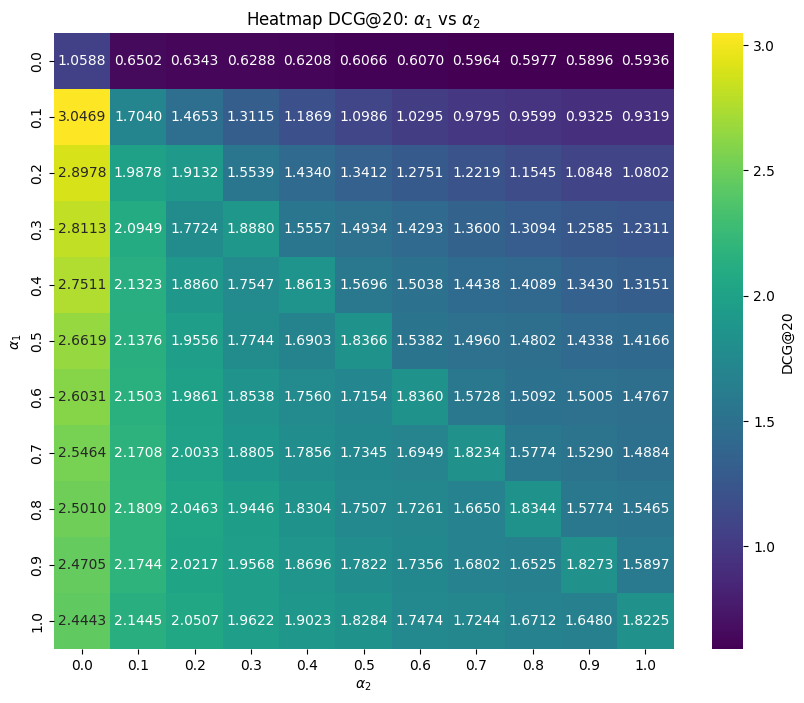

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create DataFrame from mean_dcg
df = pd.DataFrame(ti_mean_dcg_alpha, columns=["alpha_1", "alpha_2", "DCG"])

# Pivot the DataFrame to get alpha_1 as rows and alpha_2 as columns
heatmap_data = df.pivot(index="alpha_1", columns="alpha_2", values="DCG")

plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".4f", cmap="viridis", cbar_kws={'label': 'DCG@20'})
plt.xlabel(r'$\alpha_2$')
plt.ylabel(r'$\alpha_1$')
plt.title(r'Heatmap DCG@20: $\alpha_1$ vs $\alpha_2$')
plt.show()


#### NDCG $\alpha_1$ dan $\alpha_2$ heatmap

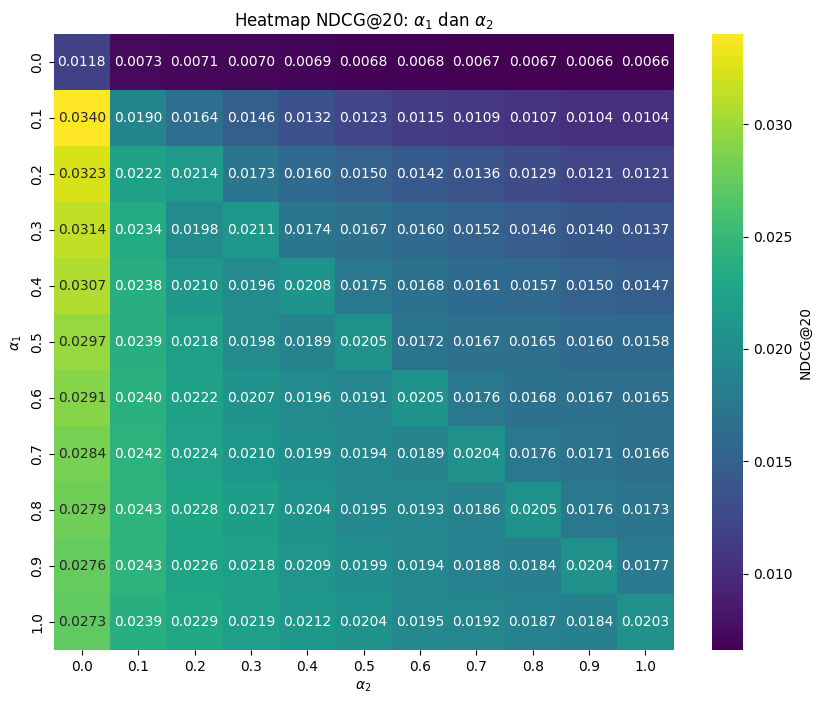

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create DataFrame from mean_ndcg
df = pd.DataFrame(ti_mean_ndcg_alpha, columns=["alpha_1", "alpha_2", "NDCG"])

# Pivot the DataFrame to get alpha_1 as rows and alpha_2 as columns
heatmap_data = df.pivot(index="alpha_1", columns="alpha_2", values="NDCG")

plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".4f", cmap="viridis", cbar_kws={'label': 'NDCG@20'})
plt.xlabel(r'$\alpha_2$')
plt.ylabel(r'$\alpha_1$')
plt.title(r'Heatmap NDCG@20: $\alpha_1$ dan $\alpha_2$')
plt.show()


### Skenario 2 : Mencari $k^{user}$ terbaik

In [20]:
from Skenario import EksperimenHCF
import DistanceBased.similarities as S

param = {
            "gamma" : [0.7],
            "k_user" : [5,10,15,18,20,25,30,40,50,100,200],
            "k_item" : [30],
            "alpha_1" : [0.1],
            "alpha_2" : [0],
        }

skenario_kedua = EksperimenHCF("data/ml-100k",object=S.TI,k_user=param["k_user"],k_item=param["k_item"],gamma=param["gamma"],alpha_1=param["alpha_1"],alpha_2=param["alpha_2"],path_file="Eksperimen/tversky_index/FBO_K_user.joblib",N=20,n=20)

In [ ]:
import numpy as np

n = 20
idcg = np.array([sum(np.array([sum(1/np.log2(np.arange(2,n+2))) for n in range(1,n+1)])) for i in range(1,n+1)])
k_user = [5,10,15,18,20,25,30,40,50,100,200]


ti_mean_dcg_k_user_fold = []
ti_mean_ndcg_k_user_fold = []
ti_mean_dcg_k_user = []
ti_mean_ndcg_k_user = []

# Mengakses parameter k_user
for k_user_index in k_user :

    skenario_kedua_k_user = skenario_kedua.result_skenario[0.7][k_user_index][30][0.1][0]
    ti_mean_dcg_k_user_per_fold = []
    ti_mean_ndcg_k_user_per_fold = []

    # Tahap 1 : menjumlahkan evaluasi setiap fold
    for i in range(len(skenario_kedua_k_user)) :
        # Tahap 2 : menjumlahkan evaluasi setiap pengguna
        # Tahap 3 : menghitung rata-rata setiap fold dengan menjumlahkan nilai evaluasi setiap pengguna dibagi dengan banyaknya pengguna
        ti_mean_dcg_k_user_per_fold += [sum(skenario_kedua_k_user[i])/len(skenario_kedua_k_user[i])]
        ti_mean_ndcg_k_user_per_fold += [sum(np.array(skenario_kedua_k_user[i])/idcg[n-1])/len(skenario_kedua_k_user[i])]

    # Tahap 4 : menghitung rata-rata evaluasi dari setiap fold
    ti_mean_dcg_per_fold_k_user = sum(ti_mean_dcg_k_user_per_fold)/len(skenario_kedua_k_user)
    ti_mean_ndcg_per_fold_k_user = sum(ti_mean_ndcg_k_user_per_fold)/len(skenario_kedua_k_user)
    
    ti_mean_dcg_k_user_per_fold += [ti_mean_dcg_per_fold_k_user]
    ti_mean_ndcg_k_user_per_fold += [ti_mean_ndcg_per_fold_k_user]

    ti_mean_dcg_k_user_fold += [ti_mean_dcg_k_user_per_fold]
    ti_mean_ndcg_k_user_fold += [ti_mean_ndcg_k_user_per_fold]
    ti_mean_dcg_k_user += [[k_user_index,30,ti_mean_dcg_per_fold_k_user]]
    ti_mean_ndcg_k_user += [[k_user_index,30,ti_mean_ndcg_per_fold_k_user]]

#### DCG@20 $k^{user}$ per fold 

In [22]:
import pandas as pd

k_user = [5,10,15,18,20,25,30,40,50,100,200]

pd.DataFrame(ti_mean_dcg_k_user_fold,index=[ f"A1_{str(0.1)}_A2_{str(0)}_N_{i}" for i in k_user],columns=[f"Fold-{i}" if i != 6 else "rata-rata" for i in range(1,7)])

,Fold-1,Fold-2,Fold-3,Fold-4,Fold-5,rata-rata
A1_0.1_A2_0_N_5,6.120393,3.402389,3.680902,3.101523,2.501807,3.761403
A1_0.1_A2_0_N_10,6.473667,3.049781,2.972159,2.903736,2.034128,3.486694
A1_0.1_A2_0_N_15,6.384138,2.965078,2.748774,2.703529,1.712103,3.302724
A1_0.1_A2_0_N_18,6.020117,2.972633,2.569505,2.563572,1.635921,3.152350
A1_0.1_A2_0_N_20,6.014967,2.714146,2.553658,2.470527,1.481215,3.046903
A1_0.1_A2_0_N_25,5.621949,2.429720,2.271514,2.273340,1.321668,2.783638
A1_0.1_A2_0_N_30,5.386251,2.338132,1.930890,1.993669,1.129013,2.555591
A1_0.1_A2_0_N_40,5.031219,2.298457,1.618864,1.802431,0.869656,2.324125
A1_0.1_A2_0_N_50,4.451435,1.969877,1.382566,1.690813,0.706774,2.040293
A1_0.1_A2_0_N_100,3.038008,1.143685,0.644841,1.015593,0.374698,1.243365


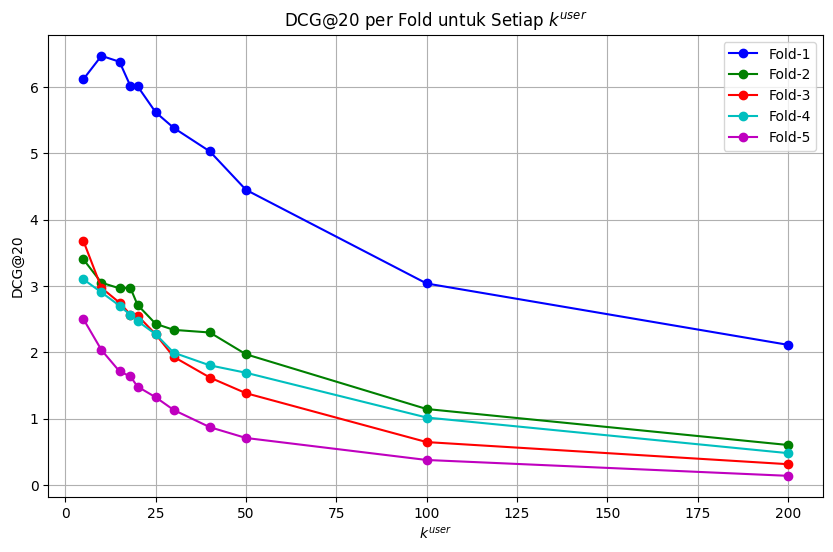

In [23]:
import matplotlib.pyplot as plt

# Definisikan markers dan colors
# markers = ['o', 's', '^', 'D', 'o']
colors = ['b', 'g', 'r', 'c', 'm']

plt.figure(figsize=(10, 6))

for fold_idx in range(5):
    dcg_per_fold = [ti_mean_dcg_k_user_fold[k][fold_idx] for k in range(len(k_user))]
    plt.plot(
        k_user,
        dcg_per_fold,
        marker="o",
        color=colors[fold_idx],
        label=f'Fold-{fold_idx+1}'
    )

plt.xlabel(r'$k^{user}$')
plt.ylabel('DCG@20')
plt.title(r'DCG@20 per Fold untuk Setiap $k^{user}$')
plt.legend()
plt.grid(True)
plt.show()

#### NDCG@20 $k^{user}$ per fold

In [24]:
import pandas as pd
k_user = [5,10,15,18,20,25,30,40,50,100,200]

pd.DataFrame(ti_mean_ndcg_k_user_fold,index=[ f"A1_{str(0.1)}_A2_{str(0)}_N_{i}" for i in k_user],columns=[f"fold-{i}" if i != 6 else "rata-rata" for i in range(1,7)])

,fold-1,fold-2,fold-3,fold-4,fold-5,rata-rata
A1_0.1_A2_0_N_5,0.068312,0.037975,0.041084,0.034617,0.027923,0.041982
A1_0.1_A2_0_N_10,0.072255,0.034040,0.033173,0.032409,0.022704,0.038916
A1_0.1_A2_0_N_15,0.071255,0.033094,0.030680,0.030175,0.019109,0.036863
A1_0.1_A2_0_N_18,0.067192,0.033178,0.028679,0.028613,0.018259,0.035184
A1_0.1_A2_0_N_20,0.067135,0.030293,0.028502,0.027574,0.016532,0.034007
A1_0.1_A2_0_N_25,0.062748,0.027119,0.025353,0.025373,0.014752,0.031069
A1_0.1_A2_0_N_30,0.060118,0.026097,0.021551,0.022252,0.012601,0.028524
A1_0.1_A2_0_N_40,0.056155,0.025654,0.018069,0.020117,0.009706,0.025940
A1_0.1_A2_0_N_50,0.049684,0.021986,0.015431,0.018872,0.007889,0.022772
A1_0.1_A2_0_N_100,0.033908,0.012765,0.007197,0.011335,0.004182,0.013878


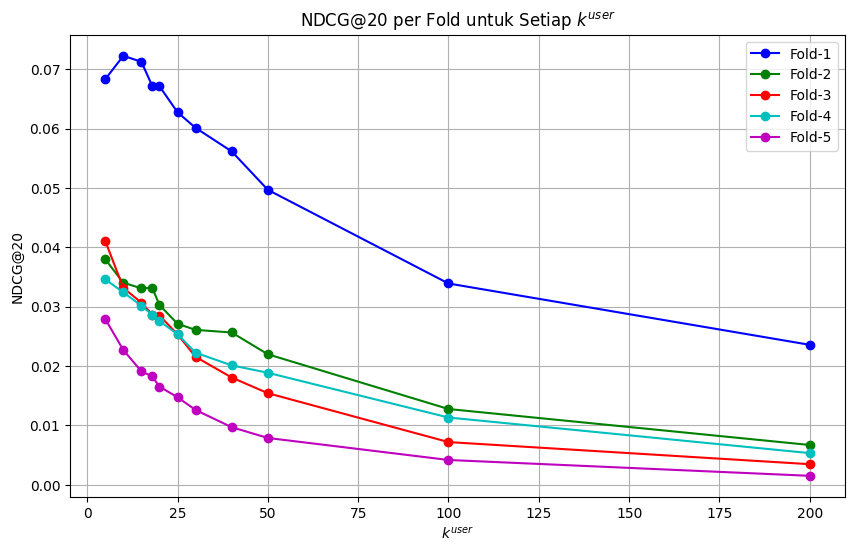

In [25]:
import matplotlib.pyplot as plt

# Definisikan markers dan colors
colors = ['b', 'g', 'r', 'c', 'm']

plt.figure(figsize=(10, 6))

for fold_idx in range(5):
    ndcg_per_fold = [ti_mean_ndcg_k_user_fold[k][fold_idx] for k in range(len(k_user))]
    plt.plot(
        k_user,
        ndcg_per_fold,
        marker="o",
        color=colors[fold_idx],
        label=f'Fold-{fold_idx+1}'
    )

plt.xlabel(r'$k^{user}$')
plt.ylabel('NDCG@20')
plt.title(r'NDCG@20 per Fold untuk Setiap $k^{user}$')
plt.legend()
plt.grid(True)
plt.show()

#### DCG $k^{user}$ Plot

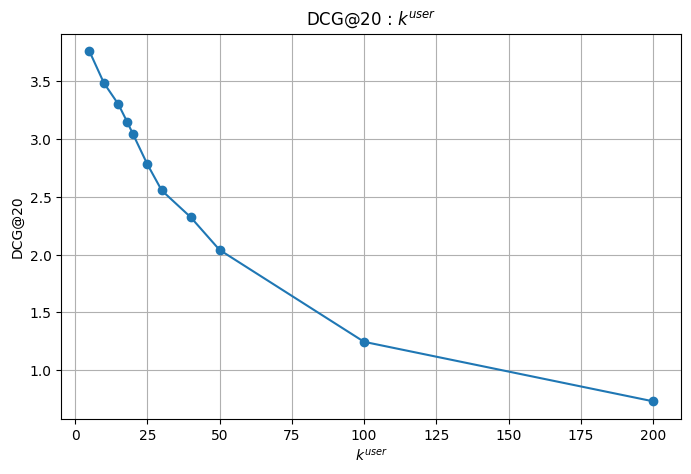

In [26]:
import pandas as pd

df = pd.DataFrame(ti_mean_dcg_k_user, index=[i for i in range(1, len(ti_mean_dcg_k_user) + 1)], columns=["k_user", "k_item", "DCG"])

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot([5,10,15,18,20,25,30,40,50,100,200], df["DCG"], marker='o')
plt.xlabel(r"$k^{user}$")
plt.ylabel("DCG@20")
plt.title(r"DCG@20 : $k^{user}$")
plt.grid(True)
plt.show()

#### NDCG $k^{user}$ Plot

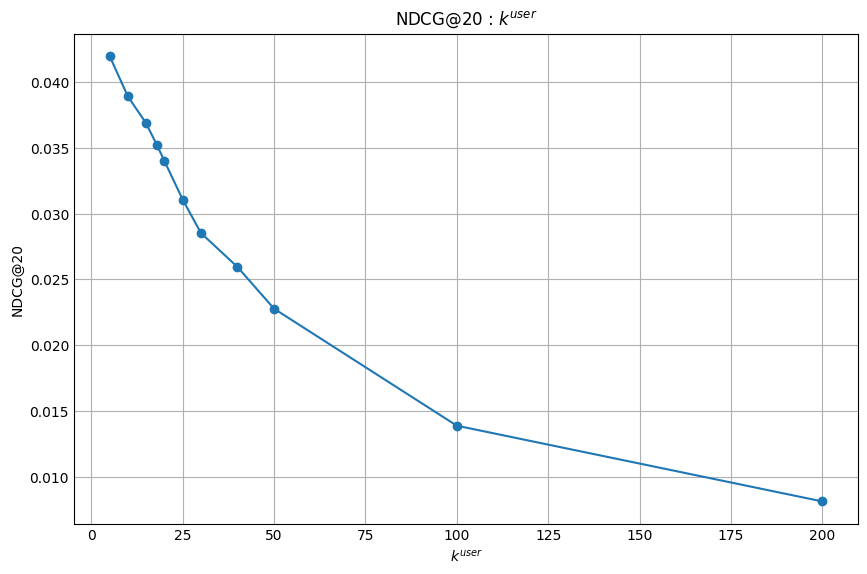

In [27]:
import pandas as pd

df = pd.DataFrame(ti_mean_ndcg_k_user, index=[i for i in range(1, len(ti_mean_ndcg_k_user) + 1)], columns=["k_user", "k_item", "NDCG"])

import matplotlib.pyplot as plt

plt.style.use("_mpl-gallery")

plt.figure(figsize=(8, 5))
plt.plot([5,10,15,18,20,25,30,40,50,100,200], df["NDCG"], marker='o')
plt.xlabel(r"$k^{user}$")
plt.ylabel("NDCG@20")
plt.title(r"NDCG@20 : $k^{user}$")
plt.grid(True)
plt.show()

### Skenario 3 : Mencari $k^{item}$ terbaik

In [28]:
from Skenario import EksperimenHCF
import DistanceBased.similarities as S

param = {
            "gamma" : [0.7],
            "k_user" : [5],
            "k_item" : [5,10,15,18,20,25,30,40,50,100,200],
            "alpha_1" : [0.1],
            "alpha_2" : [0],
        }

skenario_kedua = EksperimenHCF("data/ml-100k",object=S.TI,k_user=param["k_user"],k_item=param["k_item"],gamma=param["gamma"],alpha_1=param["alpha_1"],alpha_2=param["alpha_2"],path_file="Eksperimen/tversky_index/FBO_K_item.joblib",N=20,n=20)

In [36]:
import numpy as np

n = 20
idcg = np.array([sum(np.array([sum(1/np.log2(np.arange(2,n+2))) for n in range(1,n+1)])) for i in range(1,n+1)])
k_item = [5,10,15,18,20,25,30,40,50,100,200]


ti_mean_dcg_k_item_fold = []
ti_mean_ndcg_k_item_fold = []
ti_mean_dcg_k_item = []
ti_mean_ndcg_k_item = []

for k_item_index in k_item :

    skenario_kedua_k_item = skenario_kedua.result_skenario[0.7][5][k_item_index][0.1][0]
    ti_mean_dcg_per_fold = []
    ti_mean_ndcg_per_fold = []

    # Tahap 1 : menjumlahkan evaluasi setiap fold
    for i in range(len(skenario_kedua_k_item)) :
        # Tahap 2 : menjumlahkan setiap pengguna
        # Tahap 3 : menghitung rata-rata setiap fold dengan menjumlahkan nilai evaluasi lalu dibagi dengan jumlah fold
        ti_mean_dcg_per_fold += [sum(skenario_kedua_k_item[i])/len(skenario_kedua_k_item[i])]
        ti_mean_ndcg_per_fold += [sum(np.array(skenario_kedua_k_item[i])/idcg[n-1])/len(skenario_kedua_k_item[i])]
    
    # Tahap 4 : menghitung rata-rata evaluasi dari setiap fold
    ti_mean_dcg_per_fold_k_item = sum(ti_mean_dcg_per_fold)/len(skenario_kedua_k_item)
    ti_mean_ndcg_per_fold_k_item = sum(ti_mean_ndcg_per_fold)/len(skenario_kedua_k_item)
    
    ti_mean_dcg_per_fold += [ti_mean_dcg_per_fold_k_item]
    ti_mean_ndcg_per_fold += [ti_mean_ndcg_per_fold_k_item]

    ti_mean_dcg_k_item_fold += [ti_mean_dcg_per_fold]
    ti_mean_ndcg_k_item_fold += [ti_mean_ndcg_per_fold]
    ti_mean_dcg_k_item += [[k_item_index,30,ti_mean_dcg_per_fold_k_item]]
    ti_mean_ndcg_k_item += [[k_item_index,30,ti_mean_ndcg_per_fold_k_item]]

#### DCG@20 $k^{item}$

In [37]:
import pandas as pd

k_item = [5,10,15,18,20,25,30,40,50,100,200]

pd.DataFrame(ti_mean_dcg_k_item_fold,index=[ f"k_item_{str(i)}" for i in k_item],columns=[f"fold-{i}" if i != 6 else "rata-rata" for i in range(1,7)])

,fold-1,fold-2,fold-3,fold-4,fold-5,rata-rata
k_item_5,5.762116,3.349590,3.597269,3.027099,2.624333,3.672082
k_item_10,5.909406,3.427288,3.645916,3.078745,2.625614,3.737394
k_item_15,5.886557,3.400323,3.767459,3.057702,2.488213,3.720051
k_item_18,6.079989,3.297579,3.692861,3.120375,2.554758,3.749113
k_item_20,6.295430,3.338731,3.627808,3.058509,2.527179,3.769531
k_item_25,6.026037,3.379786,3.652568,3.082798,2.516514,3.731541
k_item_30,6.120393,3.402389,3.680902,3.101523,2.501807,3.761403
k_item_40,6.233013,3.275216,3.602992,3.091093,2.466407,3.733744
k_item_50,6.148571,3.289699,3.682423,3.059335,2.438766,3.723759
k_item_100,6.258673,3.372383,3.633104,3.062922,2.492764,3.763969


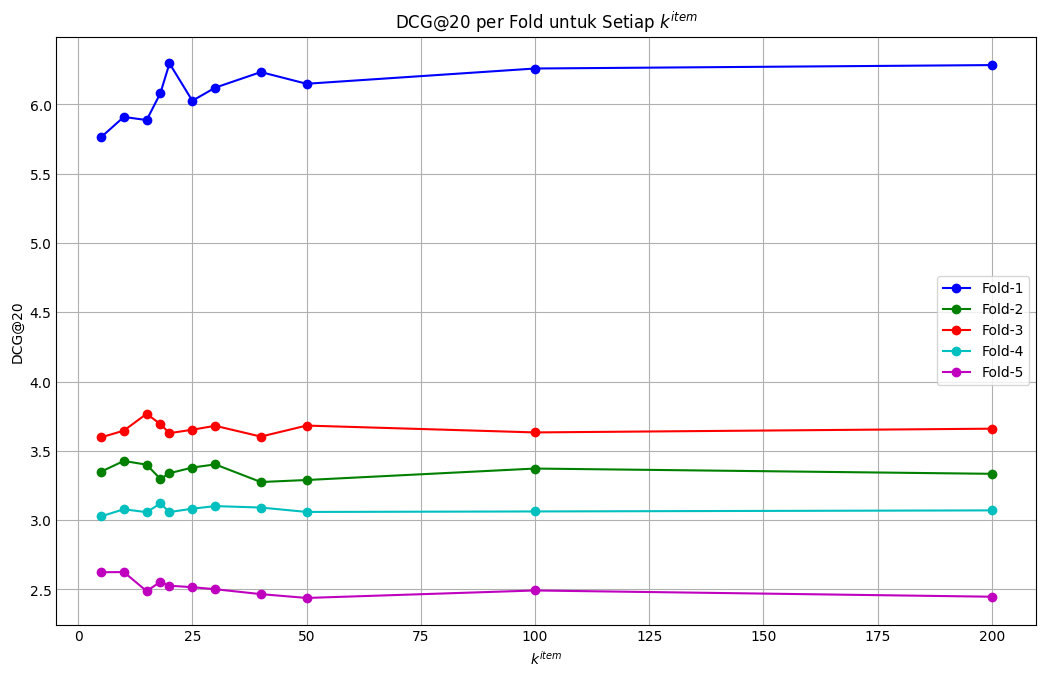

In [38]:
import matplotlib.pyplot as plt

# Definisikan markers dan colors
# markers = ['o', 's', '^', 'D', 'o']
colors = ['b', 'g', 'r', 'c', 'm']

plt.figure(figsize=(10, 6))

for fold_idx in range(5):
    dcg_per_fold = [ti_mean_dcg_k_item_fold[k][fold_idx] for k in range(len(k_item))]
    plt.plot(
        k_item,
        dcg_per_fold,
        marker="o",
        color=colors[fold_idx],
        label=f'Fold-{fold_idx+1}'
    )

plt.xlabel(r'$k^{item}$')
plt.ylabel('DCG@20')
plt.title(r'DCG@20 per Fold untuk Setiap $k^{item}$')
plt.legend()
plt.grid(True)
plt.show()

#### NDCG@20 $k^{item}$ 

In [39]:
import pandas as pd

k_item = [5,10,15,18,20,25,30,40,50,100,200]

pd.DataFrame(ti_mean_ndcg_k_item_fold,index=[ f"k_item_{str(i)}" for i in k_item],columns=[f"fold-{i}" if i != 6 else "rata-rata" for i in range(1,7)])

,fold-1,fold-2,fold-3,fold-4,fold-5,rata-rata
k_item_5,0.064313,0.037386,0.040150,0.033786,0.029291,0.040985
k_item_10,0.065957,0.038253,0.040693,0.034363,0.029305,0.041714
k_item_15,0.065702,0.037952,0.042050,0.034128,0.027772,0.041521
k_item_18,0.067861,0.036805,0.041217,0.034827,0.028514,0.041845
k_item_20,0.070265,0.037265,0.040491,0.034137,0.028207,0.042073
k_item_25,0.067258,0.037723,0.040767,0.034408,0.028088,0.041649
k_item_30,0.068312,0.037975,0.041084,0.034617,0.027923,0.041982
k_item_40,0.069569,0.036556,0.040214,0.034501,0.027528,0.041673
k_item_50,0.068626,0.036717,0.041101,0.034146,0.027220,0.041562
k_item_100,0.069855,0.037640,0.040550,0.034186,0.027822,0.042011


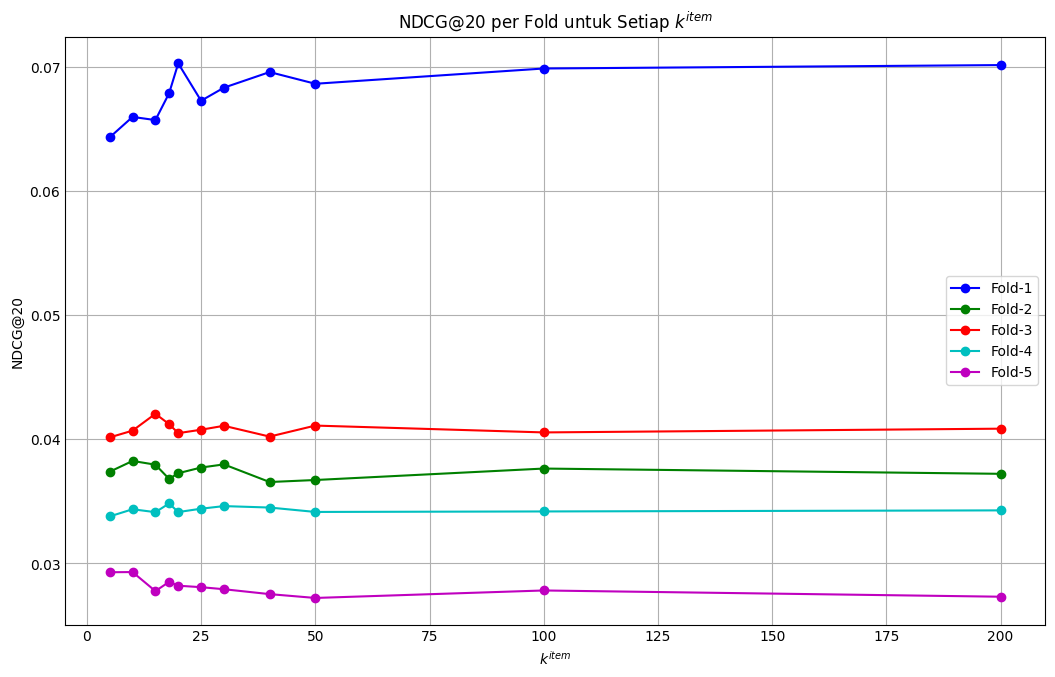

In [40]:
import matplotlib.pyplot as plt

# Definisikan markers dan colors
# markers = ['o', 's', '^', 'D', 'o']
colors = ['b', 'g', 'r', 'c', 'm']

plt.figure(figsize=(10, 6))

for fold_idx in range(5):
    ndcg_per_fold = [ti_mean_ndcg_k_item_fold[k][fold_idx] for k in range(len(k_item))]
    plt.plot(
        k_item,
        ndcg_per_fold,
        marker="o",
        color=colors[fold_idx],
        label=f'Fold-{fold_idx+1}'
    )

plt.xlabel(r'$k^{item}$')
plt.ylabel('NDCG@20')
plt.title(r'NDCG@20 per Fold untuk Setiap $k^{item}$')
plt.legend()
plt.grid(True)
plt.show()

#### DCG@20 $k^{item}$ plot 

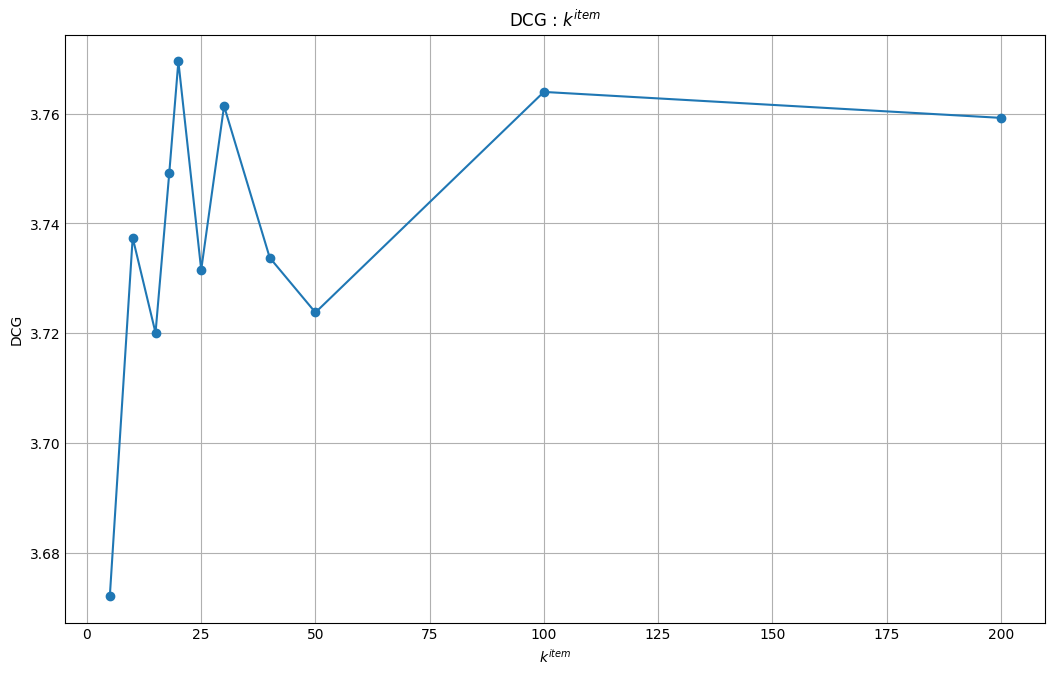

In [34]:
import pandas as pd

df = pd.DataFrame(ti_mean_dcg_k_item, index=[i for i in range(1, len(ti_mean_dcg_k_item) + 1)], columns=["k_user", "k_item", "DCG"])

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot([5,10,15,18,20,25,30,40,50,100,200], df["DCG"], marker='o')
plt.xlabel(r"$k^{item}$")
plt.ylabel("DCG")
plt.title(r"DCG : $k^{item}$")
plt.grid(True)
plt.show()

#### NDCG@20 $k^{item}$ plot

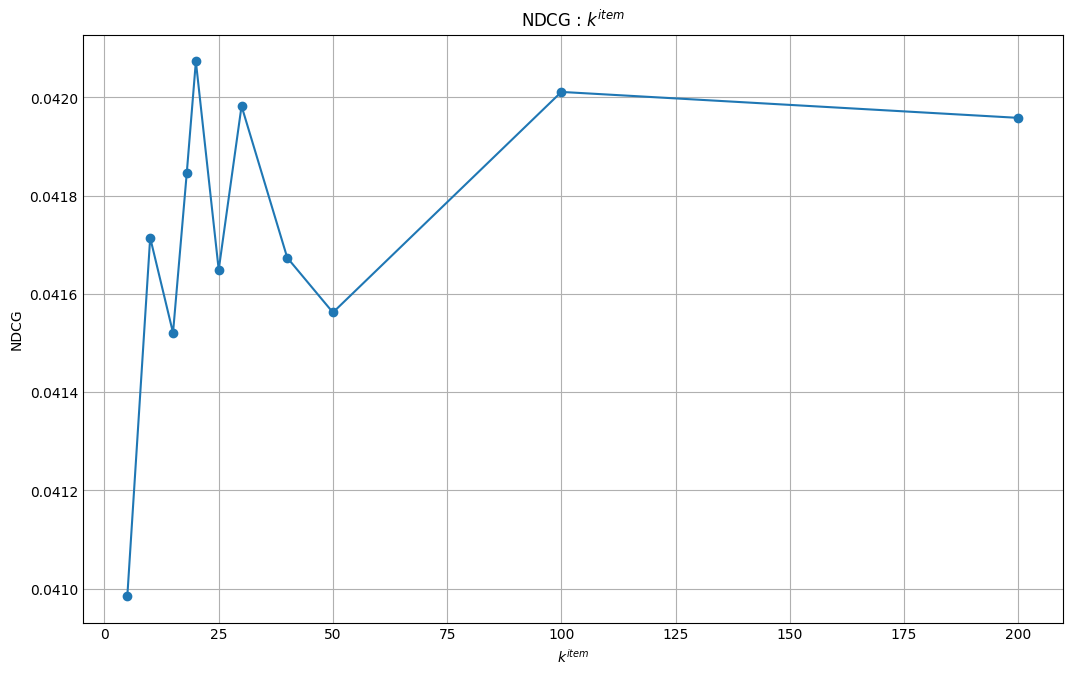

In [35]:
import pandas as pd

df = pd.DataFrame(ti_mean_ndcg_k_item, index=[i for i in range(1, len(ti_mean_ndcg_k_item) + 1)], columns=["k_user", "k_item", "NDCG"])

import matplotlib.pyplot as plt

plt.style.use("_mpl-gallery")

plt.figure(figsize=(10, 6))
plt.plot([5,10,15,18,20,25,30,40,50,100,200], df["NDCG"], marker='o')
plt.xlabel(r"$k^{item}$")
plt.ylabel("NDCG")
plt.title(r"NDCG : $k^{item}$")
plt.grid(True)
plt.show()

### Skenario 4 : Mencari $\Gamma$ terbaik

In [55]:
from Skenario import EksperimenHCF
import DistanceBased.similarities as S

param = {
            "gamma" : [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1], "k_user" : [5],"k_item" : [20],"alpha_1" : [0.1],"alpha_2" : [0]}

skenario_keempat = EksperimenHCF("data/ml-100k",object=S.TI,k_user=param["k_user"],k_item=param["k_item"],gamma=param["gamma"],alpha_1=param["alpha_1"],alpha_2=param["alpha_2"],path_file="Eksperimen/tversky_index/FBO_Gamma.joblib",N=20,n=20)

In [56]:
import numpy as np

n = 20
idcg = np.array([sum(np.array([sum(1/np.log2(np.arange(2,n+2))) for n in range(1,n+1)])) for i in range(1,n+1)])
gamma = [round(i*0.1,2) for i in range(11)]


ti_mean_dcg_gamma_fold = []
ti_mean_ndcg_gamma_fold = []
ti_mean_dcg_gamma = []
ti_mean_ndcg_gamma = []

# Mengakses parameter gamma
for gamma_index in gamma :
    skenario_kedua_gamma = skenario_keempat.result_skenario[gamma_index][5][20][0.1][0]
    ti_mean_dcg_per_fold = []
    ti_mean_ndcg_per_fold = []

    # Tahap 1 : menjumlahkan evaluasi setiap fold
    for i in range(len(skenario_kedua_gamma)) :
        # Tahap 2 : menjumlahkan evaluasi setiap pengguna
        # Tahap 3 : menghitung rata-rata setiap fold dengan menjumlahkan nilai evaluasi lalu dibagi dengan jumlah fold
        ti_mean_dcg_per_fold += [sum(skenario_kedua_gamma[i])/len(skenario_kedua_gamma[i])]
        ti_mean_ndcg_per_fold += [sum(np.array(skenario_kedua_gamma[i])/idcg[n-1])/len(skenario_kedua_gamma[i])]
    
    # Tahap 4 : menghitung rata-rata evaluasi dari setiap fold
    ti_mean_dcg_per_fold_gamma = sum(ti_mean_dcg_per_fold)/len(skenario_kedua_gamma)
    ti_mean_ndcg_per_fold_gamma = sum(ti_mean_ndcg_per_fold)/len(skenario_kedua_gamma)

    ti_mean_dcg_per_fold += [ti_mean_dcg_per_fold_gamma]
    ti_mean_ndcg_per_fold += [ti_mean_ndcg_per_fold_gamma]

    ti_mean_dcg_gamma_fold += [ti_mean_dcg_per_fold]
    ti_mean_ndcg_gamma_fold += [ti_mean_ndcg_per_fold]
    ti_mean_dcg_gamma += [[gamma_index,30,ti_mean_dcg_per_fold_gamma]]
    ti_mean_ndcg_gamma += [[gamma_index,30,ti_mean_ndcg_per_fold_gamma]]

#### DCG@20 $\Gamma$ per fold

In [57]:
import pandas as pd

gamma = [round(i*0.1,2) for i in range(11)]

pd.DataFrame(ti_mean_dcg_gamma_fold,index=[ f"A1_{str(0.1)}_A2_{str(0)}_K_USER_{str(5)}_K_ITEM_{str(18)}_GAMMA_{str(i)}" for i in gamma],columns=[f"fold-{i}" if i != 6 else "rata-rata" for i in range(1,7)])

,fold-1,fold-2,fold-3,fold-4,fold-5,rata-rata
A1_0.1_A2_0_K_USER_5_K_ITEM_18_GAMMA_0.0,3.717668,1.569730,1.217836,1.082105,1.027868,1.723041
A1_0.1_A2_0_K_USER_5_K_ITEM_18_GAMMA_0.1,4.251154,1.674240,1.376524,1.322789,1.092532,1.943448
A1_0.1_A2_0_K_USER_5_K_ITEM_18_GAMMA_0.2,4.850284,1.867032,1.647197,1.690354,1.334129,2.277799
A1_0.1_A2_0_K_USER_5_K_ITEM_18_GAMMA_0.3,5.455941,2.260811,2.028473,2.073287,1.410741,2.645851
A1_0.1_A2_0_K_USER_5_K_ITEM_18_GAMMA_0.4,5.822137,2.458313,2.500823,2.592026,1.487959,2.972252
A1_0.1_A2_0_K_USER_5_K_ITEM_18_GAMMA_0.5,6.419568,2.634075,2.884763,2.774289,1.807946,3.304128
A1_0.1_A2_0_K_USER_5_K_ITEM_18_GAMMA_0.6,6.400427,2.984688,3.297846,2.968828,2.180185,3.566395
A1_0.1_A2_0_K_USER_5_K_ITEM_18_GAMMA_0.7,6.295430,3.338731,3.627808,3.058509,2.527179,3.769531
A1_0.1_A2_0_K_USER_5_K_ITEM_18_GAMMA_0.8,6.029859,3.602577,4.000514,3.227725,2.820848,3.936305
A1_0.1_A2_0_K_USER_5_K_ITEM_18_GAMMA_0.9,6.118416,3.628898,4.196488,3.347805,3.214031,4.101128


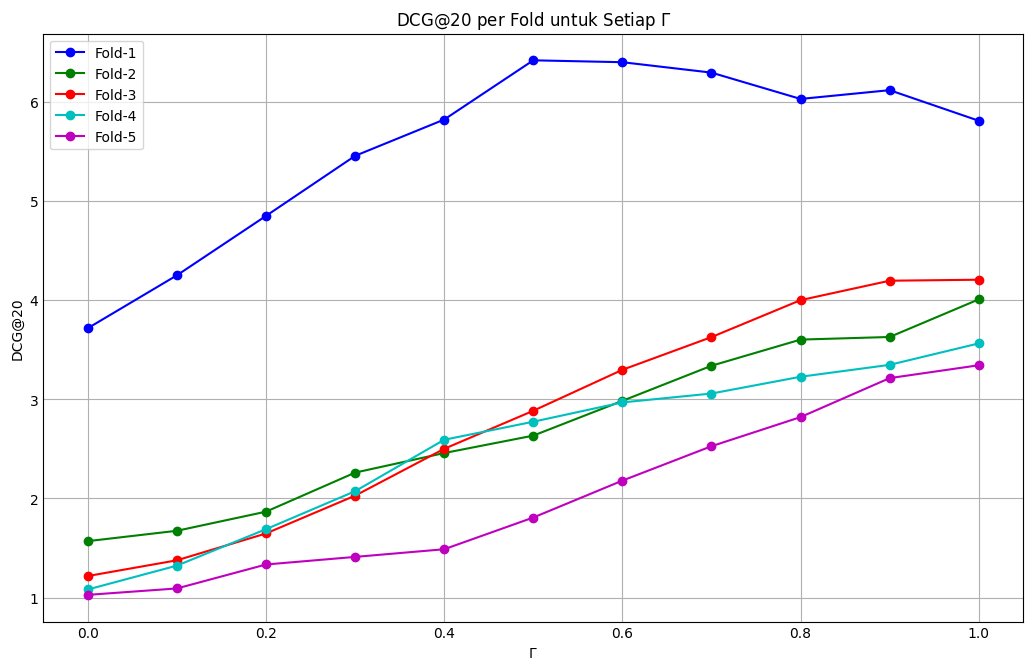

In [58]:
import matplotlib.pyplot as plt

# Definisikan markers dan colors
# markers = ['o', 's', '^', 'D', 'o']
colors = ['b', 'g', 'r', 'c', 'm']

plt.figure(figsize=(10, 6))

for fold_idx in range(5):
    dcg_per_fold = [ti_mean_dcg_gamma_fold[k][fold_idx] for k in range(len(gamma))]
    plt.plot(
        gamma,
        dcg_per_fold,
        marker="o",
        color=colors[fold_idx],
        label=f'Fold-{fold_idx+1}'
    )

plt.xlabel(r'$\Gamma$')
plt.ylabel('DCG@20')
plt.title(r'DCG@20 per Fold untuk Setiap $\Gamma$')
plt.legend()
plt.grid(True)
plt.show()

#### NDCG@20 $\Gamma$

In [59]:
import pandas as pd

gamma = [round(i*0.1,2) for i in range(11)]

pd.DataFrame(ti_mean_ndcg_gamma_fold,index=[ f"GAMMA_{str(i)}" for i in gamma],columns=[f"fold-{i}" if i != 6 else "rata-rata" for i in range(1,7)])

,fold-1,fold-2,fold-3,fold-4,fold-5,rata-rata
GAMMA_0.0,0.041494,0.017520,0.013593,0.012078,0.011472,0.019231
GAMMA_0.1,0.047448,0.018687,0.015364,0.014764,0.012194,0.021691
GAMMA_0.2,0.054135,0.020838,0.018385,0.018867,0.014891,0.025423
GAMMA_0.3,0.060895,0.025234,0.022640,0.023141,0.015746,0.029531
GAMMA_0.4,0.064983,0.027438,0.027912,0.028930,0.016608,0.033174
GAMMA_0.5,0.071651,0.029400,0.032198,0.030965,0.020179,0.036878
GAMMA_0.6,0.071437,0.033313,0.036808,0.033136,0.024334,0.039806
GAMMA_0.7,0.070265,0.037265,0.040491,0.034137,0.028207,0.042073
GAMMA_0.8,0.067301,0.040209,0.044651,0.036026,0.031484,0.043934
GAMMA_0.9,0.068289,0.040503,0.046838,0.037366,0.035873,0.045774


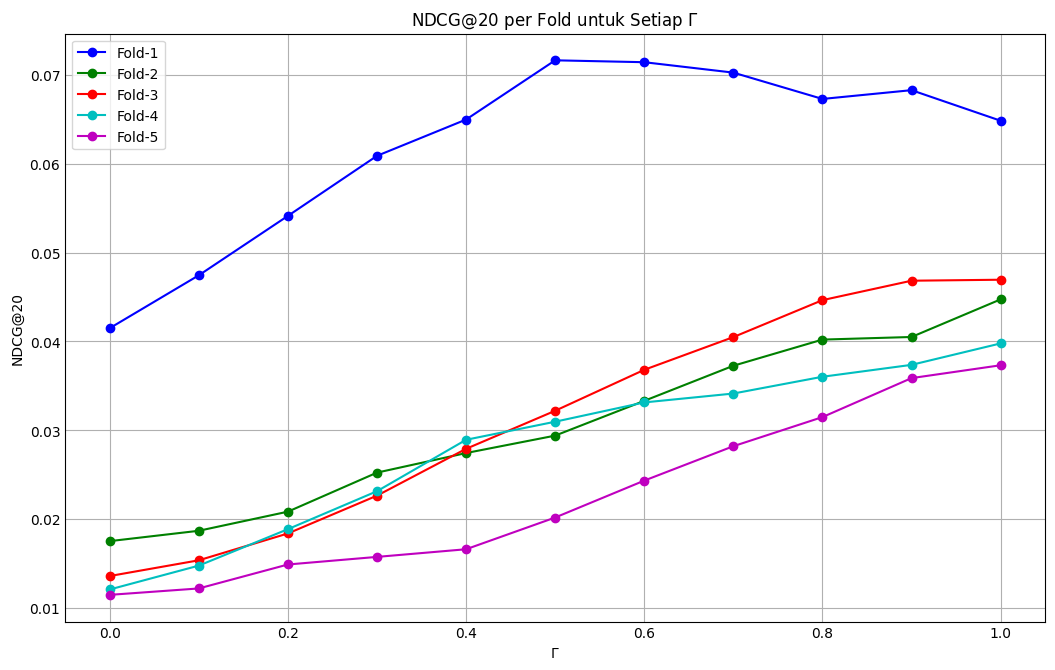

In [60]:
import matplotlib.pyplot as plt

# Definisikan markers dan colors
# markers = ['o', 's', '^', 'D', 'o']
colors = ['b', 'g', 'r', 'c', 'm']

plt.figure(figsize=(10, 6))

for fold_idx in range(5):
    ndcg_per_fold = [ti_mean_ndcg_gamma_fold[k][fold_idx] for k in range(len(gamma))]
    plt.plot(
        gamma,
        ndcg_per_fold,
        marker="o",
        color=colors[fold_idx],
        label=f'Fold-{fold_idx+1}'
    )

plt.xlabel(r'$\Gamma$')
plt.ylabel('NDCG@20')
plt.title(r'NDCG@20 per Fold untuk Setiap $\Gamma$')
plt.legend()
plt.grid(True)
plt.show()

#### DCG@20 $\Gamma$ plot

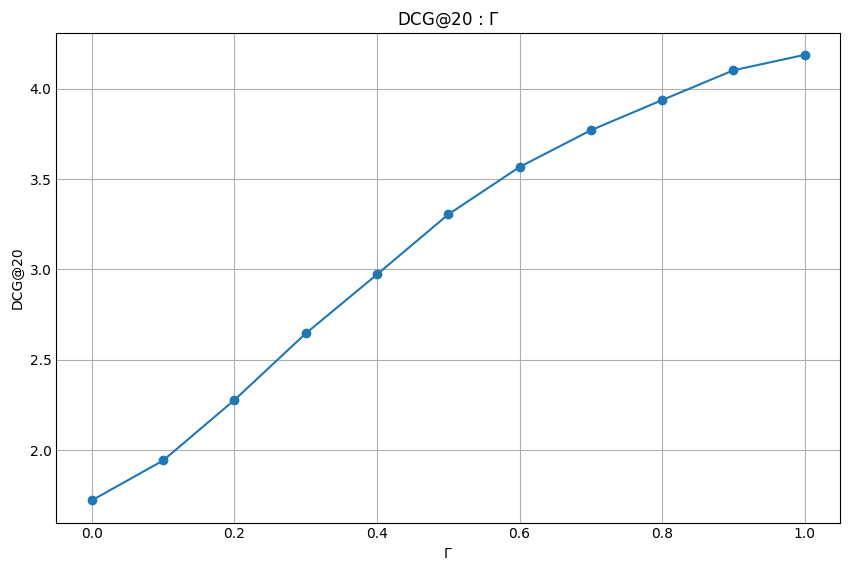

In [61]:
import pandas as pd

df = pd.DataFrame(ti_mean_dcg_gamma, index=[i for i in range(1, len(ti_mean_dcg_gamma) + 1)], columns=["k_user", "k_item", "DCG"])

import matplotlib.pyplot as plt

plt.style.use("_mpl-gallery")

plt.figure(figsize=(8, 5))
plt.plot([round(i*0.1,2) for i in range(11)], df["DCG"], marker='o')
plt.xlabel(r"$\Gamma$")
plt.ylabel("DCG@20")
plt.title(r"DCG@20 : $\Gamma$")
plt.grid(True)
plt.show()

#### NDCG@20 $\Gamma$ fold

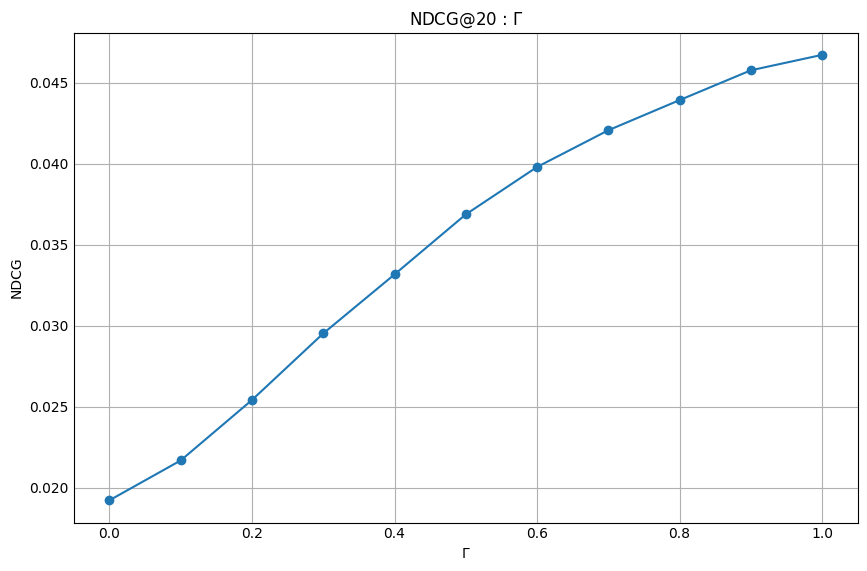

In [62]:
import pandas as pd

df = pd.DataFrame(ti_mean_ndcg_gamma, index=[i for i in range(1, len(ti_mean_ndcg_gamma) + 1)], columns=["k_user", "k_item", "NDCG"])

import matplotlib.pyplot as plt

plt.style.use("_mpl-gallery")

plt.figure(figsize=(8, 5))
plt.plot([round(i*0.1,2) for i in range(11)], df["NDCG"], marker='o')
plt.xlabel("$\Gamma$")
plt.ylabel("NDCG")
plt.title("NDCG@20 : $\Gamma$")
plt.grid(True)
plt.show()

### NDCG

In [1]:
from hybrid import HCF 
import DistanceBased.similarities as S

hybrid_ti = HCF("data/ml-100k",S.TI,k_user=5,k_item=20,alpha_1=0.1,alpha_2=0,gamma=1,N=20,n=None,path_file="Eksperimen/tversky_index/PBO_NDCG.joblib")

In [2]:
import numpy as np

skenario_dcg = hybrid_ti.result_evaluation

# Mencari NDCG
ndcg_ti_per_fold = []
for skenario_dcg_fold in skenario_dcg :
    ndcg_ti_per_user = []
    for skenario_dcg_user in skenario_dcg_fold :
        ndcg_ti_per_user += [np.array(skenario_dcg_user)/hybrid_ti.IDCG()]
    ndcg_ti_per_fold += [ndcg_ti_per_user]

# Mencari Rata-rata NDCG per fold
mean_ndcg_ti_per_fold = [ [ sum([row[col] for row in ndcg_ti_per_fold[i]])/len(ndcg_ti_per_fold[i]) for col in range(len(ndcg_ti_per_fold[i][0]))] for i in range(len(ndcg_ti_per_fold))]

# Mencari rata-rata NDCG
mean_ndcg_ti = [ sum([row[col] for row in mean_ndcg_ti_per_fold])/len(mean_ndcg_ti_per_fold) for col in range(len(mean_ndcg_ti_per_fold[0])) ]

In [3]:
import pandas as pd

pd.DataFrame(mean_ndcg_ti).T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,0.029611,0.026758,0.028978,0.032236,0.032417,0.03481,0.037006,0.039532,0.042464,0.043681,0.045254,0.046317,0.046759,0.04707,0.047393,0.047501,0.04776,0.047574,0.047353,0.046727


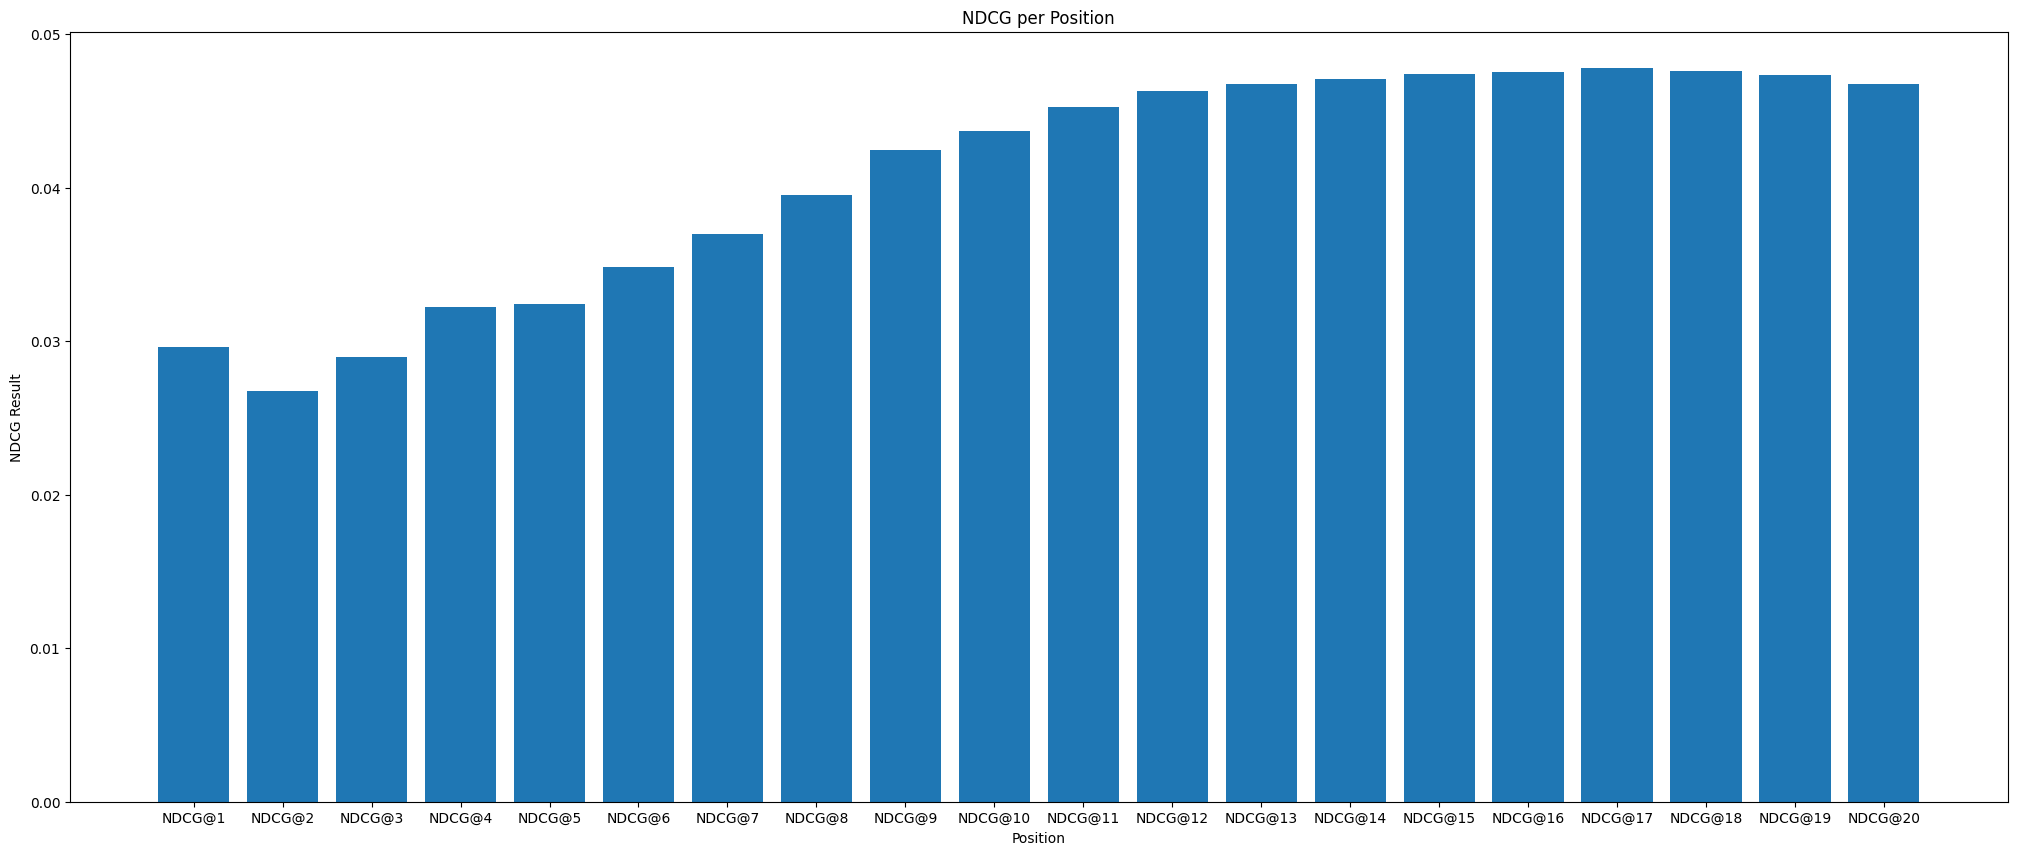

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(25, 10))
plt.bar([f"NDCG@{i}" for i in range(1,len(mean_ndcg_ti) + 1)], mean_ndcg_ti)
plt.xlabel('Position')
plt.ylabel('NDCG Result')
plt.title('NDCG per Position')
plt.show()

## Dice Coefficient

### Skenario 1 : Mencari $k^{user}$ terbaik

In [63]:
from Skenario import EksperimenHCF
import DistanceBased.similarities as S

param = {
            "gamma" : [0.7],
            "k_user" : [5,10,15,18,20,25,30,40,50,100,200],
            "k_item" : [30],
        }

skenario_pertama_dc = EksperimenHCF("data/ml-100k",object=S.DC,k_user=param["k_user"],k_item=param["k_item"],gamma=param["gamma"],path_file="Eksperimen/dice_coefficient/FBO_K_user.joblib",N=20,n=20)

In [64]:
import numpy as np

n = 20
idcg = np.array([sum(np.array([sum(1/np.log2(np.arange(2,n+2))) for n in range(1,n+1)])) for i in range(1,n+1)])
k_user = [5,10,15,18,20,25,30,40,50,100,200]


dc_mean_dcg_k_user_fold = []
dc_mean_ndcg_k_user_fold = []
dc_mean_dcg_k_user = []
dc_mean_ndcg_k_user = []

# Mengakses parameter k_user
for k_user_index in k_user :
    skenario_pertama_dc_candidate = skenario_pertama_dc.result_skenario[0.7][k_user_index][30]
    dc_mean_dcg_k_user_per_fold = []
    dc_mean_ndcg_k_user_per_fold = []

    # Tahap 1 : menjumlahkan evaluasi setiap fold
    for i in range(len(skenario_pertama_dc_candidate)) :
        # Tahap 2 : menjumlahkan evaluasi setiap pengguna
        # Tahap 3 : menghitung rata-rata setiap fold dengan menjumlahkan nilai evaluasi setiap pengguna lalu dibagi dengan jumlah pengguna
        dc_mean_dcg_k_user_per_fold += [sum(skenario_pertama_dc_candidate[i])/len(skenario_pertama_dc_candidate[i])]
        dc_mean_ndcg_k_user_per_fold += [sum(np.array(skenario_pertama_dc_candidate[i])/idcg[n-1])/len(skenario_pertama_dc_candidate[i])]
    
    # Tahap 4 : menghitung rata-rata evaluasi dari setiap fold
    dc_mean_dcg_per_fold_k_user = sum(dc_mean_dcg_k_user_per_fold)/len(skenario_pertama_dc_candidate)
    dc_mean_ndcg_per_fold_k_user = sum(dc_mean_ndcg_k_user_per_fold)/len(skenario_pertama_dc_candidate)

    dc_mean_dcg_k_user_per_fold += [dc_mean_dcg_per_fold_k_user]
    dc_mean_ndcg_k_user_per_fold += [dc_mean_ndcg_per_fold_k_user]

    dc_mean_dcg_k_user_fold += [dc_mean_dcg_k_user_per_fold]
    dc_mean_ndcg_k_user_fold += [dc_mean_ndcg_k_user_per_fold]
    dc_mean_dcg_k_user += [[k_user_index,30,dc_mean_dcg_per_fold_k_user]]
    dc_mean_ndcg_k_user += [[k_user_index,30,dc_mean_ndcg_per_fold_k_user]]

#### DCG@20 $k^{user}$ per fold

In [65]:
import pandas as pd

k_user = [5,10,15,18,20,25,30,40,50,100,200]

pd.DataFrame(dc_mean_dcg_k_user_fold,index=[ f"N_{i}" for i in k_user],columns=[f"Fold-{i}" if i != 6 else "rata-rata" for i in range(1,7)])

,Fold-1,Fold-2,Fold-3,Fold-4,Fold-5,rata-rata
N_5,4.185649,2.357345,2.105758,2.199348,1.498704,2.469361
N_10,3.764783,2.143832,1.731462,1.918904,1.277289,2.167254
N_15,3.500026,1.814381,1.539873,1.727823,1.155776,1.947576
N_18,3.457075,1.792804,1.580102,1.595261,1.080300,1.901108
N_20,3.327830,1.799005,1.470751,1.559589,1.018550,1.835145
N_25,3.195953,1.655014,1.347579,1.522998,0.856509,1.715611
N_30,3.120423,1.603959,1.374723,1.493543,0.839671,1.686464
N_40,3.117966,1.500512,1.264162,1.367072,0.720122,1.593967
N_50,2.888417,1.293458,1.241850,1.238805,0.693067,1.471119
N_100,2.448320,1.144051,1.051847,0.960386,0.519599,1.224840


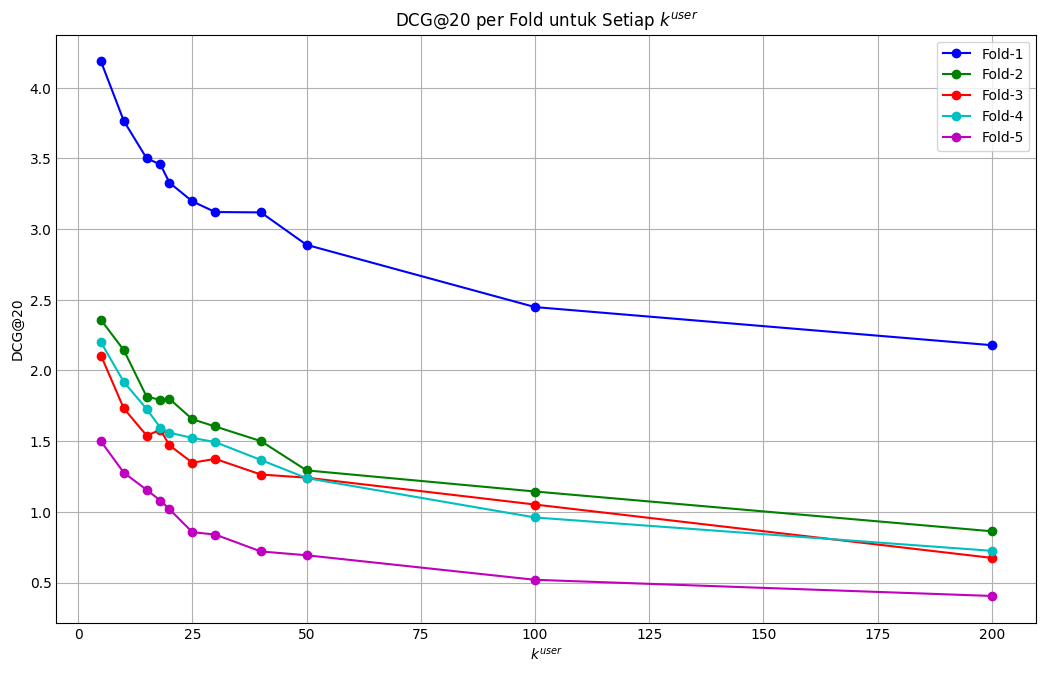

In [66]:
import matplotlib.pyplot as plt

# Definisikan markers dan colors
# markers = ['o', 's', '^', 'D', 'o']
colors = ['b', 'g', 'r', 'c', 'm']

plt.figure(figsize=(10, 6))

for fold_idx in range(5):
    dcg_per_fold = [dc_mean_dcg_k_user_fold[k][fold_idx] for k in range(len(k_user))]
    plt.plot(
        k_user,
        dcg_per_fold,
        marker="o",
        color=colors[fold_idx],
        label=f'Fold-{fold_idx+1}'
    )

plt.xlabel(r'$k^{user}$')
plt.ylabel('DCG@20')
plt.title(r'DCG@20 per Fold untuk Setiap $k^{user}$')
plt.legend()
plt.grid(True)
plt.show()

#### NDCG@20 $k^{user}$ per fold

In [67]:
import pandas as pd

k_user = [5,10,15,18,20,25,30,40,50,100,200]

pd.DataFrame(dc_mean_ndcg_k_user_fold,index=[ f"N_{i}" for i in k_user],columns=[f"Fold-{i}" if i != 6 else "rata-rata" for i in range(1,7)])

,Fold-1,Fold-2,Fold-3,Fold-4,Fold-5,rata-rata
N_5,0.046717,0.026311,0.023503,0.024548,0.016727,0.027561
N_10,0.042020,0.023928,0.019325,0.021417,0.014256,0.024189
N_15,0.039065,0.020251,0.017187,0.019285,0.012900,0.021737
N_18,0.038585,0.020010,0.017636,0.017805,0.012058,0.021219
N_20,0.037143,0.020079,0.016415,0.017407,0.011368,0.020483
N_25,0.035671,0.018472,0.015041,0.016999,0.009560,0.019148
N_30,0.034828,0.017902,0.015344,0.016670,0.009372,0.018823
N_40,0.034801,0.016748,0.014110,0.015258,0.008037,0.017791
N_50,0.032238,0.014437,0.013861,0.013827,0.007736,0.016420
N_100,0.027326,0.012769,0.011740,0.010719,0.005799,0.013671


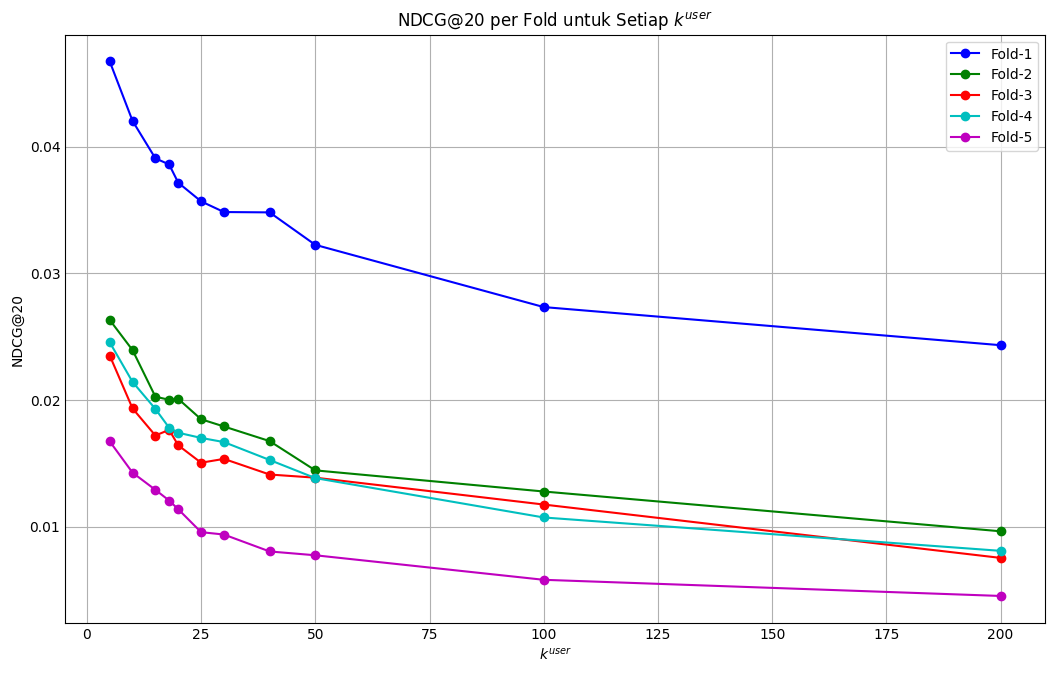

In [68]:
import matplotlib.pyplot as plt

# Definisikan markers dan colors
# markers = ['o', 's', '^', 'D', 'o']
colors = ['b', 'g', 'r', 'c', 'm']

plt.figure(figsize=(10, 6))

for fold_idx in range(5):
    ndcg_per_fold = [dc_mean_ndcg_k_user_fold[k][fold_idx] for k in range(len(k_user))]
    plt.plot(
        k_user,
        ndcg_per_fold,
        marker="o",
        color=colors[fold_idx],
        label=f'Fold-{fold_idx+1}'
    )

plt.xlabel(r'$k^{user}$')
plt.ylabel('NDCG@20')
plt.title(r'NDCG@20 per Fold untuk Setiap $k^{user}$')
plt.legend()
plt.grid(True)
plt.show()

#### DCG@20 $k^{user}$ plot

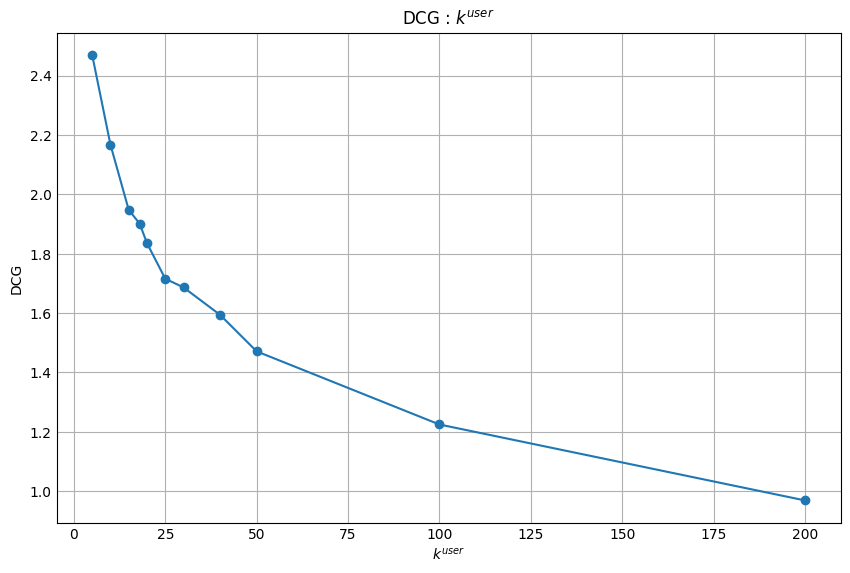

In [69]:
import pandas as pd

df = pd.DataFrame(dc_mean_dcg_k_user, index=[i for i in range(1, len(dc_mean_dcg_k_user) + 1)], columns=["k_user", "k_item", "DCG"])

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot([5,10,15,18,20,25,30,40,50,100,200], df["DCG"], marker='o')
plt.xlabel(r"$k^{user}$")
plt.ylabel("DCG")
plt.title(r"DCG : $k^{user}$")
plt.grid(True)
plt.show()

#### NDCG@20 $k^{user}$ plot

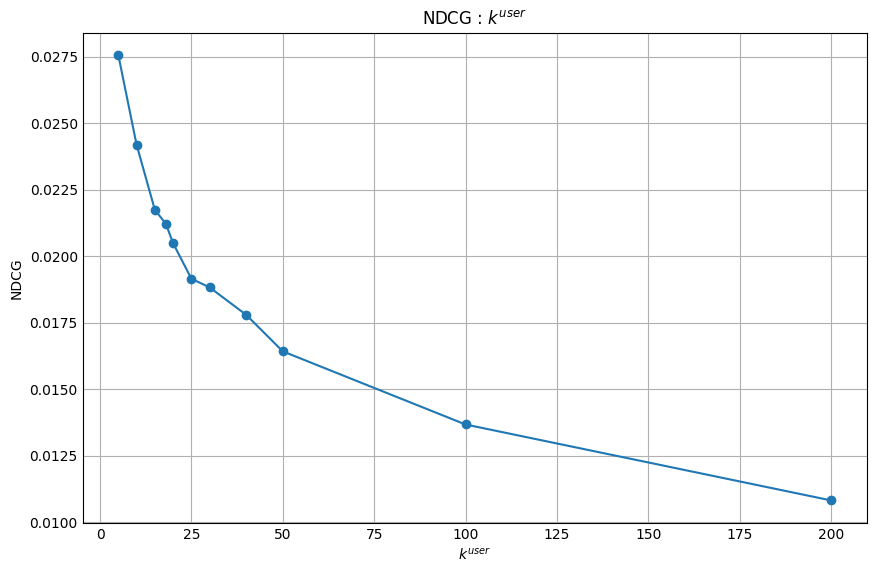

In [70]:
import pandas as pd

df = pd.DataFrame(dc_mean_ndcg_k_user, index=[i for i in range(1, len(dc_mean_ndcg_k_user) + 1)], columns=["k_user", "k_item", "NDCG"])

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot([5,10,15,18,20,25,30,40,50,100,200], df["NDCG"], marker='o')
plt.xlabel(r"$k^{user}$")
plt.ylabel("NDCG")
plt.title(r"NDCG : $k^{user}$")
plt.grid(True)
plt.show()

### Skenario 2 : Mencari $k^{item}$ terbaik

In [80]:
from Skenario import EksperimenHCF
import DistanceBased.similarities as S

param = {
            "gamma" : [0.7],
            "k_user" : [5],
            "k_item" : [5,10,15,18,20,25,30,40,50,100,200],
        }

skenario_kedua_dc = EksperimenHCF("data/ml-100k",object=S.DC,k_user=param["k_user"],k_item=param["k_item"],gamma=param["gamma"],path_file="Eksperimen/dice_coefficient/FBO_K_item.joblib",N=20,n=20)

In [81]:
import numpy as np

n = 20
idcg = np.array([sum(np.array([sum(1/np.log2(np.arange(2,n+2))) for n in range(1,n+1)])) for i in range(1,n+1)])
k_item = [5,10,15,18,20,25,30,40,50,100,200]


dc_mean_dcg_k_item_fold = []
dc_mean_ndcg_k_item_fold = []
dc_mean_dcg_k_item = []
dc_mean_ndcg_k_item = []

# Mengakses parameter k_item
for k_item_index in k_item :
    skenario_kedua_dc_candidate = skenario_kedua_dc.result_skenario[0.7][5][k_item_index]
    dc_mean_dcg_k_item_per_fold = []
    dc_mean_ndcg_k_item_per_fold = []

    # Tahap 1 : menjumlahkan evaluasi setiap fold
    for i in range(len(skenario_kedua_dc_candidate)) :
        # Tahap 2 : menjumlahkan evaluasi setiap pengguna
        # Tahap 3 : menjumlahkan rata-rata setiap fold dengan menjumlahkan nilai evaluasi setiap pengguna lalu dibagi dengan jumlah fold
        dc_mean_dcg_k_item_per_fold += [sum(skenario_kedua_dc_candidate[i])/len(skenario_kedua_dc_candidate[i])]
        dc_mean_ndcg_k_item_per_fold += [sum(np.array(skenario_kedua_dc_candidate[i])/idcg[n-1])/len(skenario_kedua_dc_candidate[i])]
    
    # Tahap 4 : menghitung rata-rata evaluasi dari setiap fold
    dc_mean_dcg_per_fold_k_item = sum(dc_mean_dcg_k_item_per_fold)/len(skenario_kedua_dc_candidate)
    dc_mean_ndcg_per_fold_k_item = sum(dc_mean_ndcg_k_item_per_fold)/len(skenario_kedua_dc_candidate)

    dc_mean_dcg_k_item_per_fold += [dc_mean_dcg_per_fold_k_item]
    dc_mean_ndcg_k_item_per_fold += [dc_mean_ndcg_per_fold_k_item]

    dc_mean_dcg_k_item_fold += [dc_mean_dcg_k_item_per_fold]
    dc_mean_ndcg_k_item_fold += [dc_mean_ndcg_k_item_per_fold]
    dc_mean_dcg_k_item += [[k_item_index,30,dc_mean_dcg_per_fold_k_item]]
    dc_mean_ndcg_k_item += [[k_item_index,30,dc_mean_ndcg_per_fold_k_item]]

#### DCG@20 $k^{item}$ per fold

In [82]:
import pandas as pd

k_item = [5,10,15,18,20,25,30,40,50,100,200]

pd.DataFrame(dc_mean_dcg_k_item_fold,index=[ f"N_{i}" for i in k_item],columns=[f"Fold-{i}" if i != 6 else "rata-rata" for i in range(1,7)])

,Fold-1,Fold-2,Fold-3,Fold-4,Fold-5,rata-rata
N_5,4.404620,2.555686,2.220417,2.126501,1.592377,2.579920
N_10,4.302745,2.511839,2.195739,2.101939,1.617543,2.545961
N_15,4.310042,2.375867,2.127162,2.194569,1.581291,2.517786
N_18,4.360970,2.324291,2.081740,2.174709,1.528941,2.494130
N_20,4.277312,2.325088,2.101744,2.153509,1.473345,2.466200
N_25,4.357551,2.341022,2.084418,2.200386,1.525981,2.501872
N_30,4.185649,2.357345,2.105758,2.199348,1.498704,2.469361
N_40,4.272151,2.339891,2.072604,2.133499,1.426308,2.448891
N_50,4.309108,2.369070,2.086300,2.147114,1.454756,2.473270
N_100,4.239227,2.336521,2.061573,2.157787,1.394386,2.437899


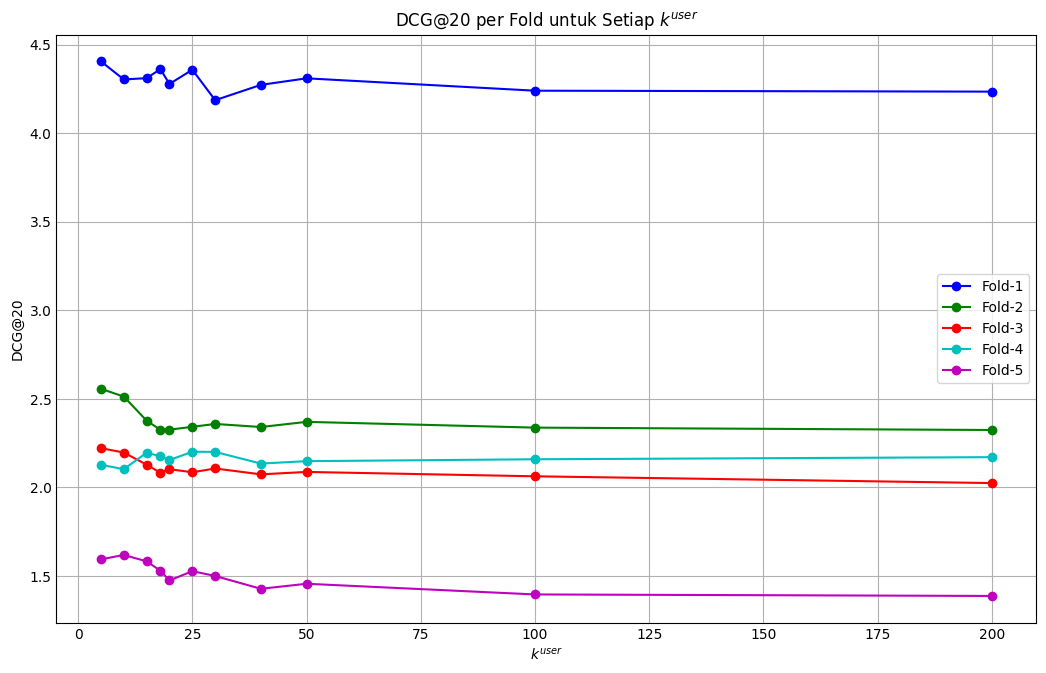

In [83]:
import matplotlib.pyplot as plt

# Definisikan markers dan colors
# markers = ['o', 's', '^', 'D', 'o']
colors = ['b', 'g', 'r', 'c', 'm']

plt.figure(figsize=(10, 6))

for fold_idx in range(5):
    dcg_per_fold = [dc_mean_dcg_k_item_fold[k][fold_idx] for k in range(len(k_item))]
    plt.plot(
        k_item,
        dcg_per_fold,
        marker="o",
        color=colors[fold_idx],
        label=f'Fold-{fold_idx+1}'
    )

plt.xlabel(r'$k^{user}$')
plt.ylabel('DCG@20')
plt.title(r'DCG@20 per Fold untuk Setiap $k^{user}$')
plt.legend()
plt.grid(True)
plt.show()

#### NDCG@20 $k^{item}$ per fold

In [84]:
import pandas as pd

k_item = [5,10,15,18,20,25,30,40,50,100,200]

pd.DataFrame(dc_mean_ndcg_k_item_fold,index=[ f"N_{i}" for i in k_item],columns=[f"Fold-{i}" if i != 6 else "rata-rata" for i in range(1,7)])

,Fold-1,Fold-2,Fold-3,Fold-4,Fold-5,rata-rata
N_5,0.049161,0.028525,0.024783,0.023735,0.017773,0.028795
N_10,0.048024,0.028035,0.024507,0.023460,0.018054,0.028416
N_15,0.048106,0.026518,0.023742,0.024494,0.017649,0.028102
N_18,0.048674,0.025942,0.023235,0.024273,0.017065,0.027838
N_20,0.047740,0.025951,0.023458,0.024036,0.016444,0.027526
N_25,0.048636,0.026129,0.023265,0.024559,0.017032,0.027924
N_30,0.046717,0.026311,0.023503,0.024548,0.016727,0.027561
N_40,0.047683,0.026116,0.023133,0.023813,0.015919,0.027333
N_50,0.048095,0.026442,0.023286,0.023965,0.016237,0.027605
N_100,0.047315,0.026079,0.023010,0.024084,0.015563,0.027210


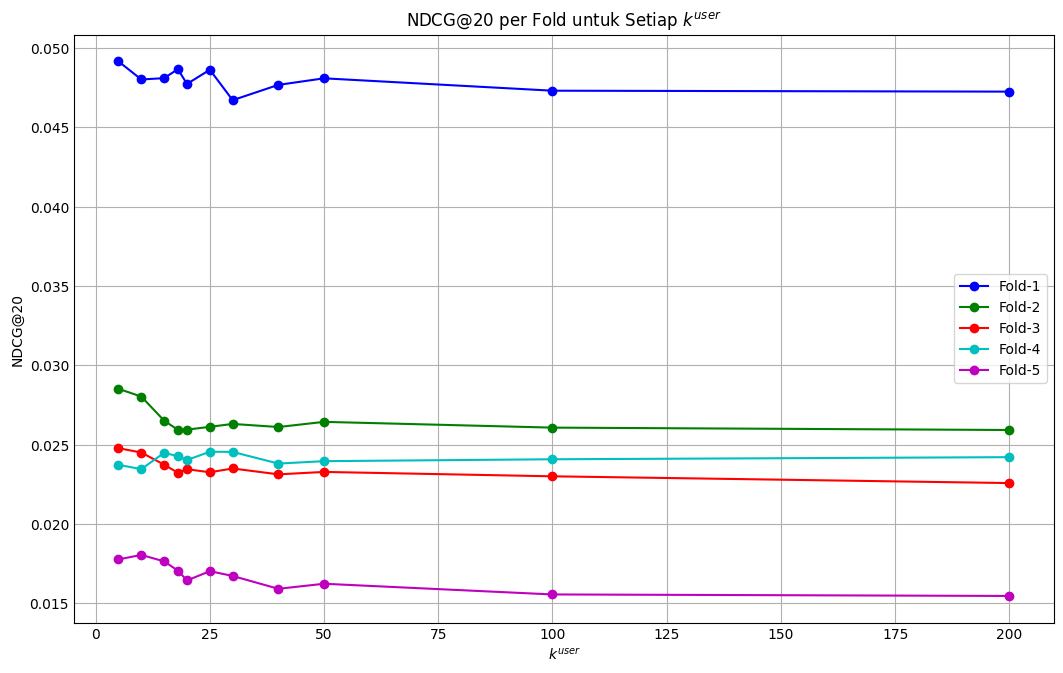

In [88]:
import matplotlib.pyplot as plt

# Definisikan markers dan colors
# markers = ['o', 's', '^', 'D', 'o']
colors = ['b', 'g', 'r', 'c', 'm']

plt.figure(figsize=(10, 6))

for fold_idx in range(5):
    ndcg_per_fold = [dc_mean_ndcg_k_item_fold[k][fold_idx] for k in range(len(k_item))]
    plt.plot(
        k_item,
        ndcg_per_fold,
        marker="o",
        color=colors[fold_idx],
        label=f'Fold-{fold_idx+1}'
    )

plt.xlabel(r'$k^{user}$')
plt.ylabel('NDCG@20')
plt.title(r'NDCG@20 per Fold untuk Setiap $k^{user}$')
plt.legend()
plt.grid(True)
plt.show()

#### DCG@20 $k^{item}$ plot

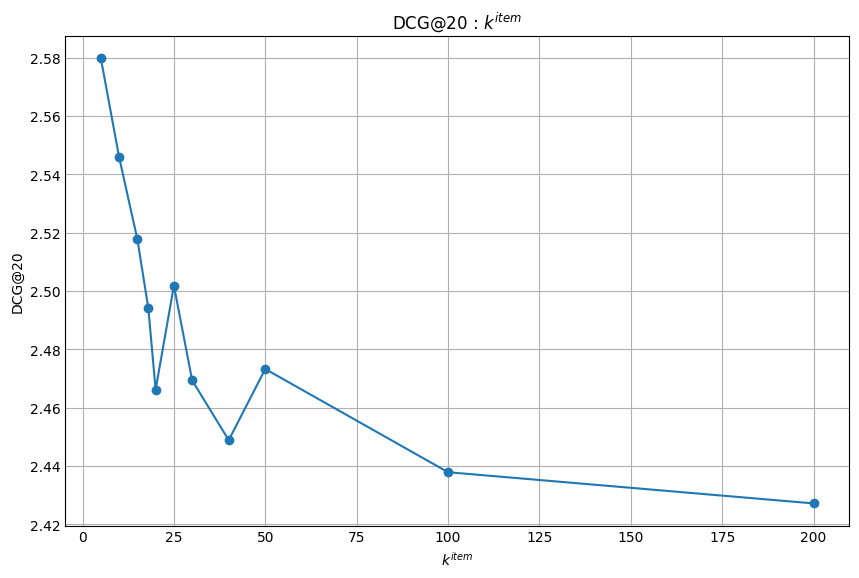

In [86]:
import pandas as pd

df = pd.DataFrame(dc_mean_dcg_k_item, index=[i for i in range(1, len(dc_mean_dcg_k_item) + 1)], columns=["k_user", "k_item", "DCG@20"])

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot([5,10,15,18,20,25,30,40,50,100,200], df["DCG@20"], marker='o')
plt.xlabel(r"$k^{item}$")
plt.ylabel("DCG@20")
plt.title(r"DCG@20 : $k^{item}$")
plt.grid(True)
plt.show()

#### NDCG@20 $k^{item}$ plot

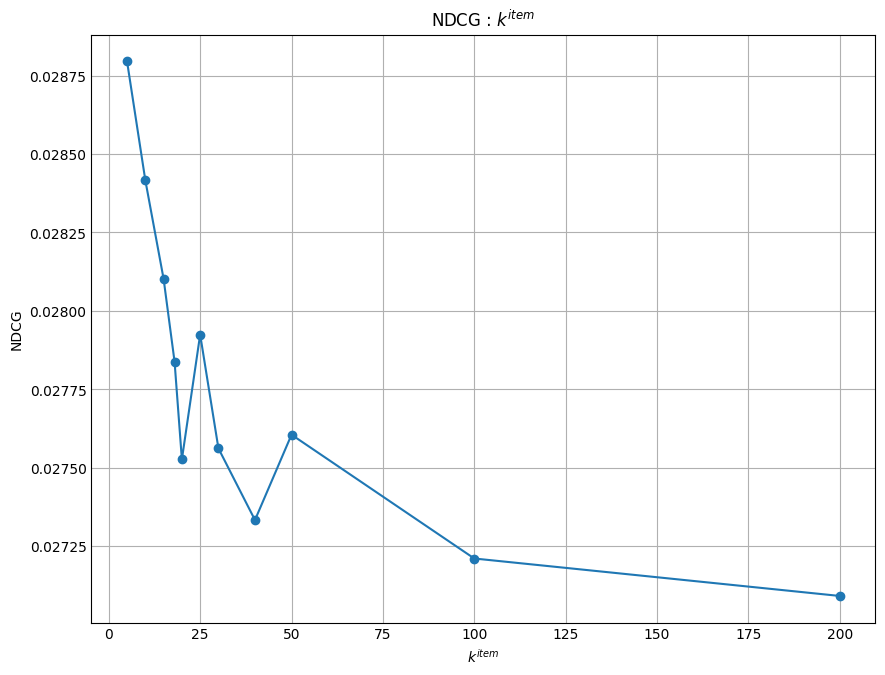

In [87]:
import pandas as pd

df = pd.DataFrame(dc_mean_ndcg_k_item, index=[i for i in range(1, len(dc_mean_ndcg_k_item) + 1)], columns=["k_user", "k_item", "NDCG"])

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.plot([5,10,15,18,20,25,30,40,50,100,200], df["NDCG"], marker='o')
plt.xlabel(r"$k^{item}$")
plt.ylabel("NDCG")
plt.title(r"NDCG : $k^{item}$")
plt.grid(True)
plt.show()

### Skenario 3 : Mencari $\Gamma$ terbaik

In [9]:
from Skenario import EksperimenHCF
import DistanceBased.similarities as S

param = {
            "gamma" : [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1],
            "k_user" : [5],
            "k_item" : [5],
        }

skenario_ketiga_dc = EksperimenHCF("data/ml-100k",object=S.DC,k_user=param["k_user"],k_item=param["k_item"],gamma=param["gamma"],path_file="Eksperimen/dice_coefficient/FBO_Gamma.joblib",N=20,n=20)

In [10]:
import numpy as np

n = 20
idcg = np.array([sum(np.array([sum(1/np.log2(np.arange(2,n+2))) for n in range(1,n+1)])) for i in range(1,n+1)])
gamma = [round(i*0.1,2) for i in range(11)]


dc_mean_dcg_gamma_fold = []
dc_mean_ndcg_gamma_fold = []
dc_mean_dcg_gamma = []
dc_mean_ndcg_gamma = []

# Mengakses parameter gamma
for gamma_index in gamma :
    skenario_ketiga_gamma = skenario_ketiga_dc.result_skenario[gamma_index][5][5]
    dc_mean_dcg_per_fold = []
    dc_mean_ndcg_per_fold = []

    # Tahap 1 : menjumlahkan evaluasi setiap fold
    for i in range(len(skenario_ketiga_gamma)) :
        # Tahap 2 : menjumlahkan evaluasi setiap pengguna
        # Tahap 3 : menghitung rata-rata setiap fold dengan menjumlahkan nilai evaluasi setiap pengguna lalu dibagi dengan jumlah pengguna
        dc_mean_dcg_per_fold += [sum(skenario_ketiga_gamma[i])/len(skenario_ketiga_gamma[i])]
        dc_mean_ndcg_per_fold += [sum(np.array(skenario_ketiga_gamma[i])/idcg[n-1])/len(skenario_ketiga_gamma[i])]

    # Tahap 4 : menghitung rata-rata evaluasi dari setiap fold
    dc_mean_dcg_per_fold_gamma = sum(dc_mean_dcg_per_fold)/len(skenario_ketiga_gamma)
    dc_mean_ndcg_per_fold_gamma = sum(dc_mean_ndcg_per_fold)/len(skenario_ketiga_gamma)

    dc_mean_dcg_per_fold += [dc_mean_dcg_per_fold_gamma]
    dc_mean_ndcg_per_fold += [dc_mean_ndcg_per_fold_gamma]

    dc_mean_dcg_gamma_fold += [dc_mean_dcg_per_fold]
    dc_mean_ndcg_gamma_fold += [dc_mean_ndcg_per_fold]
    dc_mean_dcg_gamma += [[gamma_index,30,dc_mean_dcg_per_fold_gamma]]
    dc_mean_ndcg_gamma += [[gamma_index,30,dc_mean_ndcg_per_fold_gamma]]

#### DCG@20 $\Gamma$ per fold

In [11]:
import pandas as pd

gamma = [round(i*0.1,2) for i in range(11)]

pd.DataFrame(dc_mean_dcg_gamma_fold,index=[ f"K_USER_{str(5)}_K_ITEM_{str(5)}_gamma_{str(i)}" for i in gamma],columns=[f"fold-{i}" if i != 6 else "rata-rata" for i in range(1,7)])

,fold-1,fold-2,fold-3,fold-4,fold-5,rata-rata
K_USER_5_K_ITEM_5_gamma_0.0,4.978230,3.048286,2.341645,2.229044,1.932618,2.905965
K_USER_5_K_ITEM_5_gamma_0.1,4.761461,3.060067,2.323920,2.151822,1.902178,2.839890
K_USER_5_K_ITEM_5_gamma_0.2,4.818276,3.016909,2.379697,2.043750,1.931675,2.838061
K_USER_5_K_ITEM_5_gamma_0.3,4.778684,2.987136,2.372874,2.103757,1.877417,2.823974
K_USER_5_K_ITEM_5_gamma_0.4,4.758105,2.845165,2.449917,2.082066,1.754512,2.777953
K_USER_5_K_ITEM_5_gamma_0.5,4.607445,2.701179,2.477326,2.103627,1.760542,2.730024
K_USER_5_K_ITEM_5_gamma_0.6,4.521714,2.522300,2.298744,2.181864,1.676519,2.640228
K_USER_5_K_ITEM_5_gamma_0.7,4.404620,2.555686,2.220417,2.126501,1.592377,2.579920
K_USER_5_K_ITEM_5_gamma_0.8,4.538323,2.634603,2.208672,1.934812,1.639686,2.591219
K_USER_5_K_ITEM_5_gamma_0.9,4.198965,2.190280,1.919750,1.564259,1.362240,2.247099


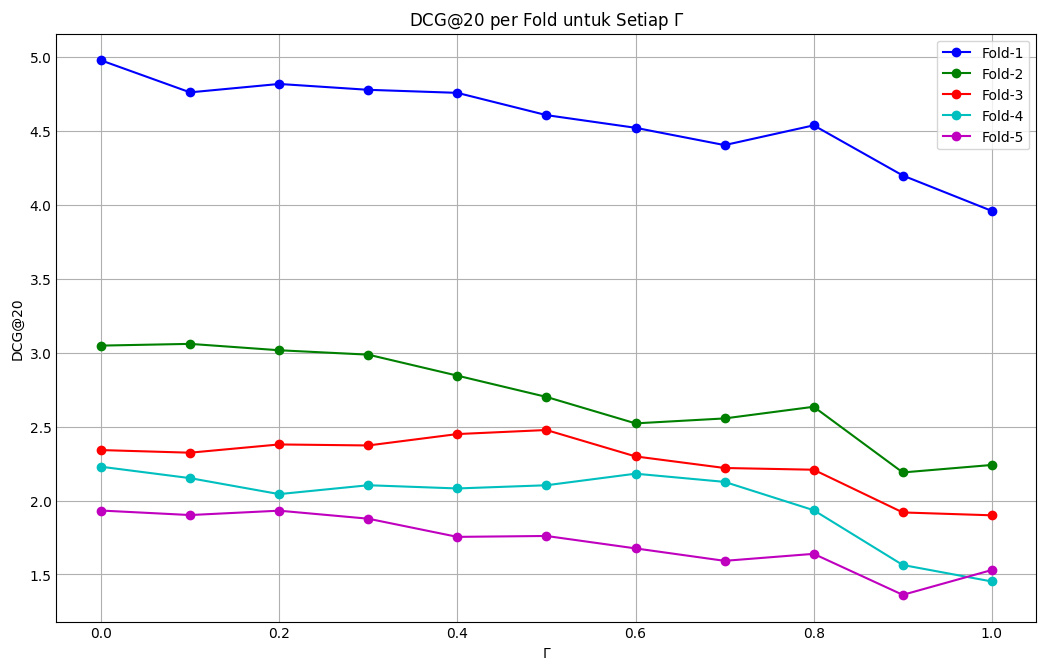

In [12]:
import matplotlib.pyplot as plt

# Definisikan markers dan colors
# markers = ['o', 's', '^', 'D', 'o']
colors = ['b', 'g', 'r', 'c', 'm']

plt.figure(figsize=(10, 6))

for fold_idx in range(5):
    dcg_per_fold = [dc_mean_dcg_gamma_fold[k][fold_idx] for k in range(len(gamma))]
    plt.plot(
        gamma,
        dcg_per_fold,
        marker="o",
        color=colors[fold_idx],
        label=f'Fold-{fold_idx+1}'
    )

plt.xlabel(r'$\Gamma$')
plt.ylabel('DCG@20')
plt.title(r'DCG@20 per Fold untuk Setiap $\Gamma$')
plt.legend()
plt.grid(True)
plt.show()

#### NDCG@20 $\Gamma$ per fold

In [13]:
import pandas as pd

pd.DataFrame(dc_mean_ndcg_gamma_fold,index=[ f"K_USER_{str(5)}_K_ITEM_{str(5)}_gamma_{str(i)}" for i in gamma],columns=[f"fold-{i}" if i != 6 else "rata-rata" for i in range(1,7)])

,fold-1,fold-2,fold-3,fold-4,fold-5,rata-rata
K_USER_5_K_ITEM_5_gamma_0.0,0.055564,0.034023,0.026136,0.024879,0.021571,0.032434
K_USER_5_K_ITEM_5_gamma_0.1,0.053144,0.034154,0.025938,0.024017,0.021231,0.031697
K_USER_5_K_ITEM_5_gamma_0.2,0.053778,0.033673,0.026561,0.022811,0.021560,0.031676
K_USER_5_K_ITEM_5_gamma_0.3,0.053336,0.033340,0.026484,0.023481,0.020954,0.031519
K_USER_5_K_ITEM_5_gamma_0.4,0.053107,0.031756,0.027344,0.023239,0.019583,0.031006
K_USER_5_K_ITEM_5_gamma_0.5,0.051425,0.030149,0.027650,0.023479,0.019650,0.030471
K_USER_5_K_ITEM_5_gamma_0.6,0.050468,0.028152,0.025657,0.024352,0.018712,0.029468
K_USER_5_K_ITEM_5_gamma_0.7,0.049161,0.028525,0.024783,0.023735,0.017773,0.028795
K_USER_5_K_ITEM_5_gamma_0.8,0.050654,0.029406,0.024652,0.021595,0.018301,0.028921
K_USER_5_K_ITEM_5_gamma_0.9,0.046866,0.024446,0.021427,0.017459,0.015204,0.025081


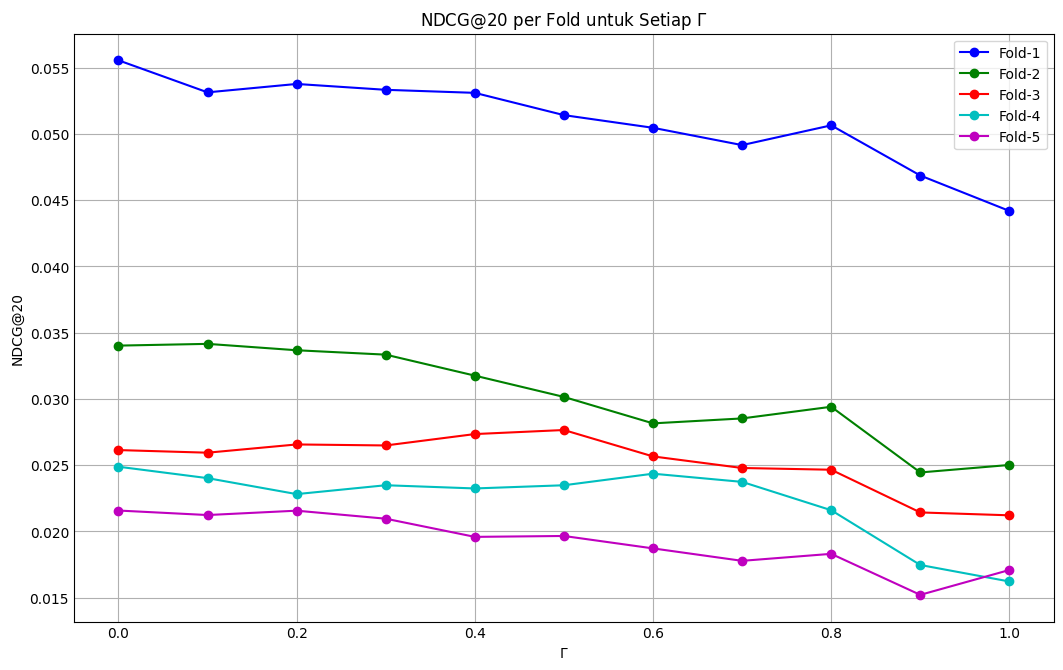

In [14]:
import matplotlib.pyplot as plt

# Definisikan markers dan colors
# markers = ['o', 's', '^', 'D', 'o']
colors = ['b', 'g', 'r', 'c', 'm']

plt.figure(figsize=(10, 6))

for fold_idx in range(5):
    ndcg_per_fold = [dc_mean_ndcg_gamma_fold[k][fold_idx] for k in range(len(gamma))]
    plt.plot(
        gamma,
        ndcg_per_fold,
        marker="o",
        color=colors[fold_idx],
        label=f'Fold-{fold_idx+1}'
    )

plt.xlabel(r'$\Gamma$')
plt.ylabel('NDCG@20')
plt.title(r'NDCG@20 per Fold untuk Setiap $\Gamma$')
plt.legend()
plt.grid(True)
plt.show()

#### DCG@20 $\Gamma$ plot

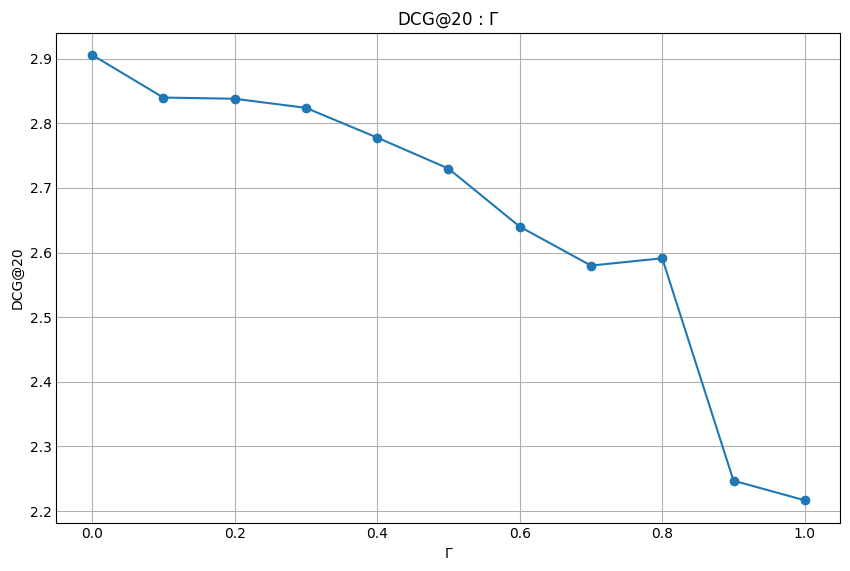

In [15]:
import pandas as pd

df = pd.DataFrame(dc_mean_dcg_gamma, index=[i for i in range(1, len(dc_mean_dcg_gamma) + 1)], columns=["k_user", "k_item", "DCG"])

import matplotlib.pyplot as plt

plt.style.use("_mpl-gallery")

plt.figure(figsize=(8, 5))
plt.plot([round(i*0.1,2) for i in range(11)], df["DCG"], marker='o')
plt.xlabel(r"$\Gamma$")
plt.ylabel("DCG@20")
plt.title(r"DCG@20 : $\Gamma$")
plt.grid(True)
plt.show()

#### NDCG@20 $\Gamma$ plot

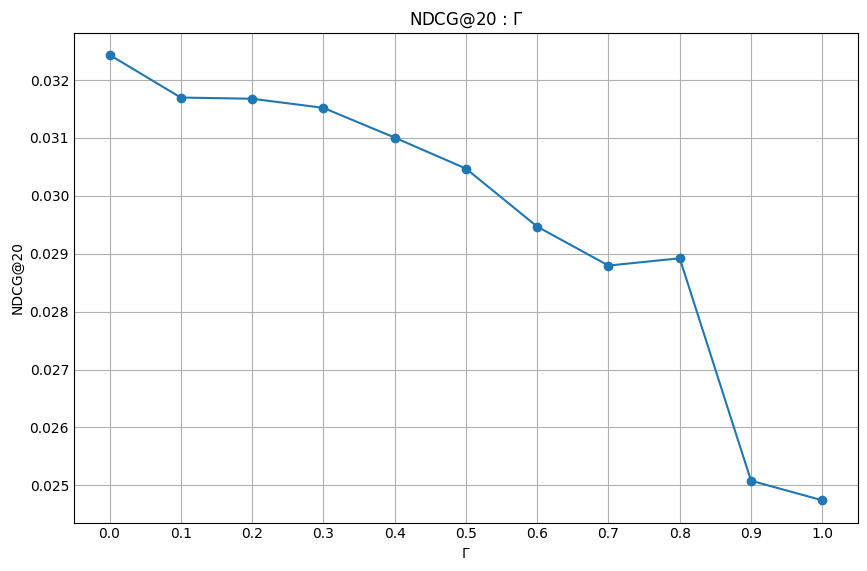

In [16]:
import pandas as pd

df = pd.DataFrame(dc_mean_ndcg_gamma, index=[i for i in range(1, len(dc_mean_ndcg_gamma) + 1)], columns=["k_user", "k_item", "NDCG"])

import matplotlib.pyplot as plt

plt.style.use("_mpl-gallery")

plt.figure(figsize=(8, 5))
plt.plot([round(i*0.1,2) for i in range(11)], df["NDCG"], marker='o')
plt.xticks([round(i*0.1,2) for i in range(11)])
plt.xlabel(r"$\Gamma$")
plt.ylabel("NDCG@20")
plt.title(r"NDCG@20 : $\Gamma$")
plt.grid(True)
plt.show()

### NDCG

In [21]:
from hybrid import HCF 
import DistanceBased.similarities as S

hybrid_dc = HCF("data/ml-100k",S.DC,k_user=5,k_item=5,gamma=0,N=20,n=None,path_file="Eksperimen/dice_coefficient/PBO_NDCG.joblib")

In [22]:
import numpy as np

skenario_dcg = hybrid_dc.result_evaluation

# Mencari NDCG
ndcg_dc_per_fold = []
for skenario_dcg_fold in skenario_dcg :
    ndcg_dc_per_user = []
    for skenario_dcg_user in skenario_dcg_fold :
        ndcg_dc_per_user += [np.array(skenario_dcg_user)/hybrid_dc.IDCG()]
    ndcg_dc_per_fold += [ndcg_dc_per_user]

# Mencari Rata-rata NDCG per fold
mean_ndcg_dc_per_fold = [ [ sum([row[col] for row in ndcg_dc_per_fold[i]])/len(ndcg_dc_per_fold[i]) for col in range(len(ndcg_dc_per_fold[i][0]))] for i in range(len(ndcg_dc_per_fold))]
# Mencari rata-rata NDCG
mean_ndcg_dc = [ sum([row[col] for row in mean_ndcg_dc_per_fold])/len(mean_ndcg_dc_per_fold) for col in range(len(mean_ndcg_dc_per_fold[0])) ]

In [23]:
import pandas as pd

pd.DataFrame(mean_ndcg_dc).T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,0.003443,0.006811,0.009024,0.01073,0.012402,0.015529,0.017262,0.019205,0.021545,0.022264,0.023568,0.025085,0.026396,0.027761,0.029351,0.029864,0.030322,0.030961,0.031928,0.032434


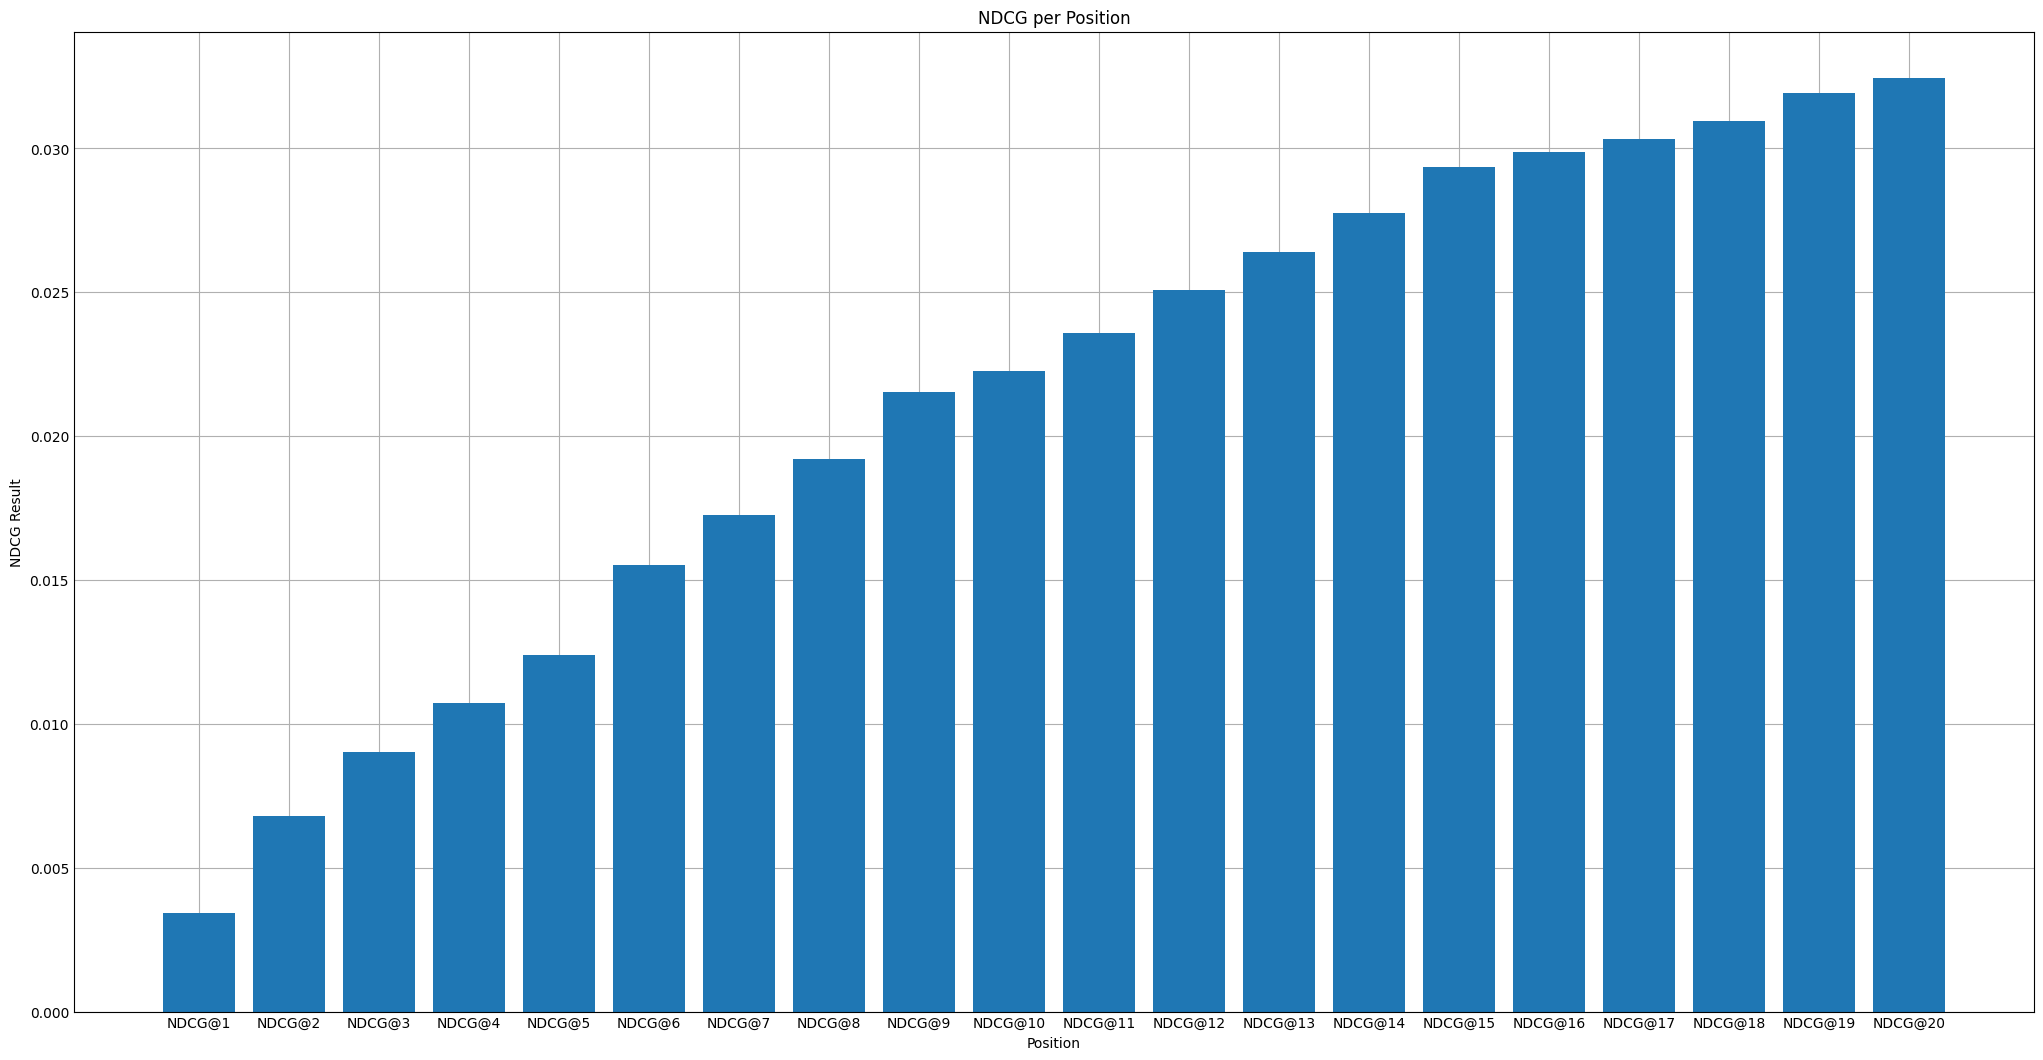

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
plt.bar([f"NDCG@{i}" for i in range(1,len(mean_ndcg_dc) + 1)], mean_ndcg_dc)
plt.xlabel('Position')
plt.ylabel('NDCG Result')
plt.title('NDCG per Position')
plt.show()